# 4.1) Univariate Exploration

Deep dive into individual variables: distributions, outliers, patterns, temporal trends, and feature engineering opportunities.


In [1]:
# Inputs: processed latest | Process: load SATNAV | Outputs: satnav_df
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML
from pathlib import Path

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

processed_dir = Path("../data/processed")
candidates = sorted(processed_dir.glob("satnav_*.csv"))
csv_path = candidates[-1] if candidates else processed_dir / "satnav_latest.csv"

satnav_df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", satnav_df.shape)

# Inputs: CSV file path | Process: read CSV | Outputs: satnav_tidy DataFrame
from pathlib import Path


# Show all columns (and full column text) when using head(), etc.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

def show_freeze_header(df, height=400):
    html = df.to_html(index=False)
    return HTML(f"""
    <style>
    .scrollbox {{ max-height:{height}px; overflow-y:auto; }}
    .scrollbox thead th {{ position: sticky; top: 0; background: white; z-index: 2; }}
    </style>
    <div class="scrollbox">{html}</div>
    """)


csv_path = Path("../data/processed/satnav_tidy.csv")
satnav_tidy = pd.read_csv(csv_path)
print(f"Loaded: {csv_path.resolve()}")
print(f"Shape: {satnav_tidy.shape}")


Loaded: ../data/processed/satnav_tidy.csv
Shape: (65088, 36)
Loaded: /Users/aaeush/Desktop/Drive/Drive/Academics/Py Project/MyCode/OrbitIQ/orbitiq/data/processed/satnav_tidy.csv
Shape: (65088, 36)


In [ ]:
# Explore String type categorical data
# Barplots of counts and boxplots (IQRs) by category

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Editable settings ---
# categorical_features: String/categorical columns to visualize
categorical_features = ['rcs_size', 'object_type', 'site']

# numeric_metric: Numeric column to show distribution (IQR) in boxplots
numeric_metric = 'rev_at_epoch'  # Change to e.g., 'apogee', 'perigee', 'launch_year'

# top_n_categories: Limit to top N most frequent categories to keep plots readable
top_n_categories = 15

# show_fliers: Whether to show outlier points in boxplots
show_fliers = False
# -------------------------

# Validate numeric column
if numeric_metric not in satnav_df.columns:
    raise KeyError(f"Column '{numeric_metric}' not found. Available: {list(satnav_df.columns)}")


In [ ]:
satnav_tidy.info()

In [ ]:

# Ensure numeric_metric is numeric
_numeric = pd.to_numeric(satnav_df[numeric_metric], errors='coerce')

for col in categorical_features:
    if col not in satnav_df.columns:
        print(f"Skipping '{col}' (column not found)")
        continue

    counts = satnav_df[col].value_counts(dropna=False)
    if counts.empty:
        print(f"Skipping '{col}' (no data)")
        continue

    # Select top categories and prepare plotting order
    top_counts = counts.head(top_n_categories)
    category_order = [str(c) for c in top_counts.index.tolist()]

    # Prepare DataFrame for boxplot
    df_plot = pd.DataFrame({col: satnav_df[col].astype(str), numeric_metric: _numeric})
    df_plot = df_plot[df_plot[col].isin(category_order) & df_plot[numeric_metric].notna()].copy()

    # Dynamic width based on number of categories
    n_cat = len(category_order)
    fig_width = max(12, min(28, 0.6 * n_cat + 6))
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, 6))

    # Barplot of counts
    sns.barplot(
        x=[str(c) for c in top_counts.index],
        y=top_counts.values,
        ax=axes[0],
        color='skyblue',
        edgecolor='black'
    )
    axes[0].set_title(f"{col}: Counts (Top {n_cat})")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, axis='y', alpha=0.3)

    # Boxplot for numeric_metric by category (shows IQR)
    if not df_plot.empty:
        sns.boxplot(
            data=df_plot,
            x=col,
            y=numeric_metric,
            order=category_order,
            showfliers=show_fliers,
            ax=axes[1]
        )
        axes[1].set_title(f"{numeric_metric} by {col} (IQR shown)")
        axes[1].set_xlabel(col)
        axes[1].set_ylabel(numeric_metric)
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, axis='y', alpha=0.3)

        # Print IQRs in console for reference
        q = df_plot.groupby(col)[numeric_metric].quantile([0.25, 0.75]).unstack()
        q.columns = ['Q1', 'Q3']
        q['IQR'] = (q['Q3'] - q['Q1']).round(2)
        q = q.reindex(category_order)
        print(f"IQR for '{numeric_metric}' by '{col}':")
        print(q[['IQR']].to_string())
    else:
        axes[1].set_visible(False)
        print(f"No numeric data available for boxplot of '{col}' vs '{numeric_metric}'.")

    plt.tight_layout()
    plt.show()

In [ ]:
# Inputs: satnav_df | Process: launch year distribution | Outputs: histogram + stats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

iterate = ['launch_year', 'decay', 'decay_date']
# Histogram
satnav_df['launch_year'].hist(bins=30, ax=ax1, alpha=0.7, edgecolor='black')
ax1.set_title('Launch Year Distribution')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3)

# Box plot
satnav_df.boxplot(column='launch_year', ax=ax2)
ax2.set_title('Launch Year Box Plot')
ax2.set_ylabel('Year')

plt.tight_layout()
plt.show()

print("Launch year stats:")
print(satnav_df['launch_year'].describe())


In [ ]:
# Inputs: satnav_df | Process: object type distribution | Outputs: bar chart + proportions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Count plot
obj_counts = satnav_df['object_type'].value_counts()
obj_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Object Type Distribution')
ax1.set_xlabel('Object Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
obj_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Object Type Proportions')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print("Object type breakdown:")
print(obj_counts)
print(f"\nTotal: {obj_counts.sum():,}")


In [ ]:
# Inputs: satnav_df | Process: country distribution (top 15) | Outputs: horizontal bar chart
plt.figure(figsize=(12, 8))

country_counts = satnav_df['country'].value_counts().head(15)
country_counts.plot(kind='barh', color='lightcoral', edgecolor='black')
plt.title('Top 15 Countries by Satellite Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.grid(True, alpha=0.3, axis='x')

# Add count labels
for i, v in enumerate(country_counts.values):
    plt.text(v + 100, i, f'{v:,}', va='center')

plt.tight_layout()
plt.show()

print(f"Total countries: {satnav_df['country'].nunique()}")
print(f"Top 3: {country_counts.head(3).to_dict()}")


In [ ]:
# Inputs: satnav_df | Process: orbital period distribution | Outputs: histogram + log scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

period_data = satnav_df['period'].dropna()

# Linear scale
period_data.hist(bins=50, ax=ax1, alpha=0.7, edgecolor='black', color='green')
ax1.set_title('Orbital Period Distribution (Linear)')
ax1.set_xlabel('Period (minutes)')
ax1.set_ylabel('Count')
ax1.grid(True, alpha=0.3)

# Log scale
period_data.hist(bins=50, ax=ax2, alpha=0.7, edgecolor='black', color='orange')
ax2.set_title('Orbital Period Distribution (Log Scale)')
ax2.set_xlabel('Period (minutes)')
ax2.set_ylabel('Count')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Period stats (minutes):")
print(period_data.describe())
print(f"\nGEO-like periods (1400-1450 min): {((period_data >= 1400) & (period_data <= 1450)).sum()}")
print(f"LEO-like periods (90-120 min): {((period_data >= 90) & (period_data <= 120)).sum()}")


In [ ]:
# Inputs: satnav_df | Process: generate word cloud from SatName | Outputs: word cloud figure
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

# --- Editable settings ---
# text_column: Name of the column to use for the word cloud text
text_column = 'comment_x'  # Change to another text column if needed

# max_words: Maximum number of words to display in the cloud
max_words = 100  # Reduce for a sparser cloud, increase for denser

# background_color: Background color of the word cloud image
background_color = 'white'  # e.g., 'black', 'white', '#0f0f0f'

# colormap: Matplotlib colormap for word colors
colormap = 'plasma'  # e.g., 'plasma', 'inferno', 'tab20', 'Set2'

# width, height: Output image size in pixels
width, height = 1600, 900  # Increase for higher resolution output

# stopwords_extra: Extra words to remove (domain-specific or frequent tokens)
stopwords_extra = {
    'SAT', 'SATELLITE', 'OBJECT', 'STARLINK', 'BLOCK', 'COSMOS', 'NAVSTAR', 'ONEWEB',
    'R/B', 'DEB', 'RESURS', 'SHIJIAN', 'FENGYUN', 'ZHUHAI', 'TECHNOLOGY', 'SERIES'
}  # Add/remove words as needed'''
# -------------------------

# Build stopwords set
stopwords = set(STOPWORDS)
stopwords |= {w.lower() for w in stopwords_extra}

# Prepare text: join non-null values from the selected column
if text_column not in satnav_df.columns:
    raise KeyError(f"Column '{text_column}' not found in DataFrame. Available: {list(satnav_df.columns)}")

names_series = satnav_df[text_column].dropna().astype(str)
# Normalize: uppercase to reduce duplicates like 'Starlink' vs 'STARLINK'; remove trivial tokens
processed_text = ' '.join(name.upper() for name in names_series if name.strip())

# Generate word cloud
wc = WordCloud(
    width=width,
    height=height,
    background_color=background_color,
    stopwords=stopwords,
    max_words=max_words,
    colormap=colormap,
    collocations=True,  # Set False to treat bigrams as separate words
    normalize_plurals=True,
).generate(processed_text)

# Display
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title(f"Word Cloud: {text_column}")
plt.show()


In [ ]:
# Inputs: satnav_df | Process: iterate list and plot histograms | Outputs: seaborn histograms
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Editable settings ---
# explore_dist: columns to explore via histograms
explore_dist = ['apoapsis', 'periapsis', 'launch_year', 'rev_at_epoch', 'period', 
'inclination', 'eccentricity', 'arg_of_pericenter', 
'']

# bins: number of histogram bins
bins = 20

# log_scale: apply log scale to y-axis for skewed distributions
log_scale = False
# -------------------------

# Optional alias mapping to handle alternative column names
alias_map = {
    'apoapsis': ['apoapsis', 'apogee'],
    'periapsis': ['periapsis', 'perigee'],
    'launch_year': ['launch_year', 'LAUNCH_YEAR']
}

for key in explore_dist:
    # Resolve column name via aliases
    candidates = alias_map.get(key, [key])
    col = next((c for c in candidates if c in satnav_df.columns), None)
    if col is None:
        print(f"Skipping '{key}': no matching column found among {candidates}")
        continue

    series = pd.to_numeric(satnav_df[col], errors='coerce').dropna()
    if series.empty:
        print(f"Skipping '{col}': no numeric data to plot")
        continue

    plt.figure(figsize=(10, 5))
    sns.histplot(series, bins=bins, kde=False, color='steelblue', edgecolor='black')
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    if log_scale:
        plt.yscale('log')
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
spadoc_mapping = {
    "AB": {"country_map": "ARAB SATELLITE COMMUNICATIONS ORGANIZATION", "iso3": "ORG"},
    "ABS": {"country_map": "ABS Global Ltd", "iso3": "PVT"},
    "ABW": {"country_map": "Aruba", "iso3": "ABW"},
    "AC": {"country_map": "ASIASAT CORP", "iso3": "PVT"},
    "AFG": {"country_map": "Afghanistan", "iso3": "AFG"},
    "AGO": {"country_map": "REPUBLIC OF ANGOLA", "iso3": "AGO"},
    "AIA": {"country_map": "Anguilla", "iso3": "AIA"},
    "ALA": {"country_map": "Åland Islands", "iso3": "ALA"},
    "ALB": {"country_map": "Albania", "iso3": "ALB"},
    "ALG": {"country_map": "ALGERIA", "iso3": "DZA"},
    "AND": {"country_map": "Andorra", "iso3": "AND"},
    "ARGN": {"country_map": "ARGENTINA", "iso3": "ARG"},
    "ARM": {"country_map": "Armenia", "iso3": "ARM"},
    "ASM": {"country_map": "American Samoa", "iso3": "ASM"},
    "ASRA": {"country_map": "AUSTRIA", "iso3": "AUT"},
    "ATF": {"country_map": "French Southern Territories", "iso3": "ATF"},
    "ATG": {"country_map": "Antigua and Barbuda", "iso3": "ATG"},
    "AUS": {"country_map": "AUSTRALIA", "iso3": "AUS"},
    "AZER": {"country_map": "AZERBAIJAN", "iso3": "AZE"},
    "AZE": {"country_map": "Azerbaijan", "iso3": "AZE"},
    "BDI": {"country_map": "Burundi", "iso3": "BDI"},
    "BEL": {"country_map": "BELGIUM", "iso3": "BEL"},
    "BELA": {"country_map": "BELARUS", "iso3": "BLR"},
    "BEN": {"country_map": "Benin", "iso3": "BEN"},
    "BERM": {"country_map": "BERMUDA", "iso3": "BMU"},
    "BES": {"country_map": "Bonaire, Sint Eustatius and Saba", "iso3": "BES"},
    "BFA": {"country_map": "Burkina Faso", "iso3": "BFA"},
    "BGD": {"country_map": "PEOPLES REPUBLIC OF BANGLADESH", "iso3": "BGD"},
    "BGR": {"country_map": "REPUBLIC OF BULGARIA", "iso3": "BGR"},
    "BHR": {"country_map": "Bahrain", "iso3": "BHR"},
    "BHS": {"country_map": "Bahamas", "iso3": "BHS"},
    "BIH": {"country_map": "Bosnia and Herzegovina", "iso3": "BIH"},
    "BLM": {"country_map": "Saint Barthélemy", "iso3": "BLM"},
    "BLZ": {"country_map": "Belize", "iso3": "BLZ"},
    "BOL": {"country_map": "BOLIVIA", "iso3": "BOL"},
    "BRAZ": {"country_map": "BRAZIL", "iso3": "BRA"},
    "BRB": {"country_map": "Barbados", "iso3": "BRB"},
    "BRN": {"country_map": "Brunei Darussalam", "iso3": "BRN"},
    "BTN": {"country_map": "Bhutan", "iso3": "BTN"},
    "BVT": {"country_map": "Bouvet Island", "iso3": "BVT"},
    "BWA": {"country_map": "Botswana", "iso3": "BWA"},
    "CA": {"country_map": "CANADA", "iso3": "CAN"},
    "CAF": {"country_map": "Central African Republic", "iso3": "CAF"},
    "CHBZ": {"country_map": "PEOPLES REPUBLIC OF CHINA/BRAZIL", "iso3": "MULTI"},
    "CHL": {"country_map": "Chile", "iso3": "CHL"},
    "CHLE": {"country_map": "CHILE", "iso3": "CHL"},
    "CHN": {"country_map": "China", "iso3": "CHN"},
    "CIS": {"country_map": "COMMONWEALTH OF INDEPENDENT STATES", "iso3": "MULTI"},
    "CZCH": {"country_map": "CZECHOSLOVAKIA", "iso3": "OLD"},
    "CZE": {"country_map": "Czechia", "iso3": "CZE"},
    "DEN": {"country_map": "DENMARK", "iso3": "DNK"},
    "DJI": {"country_map": "Djibouti", "iso3": "DJI"},
    "ECU": {"country_map": "ECUADOR", "iso3": "ECU"},
    "EGY": {"country_map": "Egypt", "iso3": "EGY"},
    "EGYP": {"country_map": "EGYPT", "iso3": "EGY"},
    "ESA": {"country_map": "EUROPEAN SPACE AGENCY", "iso3": "ORG"},
    "EST": {"country_map": "ESTONIA", "iso3": "EST"},
    "FR": {"country_map": "FRANCE", "iso3": "FRA"},
    "GER": {"country_map": "GERMANY", "iso3": "DEU"},
    "GHA": {"country_map": "REPUBLIC OF GHANA", "iso3": "GHA"},
    "GREC": {"country_map": "GREECE", "iso3": "GRC"},
    "HRV": {"country_map": "Croatia", "iso3": "HRV"},
    "HUN": {"country_map": "HUNGARY", "iso3": "HUN"},
    "IM": {"country_map": "INTERNATIONAL MARITIME SATELLITE ORGANIZATION (INMARSAT)", "iso3": "ORG"},
    "IND": {"country_map": "INDIA", "iso3": "IND"},
    "INDO": {"country_map": "INDONESIA", "iso3": "IDN"},
    "IRAN": {"country_map": "IRAN", "iso3": "IRN"},
    "IRAQ": {"country_map": "IRAQ", "iso3": "IRQ"},
    "ISRA": {"country_map": "ISRAEL", "iso3": "ISR"},
    "IT": {"country_map": "ITALY", "iso3": "ITA"},
    "JPN": {"country_map": "JAPAN", "iso3": "JPN"},
    "KAZ": {"country_map": "KAZAKHSTAN", "iso3": "KAZ"},
    "KEN": {"country_map": "REPUBLIC OF KENYA", "iso3": "KEN"},
    "KWT": {"country_map": "Kuwait", "iso3": "KWT"},
    "LAOS": {"country_map": "LAOS", "iso3": "LAO"},
    "LKA": {"country_map": "SRI LANKA", "iso3": "LKA"},
    "LTU": {"country_map": "LITHUANIA", "iso3": "LTU"},
    "LUXE": {"country_map": "LUXEMBOURG", "iso3": "LUX"},
    "MA": {"country_map": "MOROCCO", "iso3": "MAR"},
    "MALA": {"country_map": "MALAYSIA", "iso3": "MYS"},
    "MEX": {"country_map": "MEXICO", "iso3": "MEX"},
    "MMR": {"country_map": "REPUBLIC OF THE UNION OF MYANMAR", "iso3": "MMR"},
    "MNG": {"country_map": "MONGOLIA", "iso3": "MNG"},
    "NATO": {"country_map": "NORTH ATLANTIC TREATY ORGANIZATION", "iso3": "ORG"},
    "NETH": {"country_map": "NETHERLANDS", "iso3": "NLD"},
    "NIG": {"country_map": "NIGERIA", "iso3": "NGA"},
    "NKOR": {"country_map": "NORTH KOREA", "iso3": "PRK"},
    "NOR": {"country_map": "NORWAY", "iso3": "NOR"},
    "NPL": {"country_map": "NEPAL", "iso3": "NPL"},
    "NZ": {"country_map": "NEW ZEALAND", "iso3": "NZL"},
    "PAKI": {"country_map": "PAKISTAN", "iso3": "PAK"},
    "PER": {"country_map": "PERU", "iso3": "PER"},
    "POL": {"country_map": "POLAND", "iso3": "POL"},
    "POR": {"country_map": "PORTUGAL", "iso3": "PRT"},
    "PRC": {"country_map": "PEOPLES REPUBLIC OF CHINA", "iso3": "CHN"},
    "PRI": {"country_map": "Commonwealth of Puerto Rico", "iso3": "PRI"},
    "PRY": {"country_map": "REPUBLIC OF PARAGUAY", "iso3": "PRY"},
    "QAT": {"country_map": "STATE OF QATAR", "iso3": "QAT"},
    "ROM": {"country_map": "ROMANIA", "iso3": "ROU"},
    "RP": {"country_map": "REPUBLIC OF PHILIPPINES", "iso3": "PHL"},
    "RWA": {"country_map": "REPUBLIC OF RWANDA", "iso3": "RWA"},
    "SAFR": {"country_map": "SOUTH AFRICA", "iso3": "ZAF"},
    "SAUD": {"country_map": "SAUDI ARABIA", "iso3": "SAU"},
    "SDN": {"country_map": "REPUBLIC OF SUDAN", "iso3": "SDN"},
    "SING": {"country_map": "SINGAPORE", "iso3": "SGP"},
    "SKOR": {"country_map": "SOUTH KOREA", "iso3": "KOR"},
    "SPN": {"country_map": "SPAIN", "iso3": "ESP"},
    "SVK": {"country_map": "Slovakia", "iso3": "SVK"},
    "SVN": {"country_map": "REPUBLIC OF SLOVENIA", "iso3": "SVN"},
    "SWED": {"country_map": "SWEDEN", "iso3": "SWE"},
    "SWTZ": {"country_map": "SWITZERLAND", "iso3": "CHE"},
    "THAI": {"country_map": "THAILAND", "iso3": "THA"},
    "TUN": {"country_map": "REPUBLIC OF TUNISIA", "iso3": "TUN"},
    "TURK": {"country_map": "TURKEY", "iso3": "TUR"},
    "TWN": {"country_map": "TAIWAN", "iso3": "TWN"},  
    "UAE": {"country_map": "UNITED ARAB EMIRATES", "iso3": "ARE"},
    "UK": {"country_map": "UNITED KINGDOM", "iso3": "GBR"},
    "UKR": {"country_map": "UKRAINE", "iso3": "UKR"},
    "US": {"country_map": "UNITED STATES OF AMERICA", "iso3": "USA"},
    "VENZ": {"country_map": "VENEZUELA", "iso3": "VEN"},
    "VTNM": {"country_map": "VIETNAM", "iso3": "VNM"},
    "ZWE": {"country_map": "ZIMBABWE", "iso3": "ZWE"},
    "ALL": {"country_map": "ALL", "iso3": "UNK"},
    "COL":  {"country_map": "COLOMBIA",                                               "iso3": "COL"},
    "CRI":  {"country_map": "REPUBLIC OF COSTA RICA",                                 "iso3": "CRI"},
    "ESRO": {"country_map": "EUROPEAN SPACE RESEARCH ORGANIZATION (defunct)",         "iso3": "ORG"},
    "EUME": {"country_map": "EUROPEAN ORG. FOR THE EXPLOITATION OF METEOROLOGICAL SATELLITES (EUMETSAT)", "iso3": "ORG"},
    "EUTE": {"country_map": "EUROPEAN TELECOMMUNICATIONS SATELLITE ORG (EUTELSAT)",   "iso3": "ORG"},
    "FGER": {"country_map": "FRANCE/GERMANY",                                         "iso3": "MULTI"},
    "FIN":  {"country_map": "FINLAND",                                                "iso3": "FIN"},
    "FRIT": {"country_map": "FRANCE/ITALY",                                           "iso3": "MULTI"},
    "GLOB": {"country_map": "GLOBALSTAR",                                             "iso3": "PVT"},
    "ISS":  {"country_map": "INTERNATIONAL SPACE STATION",                            "iso3": "MULTI"},
    "ITSO": {"country_map": "INTERNATIONAL TELECOMMUNICATIONS SATELLITE ORG (INTELSAT)", "iso3": "ORG"},
    "JOR":  {"country_map": "HASHEMITE KINGDOM OF JORDAN",                            "iso3": "JOR"},
    "MCO":  {"country_map": "Monaco",                                                 "iso3": "MCO"},
    "MDA":  {"country_map": "Moldova, Republic of",                                   "iso3": "MDA"},
    "MUS":  {"country_map": "Mauritius",                                              "iso3": "MUS"},
    "NICO": {"country_map": "NEW ICO (ICO Global)",                                   "iso3": "PVT"},
    "O3B":  {"country_map": "O3b Networks",                                           "iso3": "PVT"},
    "ORB":  {"country_map": "ORBITAL TELECOMMUNICATIONS SATELLITE (GLOBALSTAR)",      "iso3": "PVT"},
    "RASC": {"country_map": "REGIONAL AFRICAN SATELLITE COMMUNICATIONS ORG (RASCOM)", "iso3": "ORG"},
    "SEAL": {"country_map": "SEA LAUNCH (demo/consortium)",                            "iso3": "MULTI"},
    "SES":  {"country_map": "SOCIETE EUROPEENNE DES SATELLITES (SES)",                "iso3": "PVT"},
    "STCT": {"country_map": "SINGAPORE/TAIWAN",                                       "iso3": "MULTI"},
    "TBD":  {"country_map": "TO BE DETERMINED / UNKNOWN",                              "iso3": "UNK"},
    "TMMC": {"country_map": "TURKMENISTAN/MONACO",                                    "iso3": "MULTI"},
    "UGA":  {"country_map": "Uganda",                                                 "iso3": "UGA"},
    "URY":  {"country_map": "Uruguay",                                                "iso3": "URY"},
    "USBZ": {"country_map": "UNITED STATES/BRAZIL",                                   "iso3": "MULTI"},
}



In [ ]:
# Inputs: spadoc_mapping, satnav_tidy['site'] | Process: count occurrences of each SPADOC code | Outputs: counts table
site_counts = satnav_tidy['COUNTRY_CODE'].value_counts(dropna=False)

# Create DataFrame with all SPADOC codes and their counts (including zeros)
spadoc_counts = pd.DataFrame({
    'spadoc_code': list(spadoc_mapping.keys()),
    'country_name': [spadoc_mapping[code]['country_map'] for code in spadoc_mapping.keys()],
    'count': [site_counts.get(code, 0) for code in spadoc_mapping.keys()]
})

# Sort by count descending
spadoc_counts = spadoc_counts.sort_values('count', ascending=False)

print(f"Total SPADOC codes: {len(spadoc_mapping)}")
print(f"Codes with data: {(spadoc_counts['count'] > 0).sum()}")
print(f"Codes with zero data: {(spadoc_counts['count'] == 0).sum()}")

show_freeze_header(spadoc_counts, height=400)  # Show top 20

In [ ]:
# Inputs: satnav_tidy, spadoc_mapping | Process: map SPADOC codes to country info | Outputs: new columns
# Create new columns from the mapping dictionary
satnav_tidy['country_map'] = satnav_tidy['site'].map(spadoc_mapping).apply(lambda x: x['country_map'] if pd.notna(x) else None)
satnav_tidy['iso3'] = satnav_tidy['site'].map(spadoc_mapping).apply(lambda x: x['iso3'] if pd.notna(x) else None)

# Check mapping coverage
mapped_count = satnav_tidy['country_map'].notna().sum()
total_count = len(satnav_tidy)
print(f"Mapped sites: {mapped_count}/{total_count} ({mapped_count/total_count*100:.1f}%)")

In [51]:
show_freeze_header(satnav_tidy.head(20))

INTLDES,NORAD_CAT_ID,SATNAME,COUNTRY,LAUNCH,DECAY,COMMENT,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,OBJECT_NUMBER,EPOCH,MEAN_MOTION,ECCENTRICITY,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,COUNTRY_CODE,TLE_LINE1,TLE_LINE2,object_type,site,period,inclination,apoapsis,periapsis,rcs_size,object_name,object_id,country_map,iso3
1957-001A,1,SL-1 R/B,CIS,1957-10-04,1957-12-01,NaN,1957,1,A,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ROCKET BODY,TTMTR,96.190,65.1000,938.000,214.000,LARGE,SL-1 R/B,1957-001A,COMMONWEALTH OF INDEPENDENT STATES,MULTI
1957-001B,2,SPUTNIK 1,CIS,1957-10-04,1958-01-03,NaN,1957,1,B,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,TTMTR,96.100,65.0000,1080.000,64.000,NaN,SPUTNIK 1,1957-001B,COMMONWEALTH OF INDEPENDENT STATES,MULTI
1957-002A,3,SPUTNIK 2,CIS,1957-11-03,1958-04-14,NaN,1957,2,A,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,TTMTR,103.740,65.3300,1659.000,211.000,SMALL,SPUTNIK 2,1957-002A,COMMONWEALTH OF INDEPENDENT STATES,MULTI
1958-001A,4,EXPLORER 1,US,1958-02-01,1970-03-31,NaN,1958,1,A,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,AFETR,88.480,33.1500,215.000,183.000,NaN,EXPLORER 1,1958-001A,UNITED STATES OF AMERICA,USA
1958-002B,5,VANGUARD 1,US,1958-03-17,NaN,NaN,1958,2,B,5,2025-08-14T12:44:22.624224,10.859249,0.184160,180.7845,195.8980,157.5258,40994.0,-0.000013,3.000000e-08,0.0,8613.943,US,1 00005U 58002B 25226.53081741 .00000003 00000-0 -12931-4 0 9990,2 00005 34.2468 180.7845 1841601 195.8980 157.5258 10.85924852409941,PAYLOAD,AFETR,132.606,34.2468,3822.153,649.463,SMALL,VANGUARD 1,1958-002B,UNITED STATES OF AMERICA,USA
1958-003A,6,EXPLORER 3,US,1958-03-26,1958-06-28,NaN,1958,3,A,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,AFETR,151.740,19.2400,5985.000,107.000,SMALL,EXPLORER 3,1958-003A,UNITED STATES OF AMERICA,USA
1958-004A,7,SL-1 R/B,CIS,1958-05-15,1958-12-03,NaN,1958,4,A,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ROCKET BODY,TTMTR,102.740,65.1400,1571.000,206.000,NaN,SL-1 R/B,1958-004A,COMMONWEALTH OF INDEPENDENT STATES,MULTI
1958-004B,8,SPUTNIK 3,CIS,1958-05-15,1960-04-06,NaN,1958,4,B,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,TTMTR,88.430,65.0600,255.000,139.000,LARGE,SPUTNIK 3,1958-004B,COMMONWEALTH OF INDEPENDENT STATES,MULTI
1958-005A,9,EXPLORER 4,US,1958-07-26,1959-10-23,NaN,1958,5,A,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,AFETR,92.810,50.2500,585.000,239.000,NaN,EXPLORER 4,1958-005A,UNITED STATES OF AMERICA,USA
1958-006A,10,SCORE,US,1958-12-18,1959-01-21,NaN,1958,6,A,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,AFETR,98.210,32.2900,1187.000,159.000,NaN,SCORE,1958-006A,UNITED STATES OF AMERICA,USA


In [ ]:
# Inputs: satnav_tidy, list of date columns | Process: convert to datetime | Outputs: updated DataFrame
date_columns = ['LAUNCH_DATE', 'DECAY_DATE', 'EPOCH', 'CREATION_DATE', 'LAUNCH', 'DECAY' ]  # edit this list

for col in date_columns:
    if col in satnav_tidy.columns:
        satnav_tidy[col] = pd.to_datetime(satnav_tidy[col], errors='coerce')
        print(f"Converted {col} to datetime")

# Check conversion results
satnav_tidy[date_columns].dtypes

# UNIVARIATE ANALYSIS OF SATNAV_TIDY

In [ ]:
show_freeze_header(satnav_tidy.tail(100))

In [ ]:
# Inputs: satnav_tidy | Process: build a data dictionary | Outputs: dataframe summary
summary = pd.DataFrame({
    "dtype": satnav_tidy.dtypes.astype(str),
    "nunique": satnav_tidy.nunique(dropna=True),
    "missing": satnav_tidy.isna().sum(),
    "pct_missing": (satnav_tidy.isna().mean()*100).round(2)
})
print(summary.sort_values(by=["pct_missing","nunique"], ascending=[False, False]).head(41))

In [ ]:
# Inputs: satnav_tidy | Process: calculate average time difference | Outputs: mean difference in days
# Filter rows where both dates exist and convert to datetime
valid_dates = satnav_tidy[['CREATION_DATE', 'EPOCH']].dropna()

if len(valid_dates) > 0:
    # Convert to datetime if not already
    creation_dt = pd.to_datetime(valid_dates['CREATION_DATE'], errors='coerce')
    epoch_dt = pd.to_datetime(valid_dates['EPOCH'], errors='coerce')
    
    # Calculate difference in days
    time_diff = (creation_dt - epoch_dt).dt.total_seconds() / (24 * 3600)
    
    # Remove any invalid differences and calculate average
    valid_diff = time_diff.dropna()
    
    if len(valid_diff) > 0:
        avg_diff_days = valid_diff.mean()
        print(f"Average difference (EPOCH - CREATION_DATE): {avg_diff_days:.2f} days")
        print(f"Rows analyzed: {len(valid_diff)}")
        print(f"Min difference: {valid_diff.min():.2f} days")
        print(f"Max difference: {valid_diff.max():.2f} days")
        print(f"Standard Deviation of differences: {valid_diff.std():.2f} days")

    else:
        print("No valid time differences found")
else:
    print("No rows with both CREATION_DATE and EPOCH values")

Explore Comments column

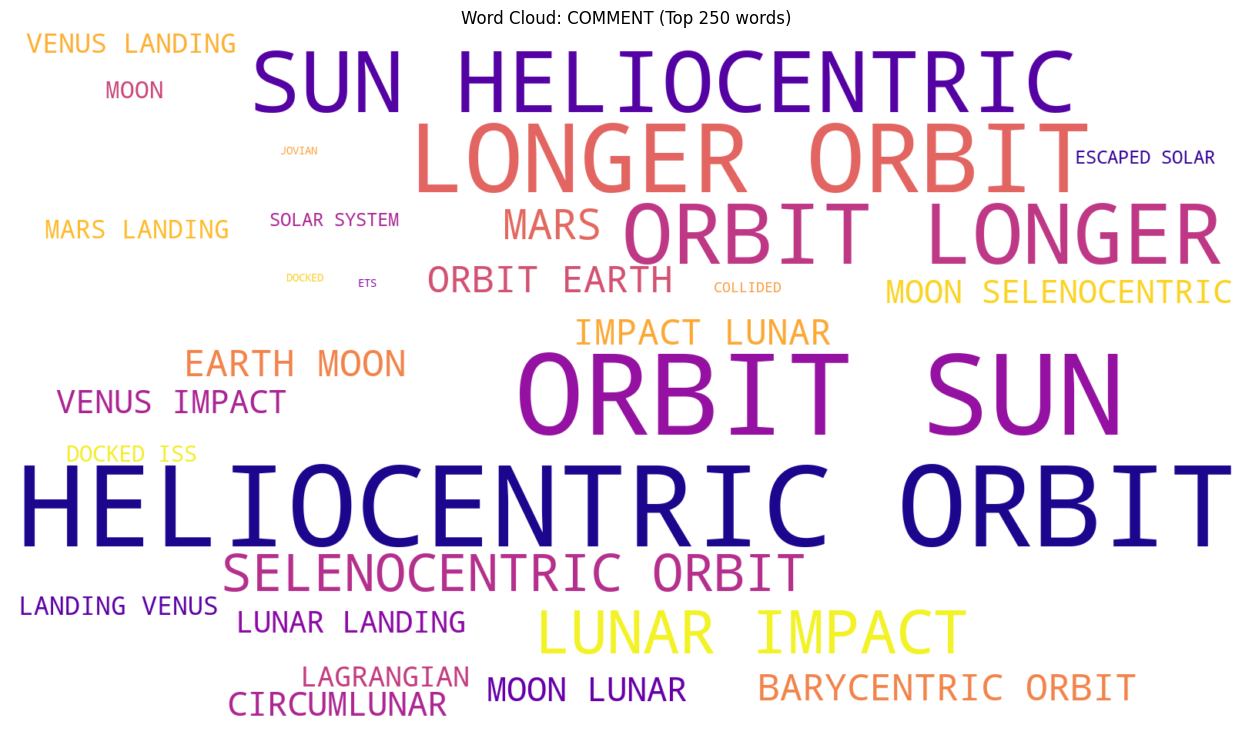

Total words processed: 1360
Unique words in cloud: 29


In [2]:
# Inputs: satnav_tidy['COMMENT'] | Process: generate word cloud | Outputs: word cloud visualization
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

# --- Editable settings ---
# text_column: Column name to analyze
text_column = 'COMMENT'

# max_words: Maximum number of words to display
max_words = 250

# background_color: Background color of the word cloud
background_color = 'white'

# colormap: Matplotlib colormap for word colors
colormap = 'plasma'

# width, height: Output image size in pixels
width, height = 1600, 900

# stopwords_extra: Domain-specific words to remove
stopwords_extra = {
    'SAT', 'SATELLITE', 'OBJECT', 'DEBRIS', 'PAYLOAD', 'ROCKET', 'BODY',
    'UNKNOWN', 'COMMENT', 'NONE', 'NULL', 'EMPTY', 'TBD', 'TBA' ,'ELEMENTS', 'INITIAL', 'AVAILABLE'
}

# min_word_length: Minimum word length to include
min_word_length = 3

# relative_scaling: Relative importance of word frequency vs font size (0-1)
relative_scaling = 0.5

# collocations: Whether to include bigrams
collocations = True
# -------------------------

# Validate column exists
if text_column not in satnav_tidy.columns:
    raise KeyError(f"Column '{text_column}' not found. Available: {list(satnav_tidy.columns)}")

# Build stopwords set
stopwords = set(STOPWORDS)
stopwords |= {w.lower() for w in stopwords_extra}

# Prepare text: join non-null values and filter by length
comments_series = satnav_tidy[text_column].dropna().astype(str)
processed_text = ' '.join(
    word.upper() for comment in comments_series 
    for word in comment.split() 
    if len(word) >= min_word_length and word.lower() not in stopwords
)

if not processed_text.strip():
    print(f"No valid text found in '{text_column}' column")
else:
    # Generate word cloud
    wc = WordCloud(
        width=width,
        height=height,
        background_color=background_color,
        stopwords=stopwords,
        max_words=max_words,
        colormap=colormap,
        collocations=collocations,
        relative_scaling=relative_scaling,
        normalize_plurals=True,
        min_word_length=min_word_length
    ).generate(processed_text)

    # Display
    plt.figure(figsize=(width/100, height/100))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud: {text_column} (Top {max_words} words)")
    plt.show()
    
    print(f"Total words processed: {len(processed_text.split())}")
    print(f"Unique words in cloud: {len(wc.words_)}")

Explore RCS Size

In [ ]:
# Inputs: satnav_tidy['rcs_size'] | Process: create bar and pie charts | Outputs: side-by-side visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# Get value counts
rcs_counts = satnav_tidy['rcs_size'].value_counts(dropna=False)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
sns.barplot(
    x=rcs_counts.index.astype(str),
    y=rcs_counts.values,
    ax=ax1,
    color='skyblue',
    edgecolor='black'
)
ax1.set_title('RCS Value Distribution (Bar Chart)')
ax1.set_xlabel('RCS Value')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, axis='y', alpha=0.3)

# Pie chart
ax2.pie(
    rcs_counts.values,
    labels=rcs_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("husl", len(rcs_counts))
)
ax2.set_title('RCS Value Distribution (Pie Chart)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("RCS Value Summary:")
print(rcs_counts)
print(f"\nTotal objects: {rcs_counts.sum():,}")
print(f"Unique RCS values: {len(rcs_counts)}")

Create Launch Info hierarchy 

In [ ]:
# Inputs: satnav_tidy, list of hierarchical columns | Process: create hierarchy | Outputs: hierarchical DataFrame
import pandas as pd

# Define hierarchy levels (from most general to most specific)
hierarchy_columns = ['country', 'site', 'object_type', 'rcs_size']

# Create hierarchical grouping
hierarchy_df = satnav_tidy.groupby(hierarchy_columns).agg({
    'INTLDES': 'count',  # Count objects at each level
    'NORAD_CAT_ID': 'nunique'  # Unique NORAD IDs
}).rename(columns={'INTLDES': 'object_count', 'NORAD_CAT_ID': 'unique_objects'})

# Reset index to make hierarchy levels as columns
hierarchy_df = hierarchy_df.reset_index()

# Add hierarchy level indicators
hierarchy_df['hierarchy_level'] = hierarchy_df.apply(
    lambda row: sum(pd.notna(row[col]) for col in hierarchy_columns), axis=1
)

print("Hierarchy created with levels:")
for i, col in enumerate(hierarchy_columns):
    print(f"Level {i+1}: {col}")

In [ ]:
# Inputs: satnav_tidy | Process: create datetime hierarchy | Outputs: hierarchical time analysis
# Convert to datetime if needed
satnav_tidy['LAUNCH'] = pd.to_datetime(satnav_tidy['LAUNCH'], errors='coerce')

# Create datetime hierarchy levels
satnav_tidy['launch_year'] = satnav_tidy['LAUNCH'].dt.year
satnav_tidy['launch_quarter'] = satnav_tidy['LAUNCH'].dt.quarter
satnav_tidy['launch_month'] = satnav_tidy['LAUNCH'].dt.month
satnav_tidy['launch_month_name'] = satnav_tidy['LAUNCH'].dt.month_name()

# Create time hierarchy grouping
time_hierarchy = satnav_tidy.groupby(['launch_year', 'launch_quarter', 'launch_month', 'launch_month_name']).agg({
    'INTLDES': 'count',
    'country': 'count',
    'object_type': 'count'
}).rename(columns={
    'INTLDES': 'launches',
    'country': 'countries',
    'object_type': 'object_types'
})


In [ ]:
cols_to_remove = ['CREATION_DATE']  # edit this list

satnav_tidy = satnav_tidy.drop(columns=cols_to_remove, errors='ignore').copy()

print(satnav_tidy.shape)

show_freeze_header(
    satnav_tidy.head(500),
    height=400
)

Create Hierarchies 

Launch Date	
	Launch Year
	Launch Quarter
	Launch Month
	Launch Day

Decay Date	
	Decay Year
	Decay Quarter
	Decay Month
	Decay Date

Launch Details	
	INTLDES
	Launch Year
	Launch Num
	Object Number
	Launch Piece

Launch Geography	
	Country 
	Site

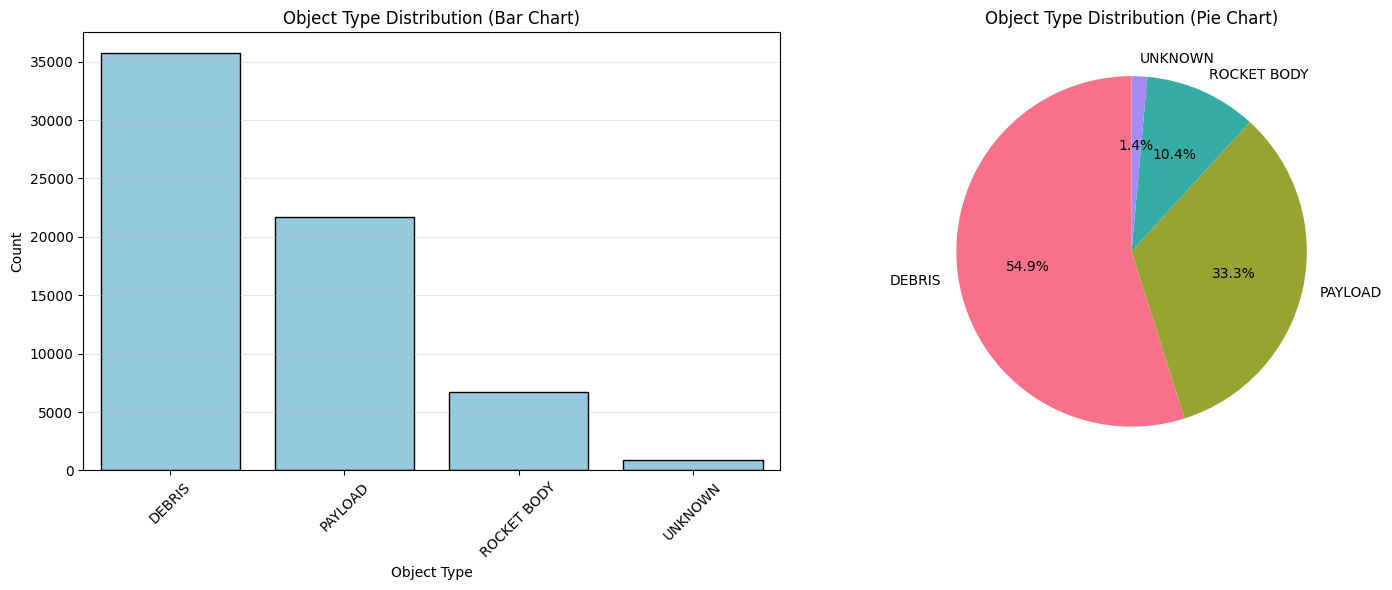

Object Type Summary:
object_type
DEBRIS         35725
PAYLOAD        21695
ROCKET BODY     6737
UNKNOWN          931
Name: count, dtype: int64

Total objects: 65,088
Unique Object Types: 4


In [3]:
# Inputs: satnav_tidy['rcs_size'] | Process: create bar and pie charts | Outputs: side-by-side visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# Get value counts
rcs_counts = satnav_tidy['object_type'].value_counts(dropna=False)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
sns.barplot(
    x=rcs_counts.index.astype(str),
    y=rcs_counts.values,
    ax=ax1,
    color='skyblue',
    edgecolor='black'
)
ax1.set_title('Object Type Distribution (Bar Chart)')
ax1.set_xlabel('Object Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, axis='y', alpha=0.3)

# Pie chart
ax2.pie(
    rcs_counts.values,
    labels=rcs_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("husl", len(rcs_counts))
)
ax2.set_title('Object Type Distribution (Pie Chart)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Object Type Summary:")
print(rcs_counts)
print(f"\nTotal objects: {rcs_counts.sum():,}")
print(f"Unique Object Types: {len(rcs_counts)}")

In [ ]:
# won't work becasue SATNAME has too many items
# Inputs: satnav_tidy['rcs_size'] | Process: create bar and pie charts | Outputs: side-by-side visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# Get value counts
rcs_counts = satnav_tidy['SATNAME'].value_counts(dropna=False)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
sns.barplot(
    x=rcs_counts.index.astype(str),
    y=rcs_counts.values,
    ax=ax1,
    color='skyblue',
    edgecolor='black'
)
ax1.set_title('Satellite Name Distribution (Bar Chart)')
ax1.set_xlabel('Satellite Name')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, axis='y', alpha=0.3)

# Pie chart
ax2.pie(
    rcs_counts.values,
    labels=rcs_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("husl", len(rcs_counts))
)
ax2.set_title('Satellite Name Distribution (Pie Chart)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Satellite Name Summary:")
print(rcs_counts)
print(f"\nTotal objects: {rcs_counts.sum():,}")
print(f"Unique Satellite Names: {len(rcs_counts)}")

In [ ]:
# Inputs: satnav_tidy['COMMENT'] | Process: generate word cloud | Outputs: word cloud visualization
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

# --- Editable settings ---
# text_column: Column name to analyze
text_column = 'SATNAME'

# max_words: Maximum number of words to display
max_words = 200

# background_color: Background color of the word cloud
background_color = 'white'

# colormap: Matplotlib colormap for word colors
colormap = 'plasma'

# width, height: Output image size in pixels
width, height = 1600, 900

# stopwords_extra: Domain-specific words to remove
stopwords_extra = {
    
    'UNKNOWN', 'DEB', 'COMMENT', 'NONE', 'NULL', 'EMPTY', 'TBD', 'TBA' ,'ELEMENTS', 'INITIAL', 'AVAILABLE'
}

# min_word_length: Minimum word length to include
min_word_length = 3

# relative_scaling: Relative importance of word frequency vs font size (0-1)
relative_scaling = 0.5

# collocations: Whether to include bigrams
collocations = True
# -------------------------

# Validate column exists
if text_column not in satnav_tidy.columns:
    raise KeyError(f"Column '{text_column}' not found. Available: {list(satnav_tidy.columns)}")

# Build stopwords set
stopwords = set(STOPWORDS)
stopwords |= {w.lower() for w in stopwords_extra}

# Prepare text: join non-null values and filter by length
comments_series = satnav_tidy[text_column].dropna().astype(str)
processed_text = ' '.join(
    word.upper() for comment in comments_series 
    for word in comment.split() 
    if len(word) >= min_word_length and word.lower() not in stopwords
)

if not processed_text.strip():
    print(f"No valid text found in '{text_column}' column")
else:
    # Generate word cloud
    wc = WordCloud(
        width=width,
        height=height,
        background_color=background_color,
        stopwords=stopwords,
        max_words=max_words,
        colormap=colormap,
        collocations=collocations,
        relative_scaling=relative_scaling,
        normalize_plurals=True,
        min_word_length=min_word_length
    ).generate(processed_text)

    # Display
    plt.figure(figsize=(width/100, height/100))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud: {text_column} (Top {max_words} words)")
    plt.show()
    
    print(f"Total words processed: {len(processed_text.split())}")
    print(f"Unique words in cloud: {len(wc.words_)}")

In [ ]:
# Map 'COUNTRY' to 'country_map' and 'ISO3'
satnav_tidy['country_map'] = satnav_tidy['COUNTRY'].map(spadoc_mapping)
satnav_tidy['iso3'] = satnav_tidy['COUNTRY'].map(spadoc_mapping)

# Check mapping coverage
mapped_count = satnav_tidy['country_map'].notna().sum()
total_count = len(satnav_tidy)
print(f"Mapping coverage: {mapped_count}/{total_count} ({mapped_count/total_count*100:.2f}%)")

# Create new columns from the mapping dictionary
satnav_tidy['country_map'] = satnav_tidy['COUNTRY'].map(spadoc_mapping).apply(lambda x: x['country_map'] if pd.notna(x) else None)
satnav_tidy['iso3'] = satnav_tidy['COUNTRY'].map(spadoc_mapping).apply(lambda x: x['iso3'] if pd.notna(x) else None)

Explore Country of Origin

In [ ]:
# Inputs: satnav_tidy | Process: find unmapped records | Outputs: subset of unmapped data
# Find records where country_map is None/NaN
unmapped_records = satnav_tidy[satnav_tidy['country_map'].isna()]

print(f"Unmapped records: {len(unmapped_records)}")
print(f"Percentage unmapped: {(len(unmapped_records)/len(satnav_tidy)*100):.2f}%")

# Show the unique COUNTRY values that couldn't be mapped
unmapped_countries = unmapped_records['COUNTRY'].unique()
print(f"\nUnmapped COUNTRY values ({len(unmapped_countries)} unique):")
for country in sorted(unmapped_countries):
    count = unmapped_records[unmapped_records['COUNTRY'] == country].shape[0]
    print(f"  {country}: {count} records")

# Display sample of unmapped records
print(f"\nSample of unmapped records:")
show_freeze_header(unmapped_records[['COUNTRY', 'country_map', 'iso3']].head(20), height=400)

# Optional: Check if these unmapped values exist in spadoc_mapping
print(f"\nChecking if unmapped values exist in spadoc_mapping:")
for country in unmapped_countries[:10]:  # Check first 10
    if country in spadoc_mapping:
        print(f"  {country}: EXISTS in mapping")
    else:
        print(f"  {country}: MISSING from mapping")

In [52]:
# Inputs: satnav_tidy | Process: save CSV | Outputs: file path
from pathlib import Path

out_path = Path("../data/processed/satnav_tidy.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
satnav_tidy.to_csv(out_path, index=False)
print("Saved:", out_path.resolve())

Saved: /Users/aaeush/Desktop/Drive/Drive/Academics/Py Project/MyCode/OrbitIQ/orbitiq/data/processed/satnav_tidy.csv


In [54]:
# Inputs: satnav_tidy, list of columns | Process: find unique values | Outputs: unique values for each column
# Define columns to analyze
columns_to_check = ['iso3']  # edit this list

# Find unique values for each column
for col in columns_to_check:
    if col in satnav_tidy.columns:
        unique_vals = satnav_tidy[col].dropna().unique()
        print(f"\n{col} ({len(unique_vals)} unique values):")
        print(f"  {sorted(unique_vals)[:20]}")  # Show first 20
        
        if len(unique_vals) > 20:
            print(f"  ... and {len(unique_vals) - 20} more values")
    else:
        print(f"\n{col}: Column not found in DataFrame")

# Alternative: Get all unique values in a DataFrame format
unique_summary = {}
for col in columns_to_check:
    if col in satnav_tidy.columns:
        unique_summary[col] = {
            'unique_count': satnav_tidy[col].nunique(),
            'null_count': satnav_tidy[col].isna().sum(),
            'sample_values': list(satnav_tidy[col].dropna().unique()[:10])
        }

# Display summary
print(f"\n{'='*50}")
print("UNIQUE VALUES SUMMARY")
print(f"{'='*50}")
for col, info in unique_summary.items():
    print(f"\n{col}:")
    print(f"  Unique values: {info['unique_count']}")
    print(f"  Null values: {info['null_count']}")
    print(f"  Sample: {info['sample_values']}")


iso3 (99 unique values):
  ['AGO', 'ARE', 'ARG', 'AUS', 'AUT', 'AZE', 'BEL', 'BGD', 'BGR', 'BHR', 'BLR', 'BOL', 'BRA', 'BWA', 'CAN', 'CHE', 'CHL', 'CHN', 'COL', 'CRI']
  ... and 79 more values

UNIQUE VALUES SUMMARY

iso3:
  Unique values: 99
  Null values: 0
  Sample: ['MULTI', 'USA', 'GBR', 'CAN', 'ITA', 'ORG', 'FRA', 'AUS', 'DEU', 'JPN']


In [59]:
# Inputs: satnav_tidy, list of words to check | Process: filter records containing specific words | Outputs: iso_notstd DataFrame
# Define words to check for in iso3 column
words_to_check = ['UNK', 'MULTI', 'ORG', 'OLD', 'PVT', 'TBD']  # edit this list

# Check if any record has these words in iso3 column
mask = satnav_tidy['iso3'].astype(str).str.upper().isin([word.upper() for word in words_to_check])

# Create new DataFrame with matching records
iso_notstd = satnav_tidy[mask].copy()

print(f"Records found with non-standard ISO3 values: {len(iso_notstd)}")
print(f"Percentage of total: {(len(iso_notstd)/len(satnav_tidy)*100):.2f}%")

# Show breakdown of what was found
if not iso_notstd.empty:
    print(f"\nBreakdown of non-standard ISO3 values:")
    iso_counts = iso_notstd['iso3'].value_counts()
    for iso, count in iso_counts.items():
        print(f"  {iso}: {count} records")
    
    # Display sample records
    print(f"\nSample of non-standard ISO3 records:")
    show_freeze_header(iso_notstd[['COUNTRY', 'iso3', 'country_map']].head(20), height=400)
else:
    print("No records found with non-standard ISO3 values")

# Optional: Check what standard ISO3 values look like
print(f"\nStandard ISO3 values (first 10):")
standard_iso = satnav_tidy[~mask]['iso3'].dropna().unique()
print(sorted(standard_iso)[:10])

Records found with non-standard ISO3 values: 26424
Percentage of total: 40.60%

Breakdown of non-standard ISO3 values:
  MULTI: 25269 records
  ORG: 440 records
  UNK: 421 records
  PVT: 291 records
  OLD: 3 records

Sample of non-standard ISO3 records:

Standard ISO3 values (first 10):
['AGO', 'ARE', 'ARG', 'AUS', 'AUT', 'AZE', 'BEL', 'BGD', 'BGR', 'BHR']


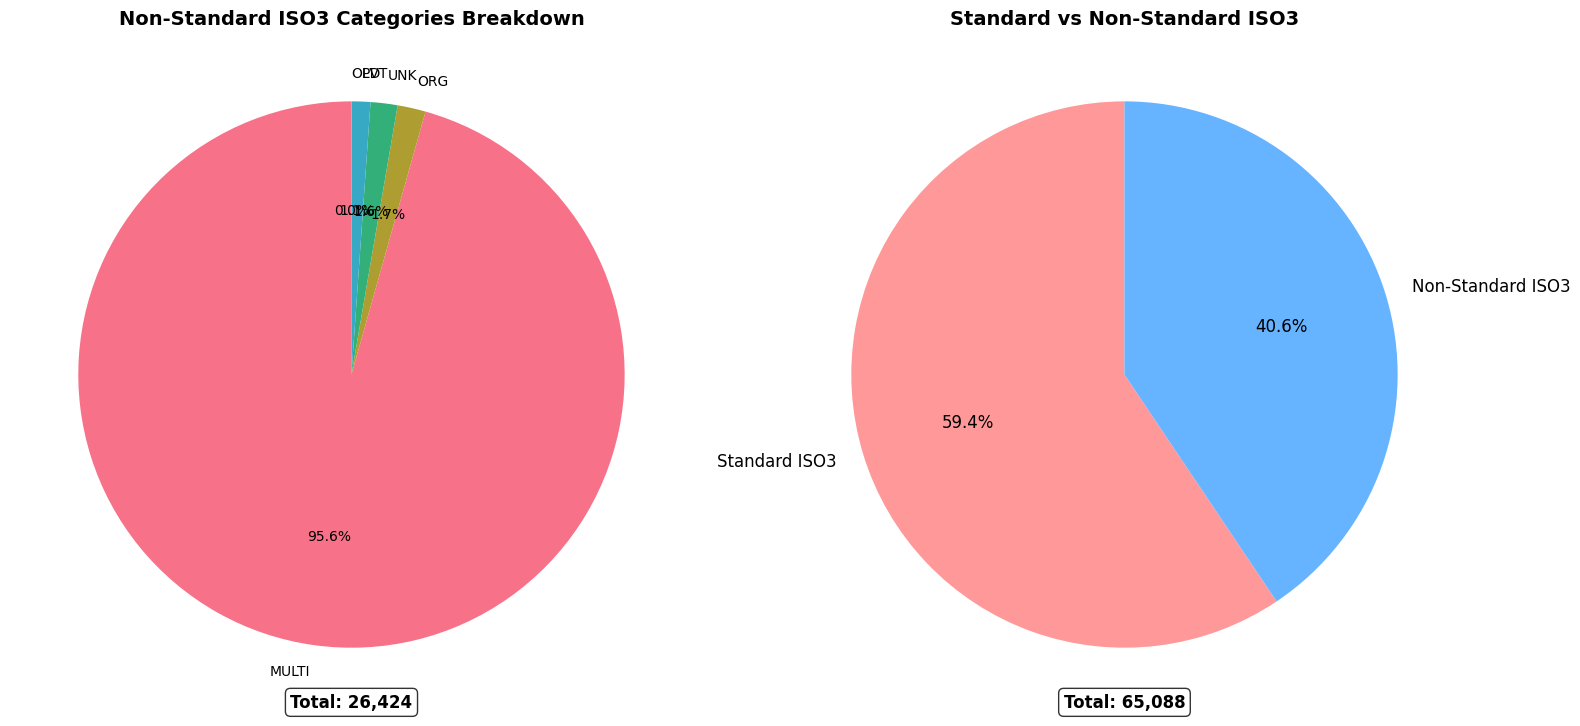

ISO3 Data Summary:
Total records: 65,088
Standard ISO3: 38,664 (59.4%)
Non-standard ISO3: 26,424 (40.6%)

Non-standard breakdown:
  MULTI: 25,269 (95.6%)
  ORG: 440 (1.7%)
  UNK: 421 (1.6%)
  PVT: 291 (1.1%)
  OLD: 3 (0.0%)

Sample of standard ISO3 codes:
  ['USA', 'CHN', 'FRA', 'JPN', 'IND', 'GBR', 'DEU', 'ITA', 'CAN', 'ESP']


In [4]:
# Create pie charts for ISO3 data distribution - extracting data from satnav_tidy
import matplotlib.pyplot as plt
import seaborn as sns

# Extract ISO3 data from the DataFrame
iso3_counts = satnav_tidy['iso3'].value_counts(dropna=False)

# Identify standard vs non-standard ISO3 values
# Standard ISO3 codes are typically 3-letter country codes
# Non-standard ones from your analysis are: MULTI, ORG, UNK, PVT, OLD
non_standard_codes = ['MULTI', 'ORG', 'UNK', 'PVT', 'OLD']
standard_mask = ~iso3_counts.index.isin(non_standard_codes)

# Calculate totals
standard_total = iso3_counts[standard_mask].sum()
non_standard_total = iso3_counts[~standard_mask].sum()

# Get non-standard breakdown
non_standard_breakdown = iso3_counts[~standard_mask]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Pie chart 1: Non-standard ISO3 categories breakdown only
colors1 = sns.color_palette("husl", len(non_standard_breakdown))
ax1.pie(
    non_standard_breakdown.values,
    labels=non_standard_breakdown.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors1,
    textprops={'fontsize': 10}
)
ax1.set_title('Non-Standard ISO3 Categories Breakdown', fontsize=14, fontweight='bold')
# Add total count as static text
ax1.text(0, -1.2, f'Total: {non_standard_total:,}', ha='center', va='center', 
         fontsize=12, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Pie chart 2: Standard vs Non-standard (2 categories)
colors2 = ['#ff9999', '#66b3ff']
ax2.pie(
    [standard_total, non_standard_total],
    labels=['Standard ISO3', 'Non-Standard ISO3'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors2,
    textprops={'fontsize': 12}
)
ax2.set_title('Standard vs Non-Standard ISO3', fontsize=14, fontweight='bold')
# Add total count as static text
ax2.text(0, -1.2, f'Total: {iso3_counts.sum():,}', ha='center', va='center', 
         fontsize=12, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics
print("ISO3 Data Summary:")
print("=" * 50)
print(f"Total records: {iso3_counts.sum():,}")
print(f"Standard ISO3: {standard_total:,} ({standard_total/iso3_counts.sum()*100:.1f}%)")
print(f"Non-standard ISO3: {non_standard_total:,} ({non_standard_total/iso3_counts.sum()*100:.1f}%)")
print("\nNon-standard breakdown:")
for category, count in non_standard_breakdown.items():
    percentage = count/non_standard_total*100  # Percentage within non-standard only
    print(f"  {category}: {count:,} ({percentage:.1f}%)")

# Show sample of standard ISO3 codes
print(f"\nSample of standard ISO3 codes:")
standard_codes = iso3_counts[standard_mask].head(10).index.tolist()
print(f"  {standard_codes}")

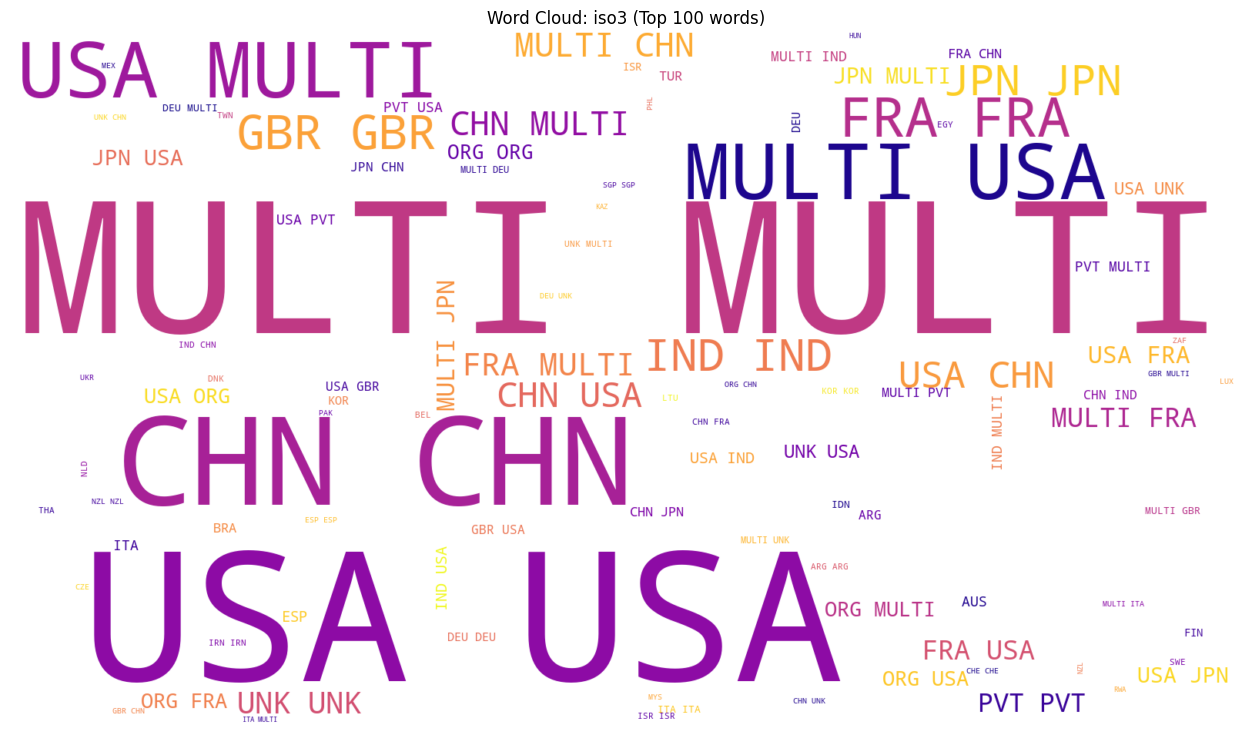

Total words processed: 64933
Unique words in cloud: 100


In [8]:
# Inputs: satnav_tidy['COMMENT'] | Process: generate word cloud | Outputs: word cloud visualization
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

# --- Editable settings ---
# text_column: Column name to analyze
text_column = 'iso3'

# max_words: Maximum number of words to display
max_words = 100

# background_color: Background color of the word cloud
background_color = 'white'

# colormap: Matplotlib colormap for word colors
colormap = 'plasma'

# width, height: Output image size in pixels
width, height = 1600, 900

# stopwords_extra: Domain-specific words to remove
stopwords_extra = {
    
    # 'UNKNOWN', 'DEB', 'COMMENT', 'NONE', 'NULL', 'EMPTY', 'TBD', 'TBA' ,'ELEMENTS', 'INITIAL', 'AVAILABLE'
}

# min_word_length: Minimum word length to include
min_word_length = 3

# relative_scaling: Relative importance of word frequency vs font size (0-1)
relative_scaling = 0.5

# collocations: Whether to include bigrams
collocations = True
# -------------------------

# Validate column exists
if text_column not in satnav_tidy.columns:
    raise KeyError(f"Column '{text_column}' not found. Available: {list(satnav_tidy.columns)}")

# Build stopwords set
stopwords = set(STOPWORDS)
stopwords |= {w.lower() for w in stopwords_extra}

# Prepare text: join non-null values and filter by length
comments_series = satnav_tidy[text_column].dropna().astype(str)
processed_text = ' '.join(
    word.upper() for comment in comments_series 
    for word in comment.split() 
    if len(word) >= min_word_length and word.lower() not in stopwords
)

if not processed_text.strip():
    print(f"No valid text found in '{text_column}' column")
else:
    # Generate word cloud
    wc = WordCloud(
        width=width,
        height=height,
        background_color=background_color,
        stopwords=stopwords,
        max_words=max_words,
        colormap=colormap,
        collocations=collocations,
        relative_scaling=relative_scaling,
        normalize_plurals=True,
        min_word_length=min_word_length
    ).generate(processed_text)

    # Display
    plt.figure(figsize=(width/100, height/100))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud: {text_column} (Top {max_words} words)")
    plt.show()
    
    print(f"Total words processed: {len(processed_text.split())}")
    print(f"Unique words in cloud: {len(wc.words_)}")

Explore SATNAME

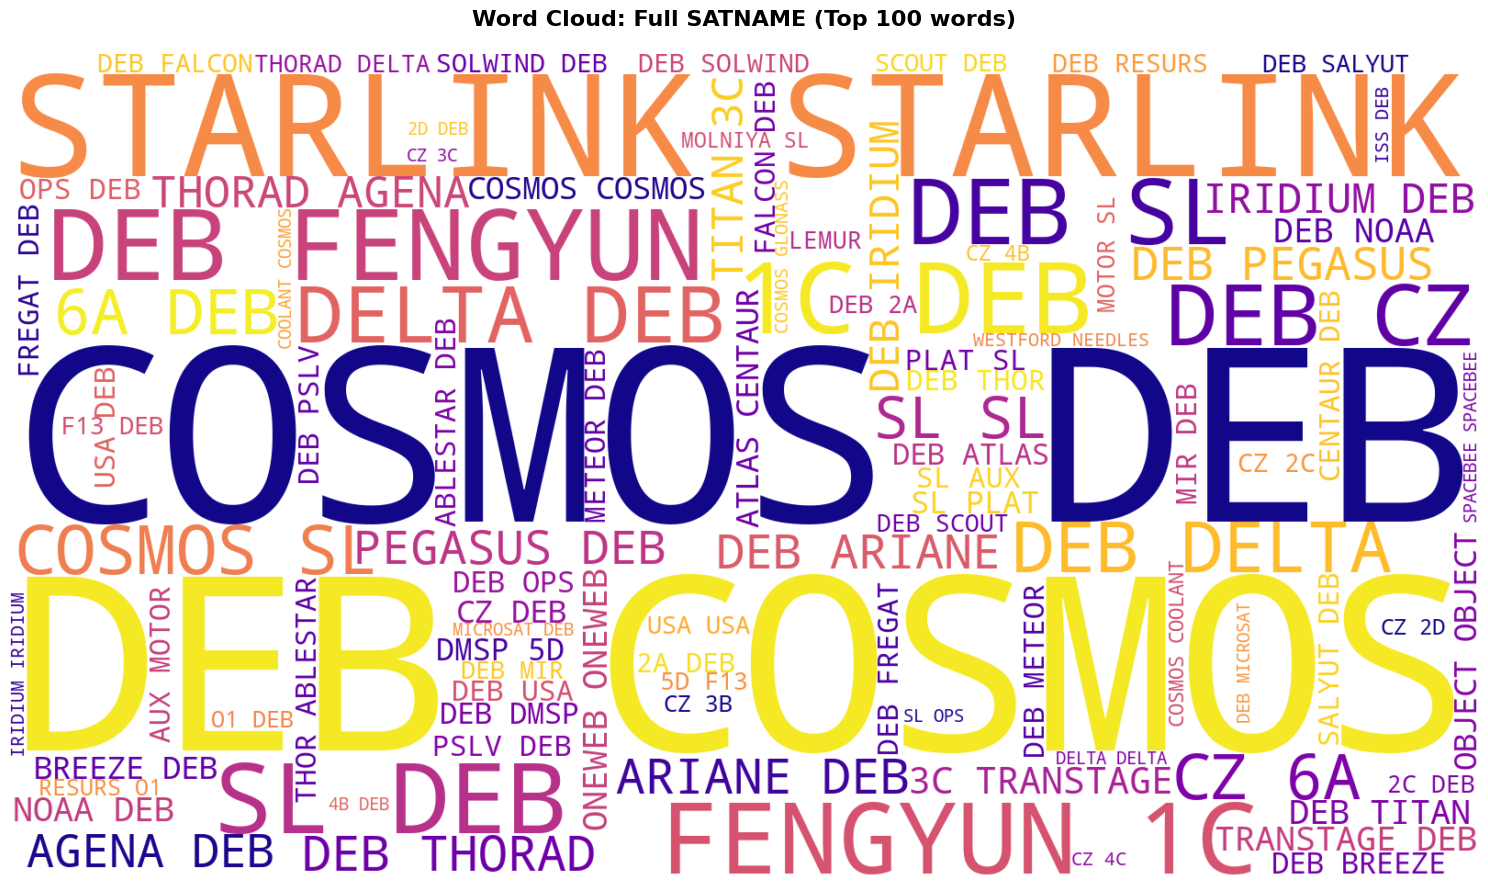

Full SATNAME analysis:
  Total words processed: 141422
  Unique words in cloud: 100


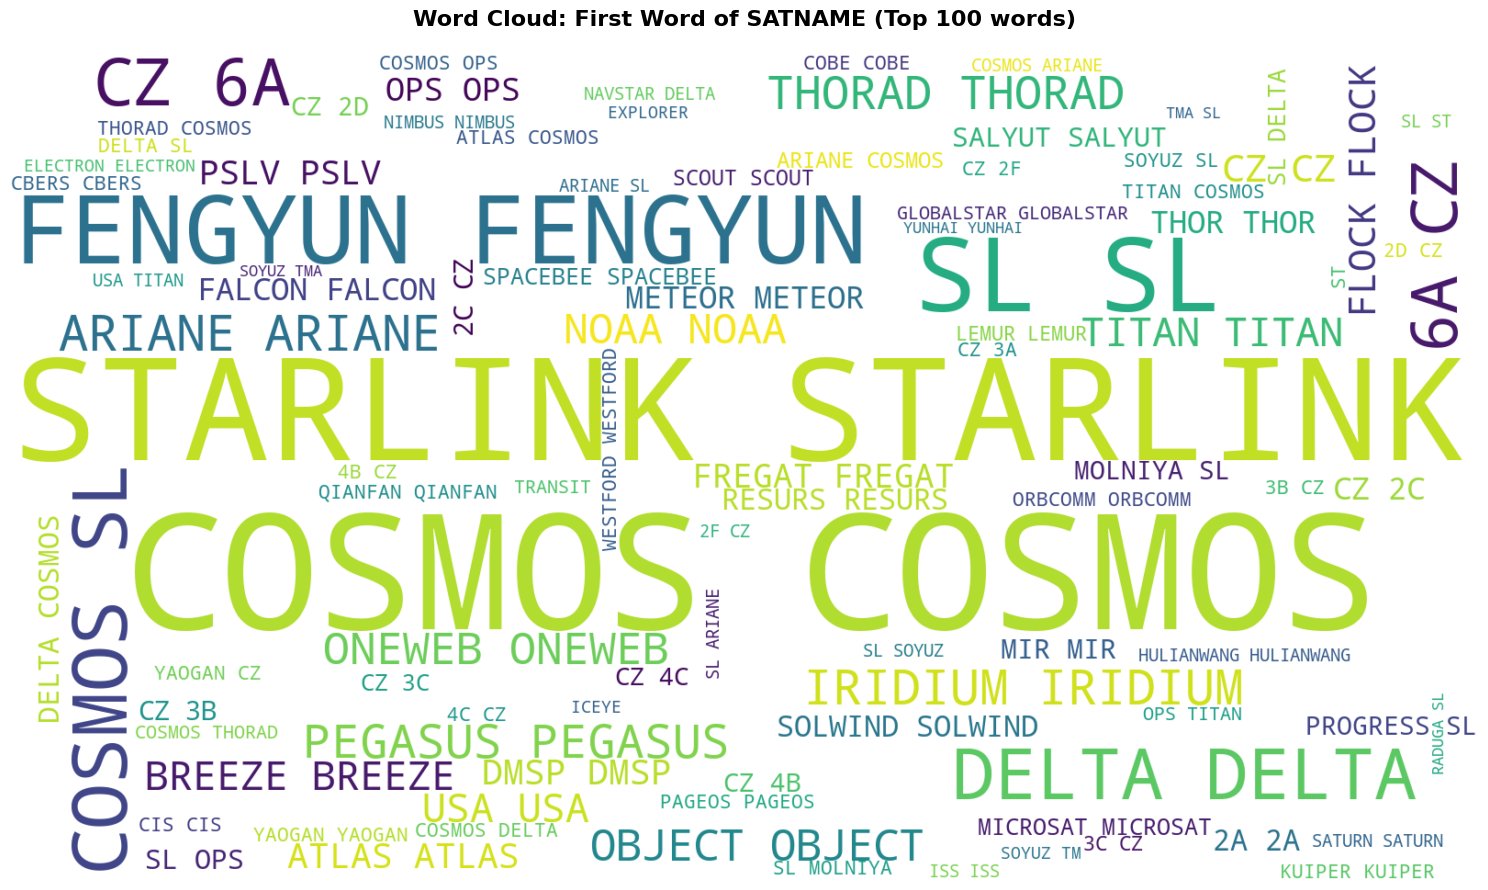


First word analysis:
  Total first words processed: 65081
  Unique first words in cloud: 100
  Top 10 first words:
    COSMOS: 13328
    FENGYUN: 3567
    DELTA: 2521
    SL-12: 1770
    SL-4: 1677
    CZ-6A: 1518
    ARIANE: 1231
    SL-6: 1110
    SL-8: 1074
    OBJECT: 930


In [13]:
# Inputs: satnav_tidy['SATNAME'] | Process: generate word clouds for full names and first words | Outputs: two separate word cloud visualizations
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

# --- Editable settings ---
# text_column: Column name to analyze
text_column = 'SATNAME'

# max_words: Maximum number of words to display
max_words = 100

# background_color: Background color of the word cloud
background_color = 'white'

# colormap: Matplotlib colormap for word colors
colormap = 'plasma'

# width, height: Output image size in pixels
width, height = 1600, 900

# stopwords_extra: Domain-specific words to remove
stopwords_extra = {
    #  'SAT', 'SATELLITE', 'OBJECT', 'DEBRIS', 'PAYLOAD', 'ROCKET', 'BODY',
    #  'UNKNOWN', 'COMMENT', 'NONE', 'NULL', 'EMPTY', 'TBD', 'TBA', 'ELEMENTS', 'INITIAL', 'AVAILABLE',
    # 'STARLINK', 'COSMOS', 'NAVSTAR', 'ONEWEB', 'RESURS', 'SHIJIAN', 'FENGYUN', 'ZHUHAI', 'TECHNOLOGY', 'SERIES'
}

# min_word_length: Minimum word length to include
min_word_length = 2

# relative_scaling: Relative importance of word frequency vs font size (0-1)
relative_scaling = 0.5

# collocations: Whether to include bigrams
collocations = True
# -------------------------

# Validate column exists
if text_column not in satnav_tidy.columns:
    raise KeyError(f"Column '{text_column}' not found. Available: {list(satnav_tidy.columns)}")

# Build stopwords set
stopwords = set(STOPWORDS)
stopwords |= {w.lower() for w in stopwords_extra}

# Prepare text for full SATNAME analysis
satname_series = satnav_tidy[text_column].dropna().astype(str)
full_text = ' '.join(
    word.upper() for satname in satname_series 
    for word in satname.split() 
    if len(word) >= min_word_length and word.lower() not in stopwords
)

# Prepare text for first word analysis only
first_words = []
for satname in satname_series:
    words = satname.split()
    if words and len(words[0]) >= min_word_length and words[0].lower() not in stopwords:
        first_words.append(words[0].upper())
first_words_text = ' '.join(first_words)

# Word Cloud 1: Full SATNAME analysis
if full_text.strip():
    wc1 = WordCloud(
        width=width, height=height,
        background_color=background_color,
        stopwords=stopwords,
        max_words=max_words,
        colormap=colormap,
        collocations=collocations,
        relative_scaling=relative_scaling,
        normalize_plurals=True,
        min_word_length=min_word_length
    ).generate(full_text)
    
    plt.figure(figsize=(width/100, height/100))
    plt.imshow(wc1, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud: Full {text_column} (Top {max_words} words)", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print(f"Full SATNAME analysis:")
    print(f"  Total words processed: {len(full_text.split())}")
    print(f"  Unique words in cloud: {len(wc1.words_)}")
else:
    print(f"No valid text found in {text_column}")

# Word Cloud 2: First word analysis only
if first_words_text.strip():
    wc2 = WordCloud(
        width=width, height=height,
        background_color=background_color,
        stopwords=stopwords,
        max_words=max_words,
        colormap='viridis',  # Different colormap to distinguish from first cloud
        collocations=collocations,
        relative_scaling=relative_scaling,
        normalize_plurals=True,
        min_word_length=min_word_length
    ).generate(first_words_text)
    
    plt.figure(figsize=(width/100, height/100))
    plt.imshow(wc2, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud: First Word of {text_column} (Top {max_words} words)", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFirst word analysis:")
    print(f"  Total first words processed: {len(first_words)}")
    print(f"  Unique first words in cloud: {len(wc2.words_)}")
    
    # Show most common first words
    from collections import Counter
    first_word_counts = Counter(first_words)
    print(f"  Top 10 first words:")
    for word, count in first_word_counts.most_common(10):
        print(f"    {word}: {count}")
else:
    print(f"No valid first words found in {text_column}")

Explore Site

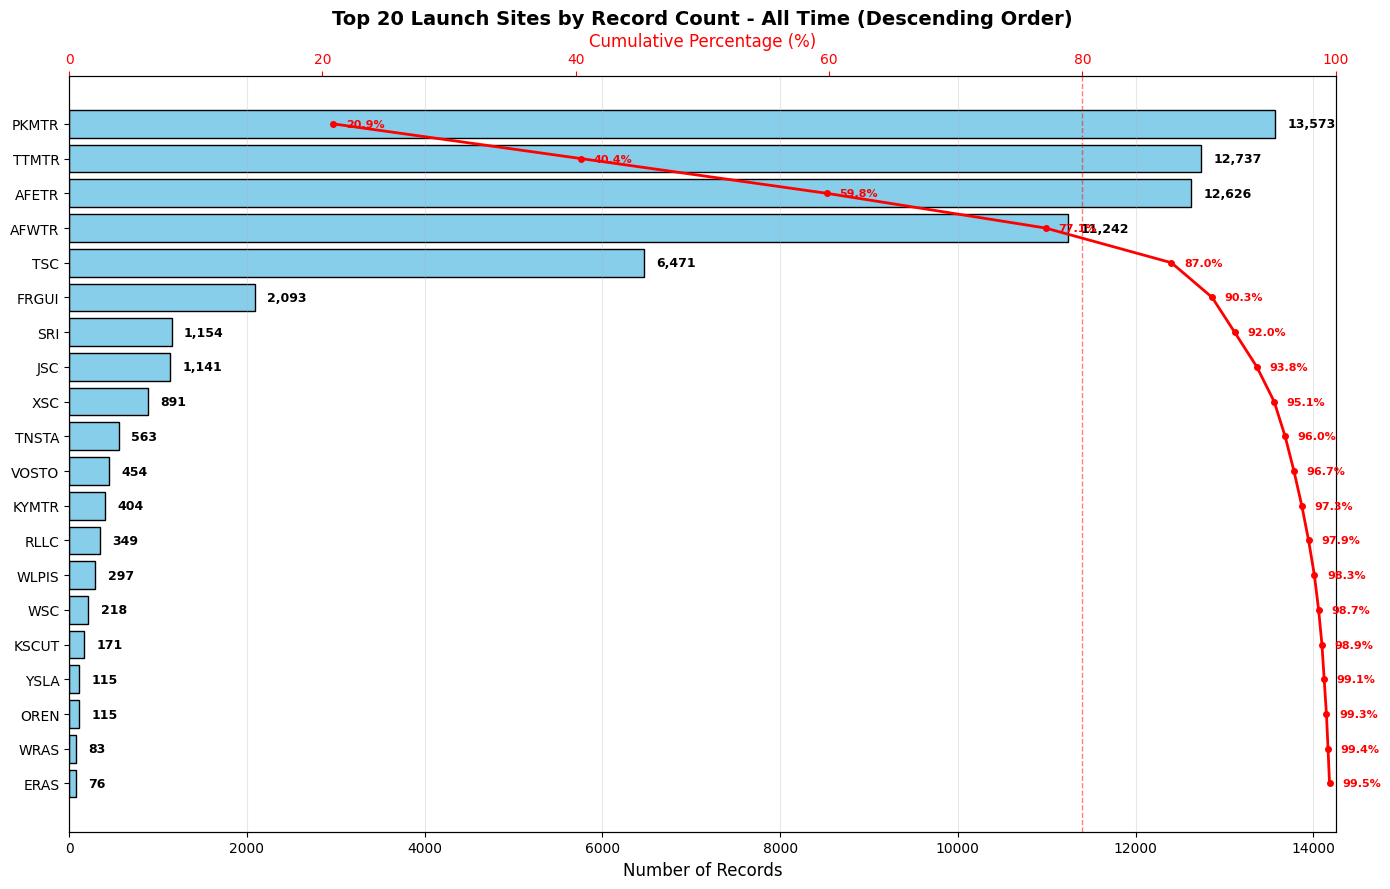

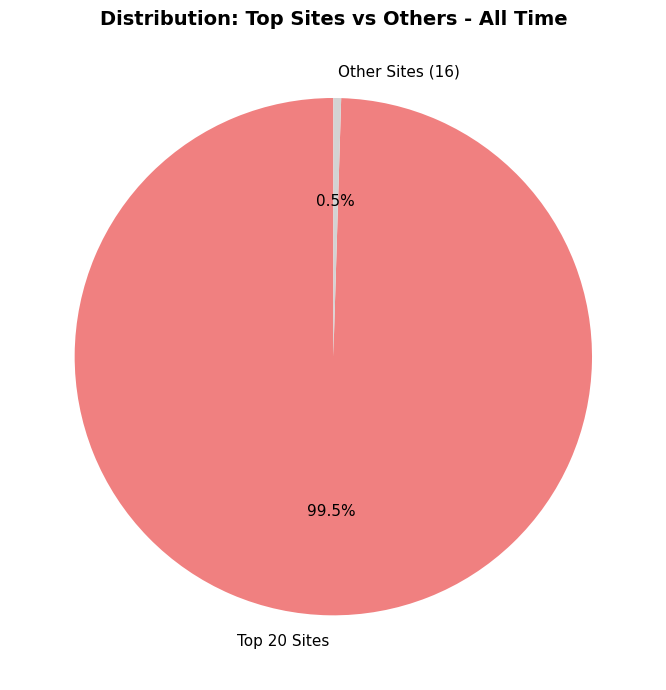

SITE COLUMN ANALYSIS
Total records: 65,088
Total unique sites: 36
Records with null site: 0 (0.0%)
Records with valid site: 65,088 (100.0%)
Top site: 'PKMTR' with 13,573 records (20.9%)

Top 10 Sites Breakdown:
----------------------------------------
 1. PKMTR                  13,573 records ( 20.9%)
 2. TTMTR                  12,737 records ( 19.6%)
 3. AFETR                  12,626 records ( 19.4%)
 4. AFWTR                  11,242 records ( 17.3%)
 5. TSC                     6,471 records (  9.9%)
 6. FRGUI                   2,093 records (  3.2%)
 7. SRI                     1,154 records (  1.8%)
 8. JSC                     1,141 records (  1.8%)
 9. XSC                       891 records (  1.4%)
10. TNSTA                     563 records (  0.9%)

Site Concentration Analysis:
----------------------------------------
Top 1 sites contain:  20.9% of all records
Top 5 sites contain:  87.0% of all records
Top 10 sites contain: 96.0% of all records
Top 20 sites contain: 99.5% of all rec

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# === inputs ===
series = satnav_tidy['site']
top_n_sites = 20  # change this to explore different N

# === prep ===
site_counts = series.value_counts(dropna=False)
total_records = len(series)
total_sites = len(site_counts)
null_sites = series.isna().sum()
unique_sites = series.nunique(dropna=True)

top_n = min(top_n_sites, total_sites)
top_sites = site_counts.head(top_n)

# Pareto cumulative % for the TOP N only (relative to ALL records)
cum_counts = top_sites.cumsum()
cum_pct = (cum_counts / total_records) * 100.0

# y positions (0..N-1), largest first
y = np.arange(top_n)

# === Chart 1: Horizontal bars + Pareto line on top x-axis ===
fig, ax1 = plt.subplots(figsize=(14, 9))

# Bars (counts)
bars = ax1.barh(y, top_sites.values, color='skyblue', edgecolor='black')
ax1.set_yticks(y)
ax1.set_yticklabels(top_sites.index, fontsize=10)
ax1.set_xlabel('Number of Records', fontsize=12)
ax1.set_title(f'Top {top_n} Launch Sites by Record Count - All Time (Descending Order)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, axis='x', alpha=0.3)
ax1.invert_yaxis()  # largest at top

# Value labels on bars
for bar, val in zip(bars, top_sites.values):
    ax1.text(val + max(top_sites.values) * 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9, fontweight='bold')

# Secondary TOP x-axis for cumulative %
ax2 = ax1.twiny()
ax2.set_xlim(0, 100)  # percentage scale
ax2.set_xlabel('Cumulative Percentage (%)', color='red', fontsize=12)
ax2.tick_params(axis='x', colors='red')
ax2.set_ylim(ax1.get_ylim())  # align y extents

# Pareto line (x = cumulative %, y = bars' y)
ax2.plot(cum_pct.values, y, 'r-o', linewidth=2, markersize=4)
# Data labels on the Pareto points
for x_pct, yi in zip(cum_pct.values, y):
    ax2.text(x_pct + 1, yi, f'{x_pct:.1f}%', va='center', fontsize=8, color='red', fontweight='bold')

# Optional: 80-20 reference line
ax2.axvline(80, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

# === Chart 2: Pie – Top N vs Others (dynamic) ===
top_sites_total = int(top_sites.sum())
other_sites_total = int(total_records - top_sites_total)
other_site_count = max(total_sites - top_n, 0)

plt.figure(figsize=(9, 7))
pie_data = [top_sites_total, other_sites_total]
pie_labels = [f'Top {top_n} Sites', f'Other Sites ({other_site_count})']
pie_colors = ['lightcoral', 'lightgray']

plt.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90,
        colors=pie_colors, textprops={'fontsize': 11})
plt.title('Distribution: Top Sites vs Others - All Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# === Console stats (unchanged but uses safe top_n) ===
print("SITE COLUMN ANALYSIS")
print("=" * 60)
print(f"Total records: {total_records:,}")
print(f"Total unique sites: {unique_sites:,}")
print(f"Records with null site: {null_sites:,} ({(null_sites/total_records)*100:.1f}%)")
print(f"Records with valid site: {total_records - null_sites:,} "
      f"({((total_records - null_sites)/total_records)*100:.1f}%)")

top_site_percentage = (site_counts.iloc[0] / total_records) * 100
print(f"Top site: '{site_counts.index[0]}' with {site_counts.iloc[0]:,} "
      f"records ({top_site_percentage:.1f}%)")

print(f"\nTop 10 Sites Breakdown:")
print("-" * 40)
for i, (site, count) in enumerate(site_counts.head(10).items(), 1):
    percentage = (count / total_records) * 100
    print(f"{i:2d}. {site:<20} {count:>8,} records ({percentage:>5.1f}%)")

print(f"\nSite Concentration Analysis:")
print("-" * 40)
print(f"Top 1 sites contain:  {(site_counts.head(1).sum()/total_records)*100:.1f}% of all records")
print(f"Top 5 sites contain:  {(site_counts.head(5).sum()/total_records)*100:.1f}% of all records")
print(f"Top 10 sites contain: {(site_counts.head(10).sum()/total_records)*100:.1f}% of all records")
print(f"Top {top_n} sites contain: {(site_counts.head(top_n).sum()/total_records)*100:.1f}% of all records")

# Rare sites
single_record_sites = site_counts[site_counts == 1]
print(f"\nSites with only 1 record: {len(single_record_sites):,}")
if len(single_record_sites) > 0:
    print("Sample of rare sites:")
    for site in single_record_sites.head(5).index:
        print(f"  - {site}")


Explore numerical data

Available columns: ['INTLDES', 'NORAD_CAT_ID', 'SATNAME', 'COUNTRY', 'LAUNCH', 'DECAY', 'COMMENT', 'LAUNCH_YEAR', 'LAUNCH_NUM', 'LAUNCH_PIECE', 'OBJECT_NUMBER', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS', 'COUNTRY_CODE', 'TLE_LINE1', 'TLE_LINE2', 'object_type', 'site', 'period', 'inclination', 'apoapsis', 'periapsis', 'rcs_size', 'object_name', 'object_id', 'country_map', 'iso3']
Creating histograms for 15 columns: ['LAUNCH_YEAR', 'LAUNCH_NUM', 'MEAN_MOTION', 'ECCENTRICITY', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS', 'period', 'inclination', 'periapsis']

Processing column 1/15: LAUNCH_YEAR


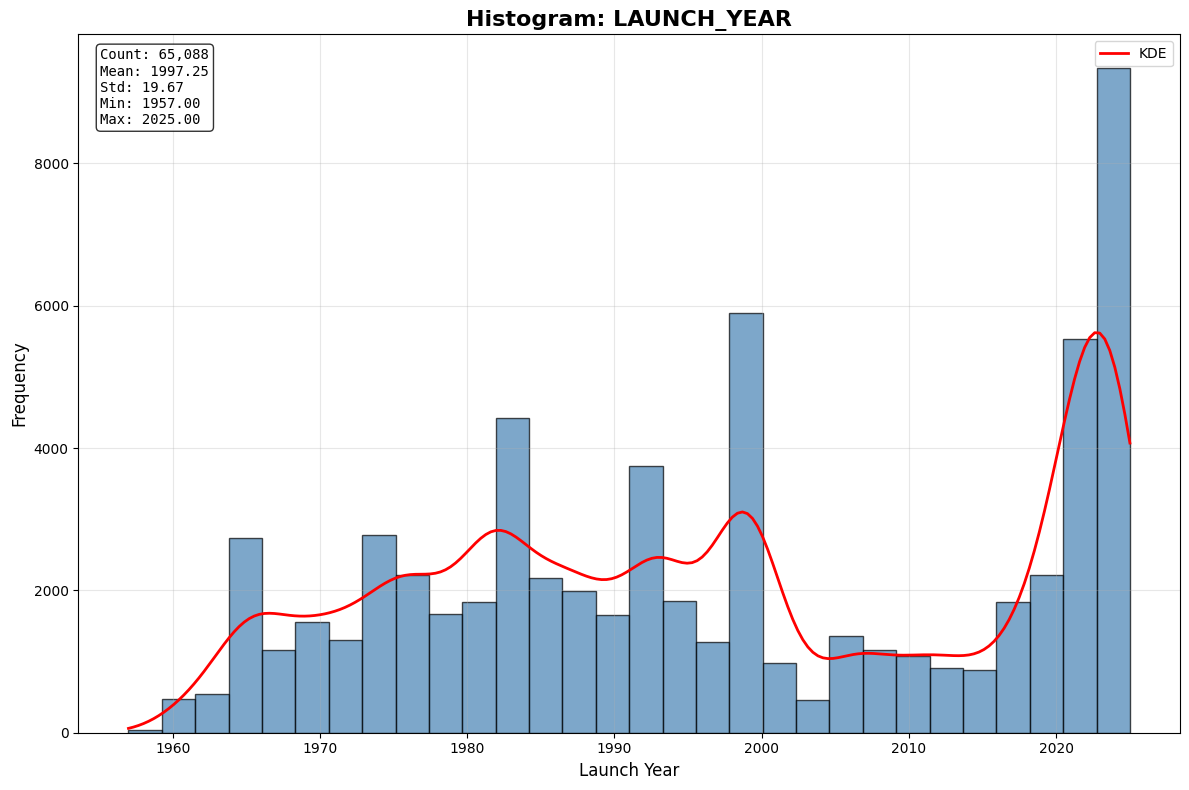

  Records: 65,088
  Mean: 1997.25
  Std: 19.67
  Min: 1957.00
  Max: 2025.00
  Missing values: 0

Processing column 2/15: LAUNCH_NUM


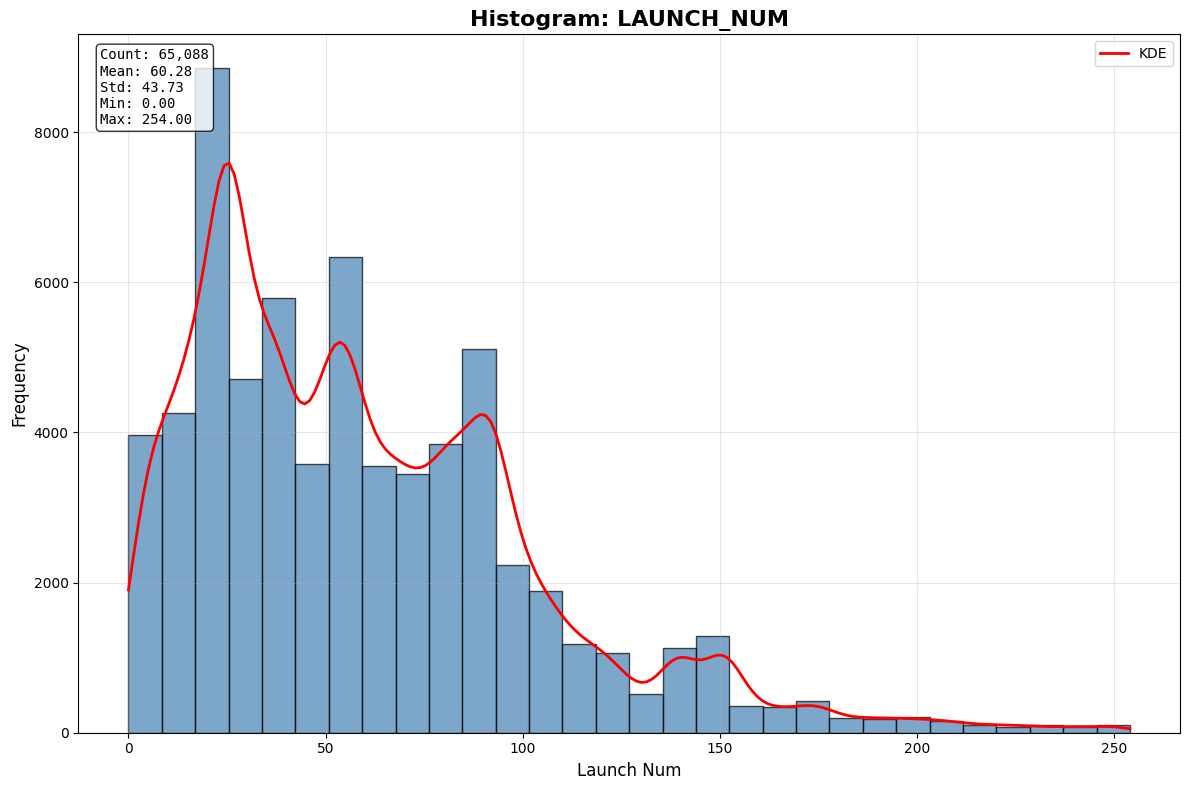

  Records: 65,088
  Mean: 60.28
  Std: 43.73
  Min: 0.00
  Max: 254.00
  Missing values: 0

Processing column 3/15: MEAN_MOTION


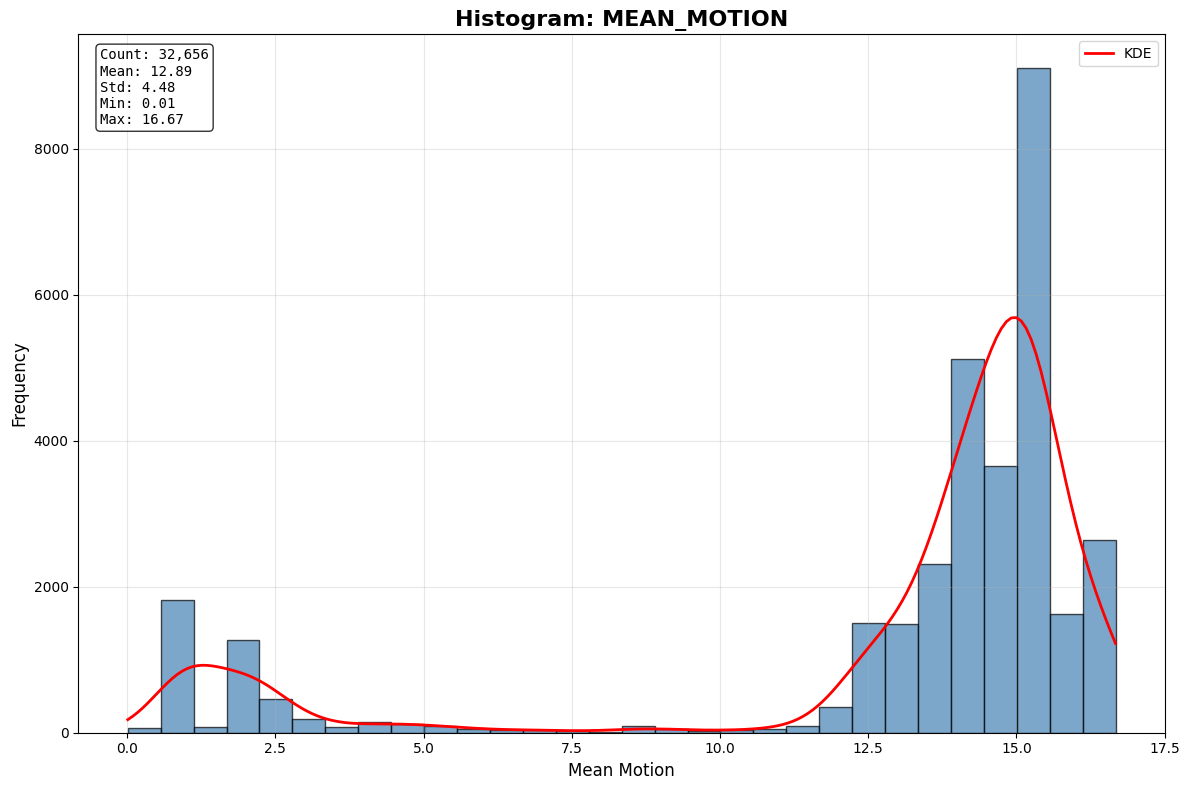

  Records: 32,656
  Mean: 12.89
  Std: 4.48
  Min: 0.01
  Max: 16.67
  Missing values: 32,432

Processing column 4/15: ECCENTRICITY


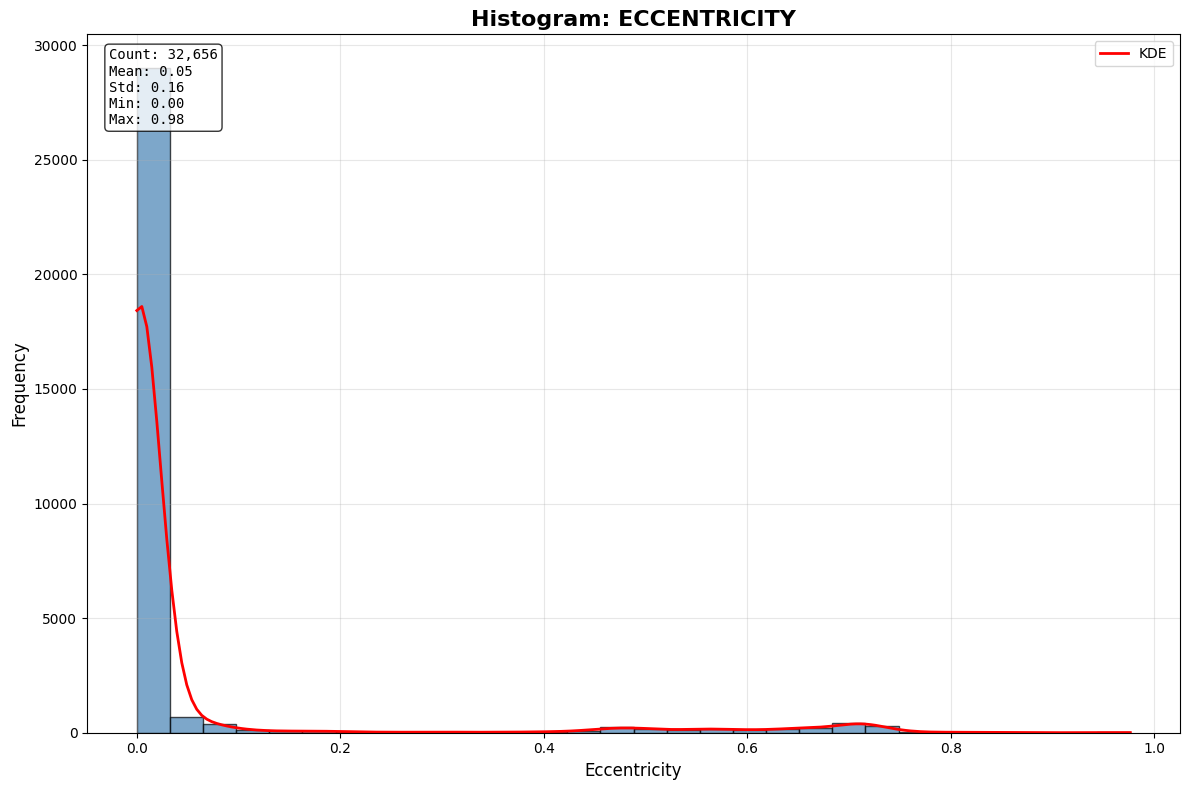

  Records: 32,656
  Mean: 0.05
  Std: 0.16
  Min: 0.00
  Max: 0.98
  Missing values: 32,432

Processing column 5/15: RA_OF_ASC_NODE


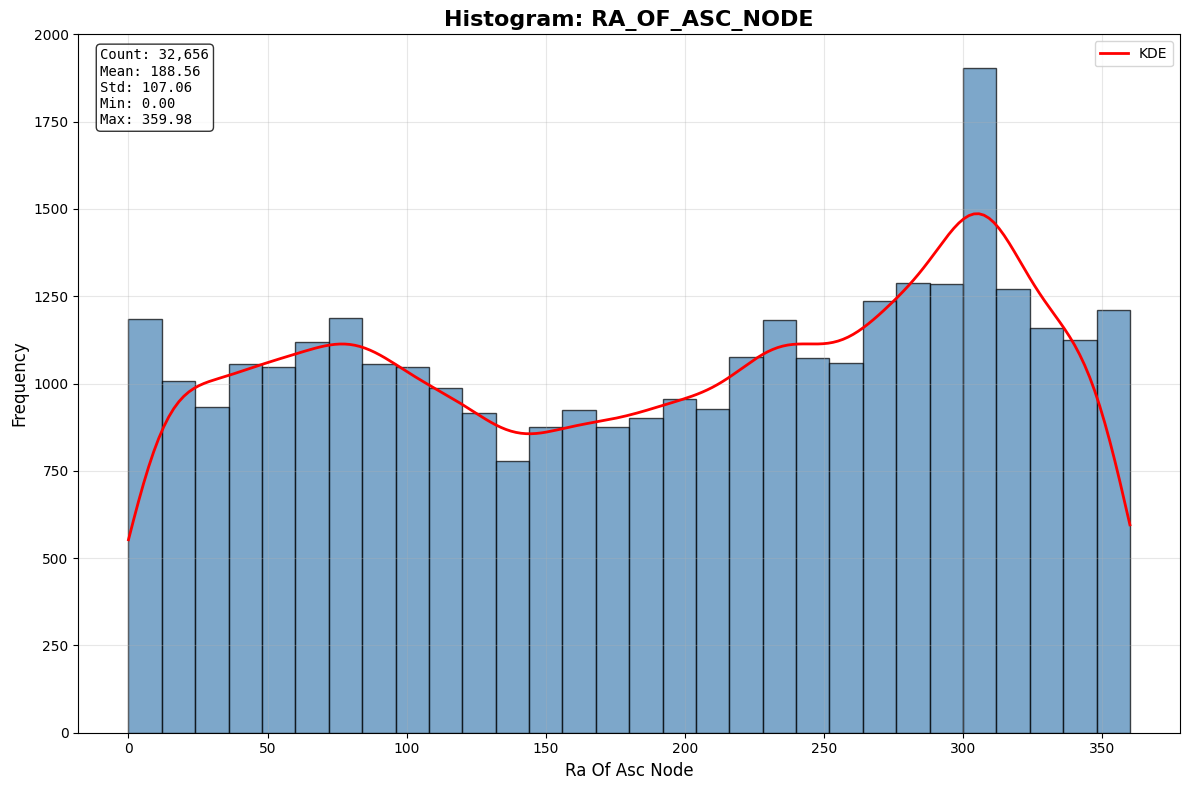

  Records: 32,656
  Mean: 188.56
  Std: 107.06
  Min: 0.00
  Max: 359.98
  Missing values: 32,432

Processing column 6/15: ARG_OF_PERICENTER


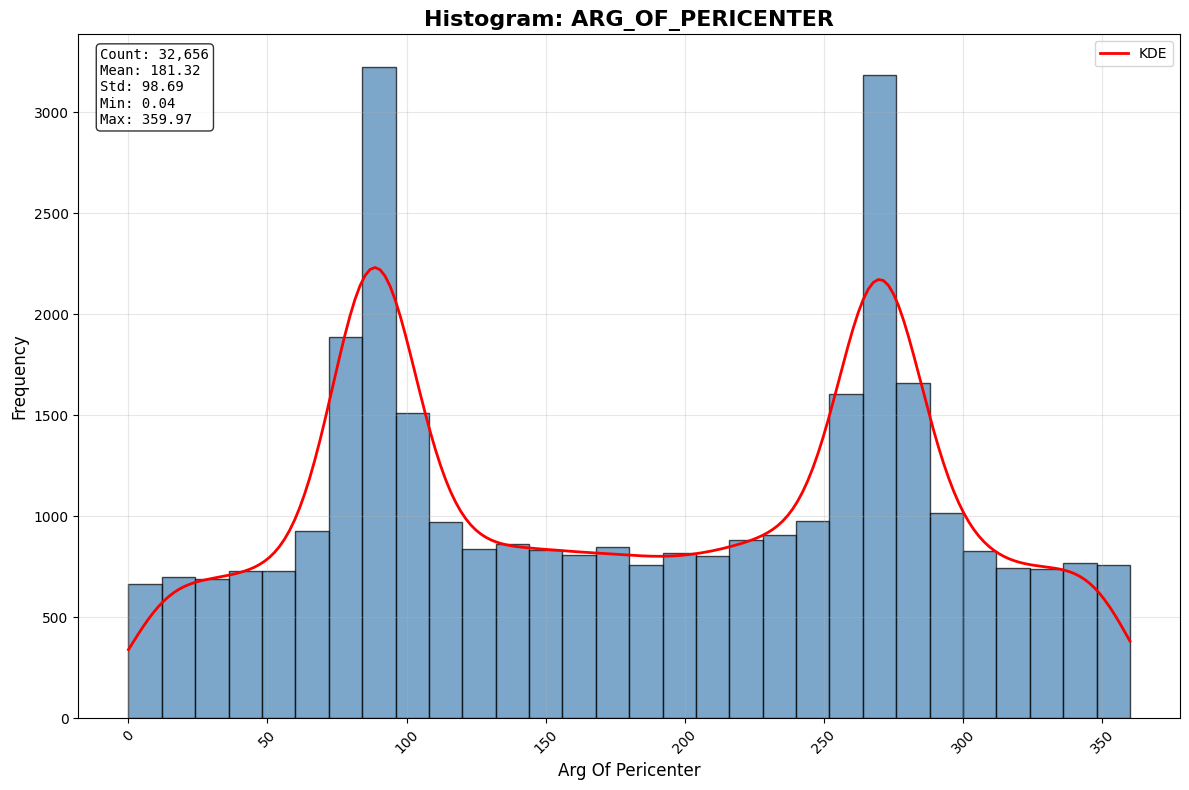

  Records: 32,656
  Mean: 181.32
  Std: 98.69
  Min: 0.04
  Max: 359.97
  Missing values: 32,432

Processing column 7/15: MEAN_ANOMALY


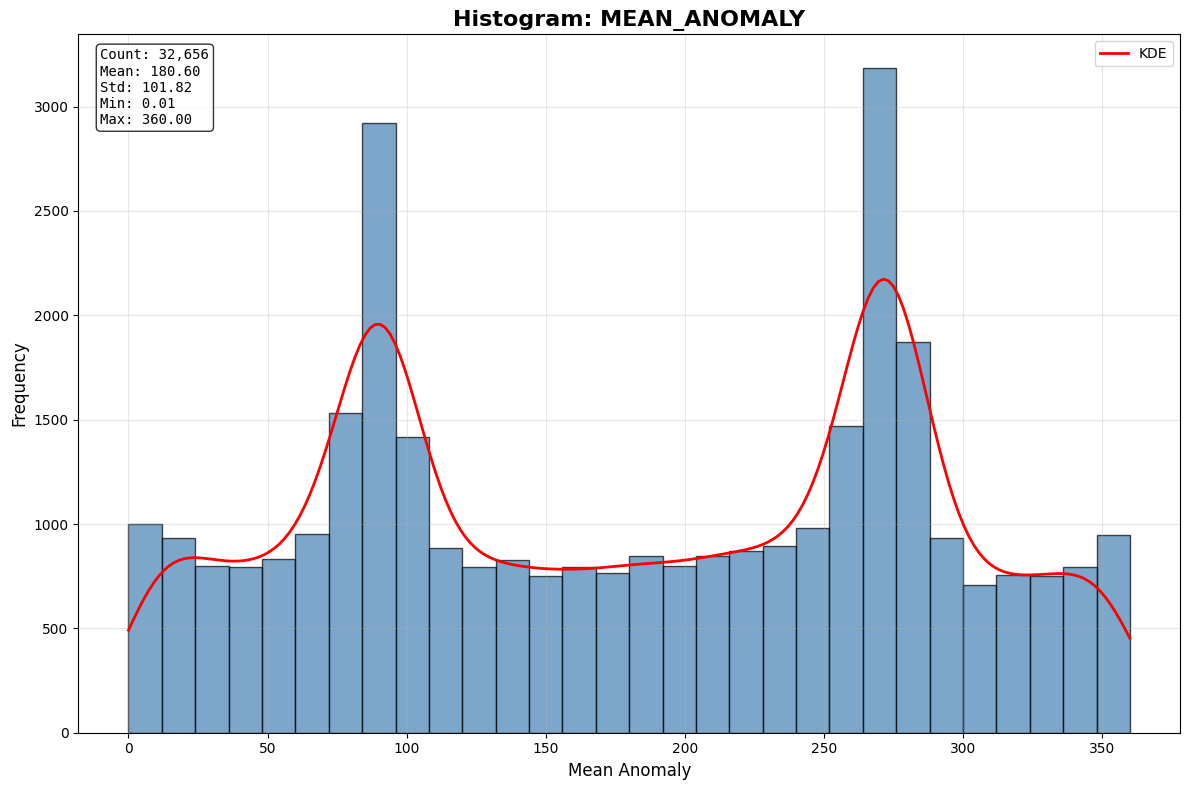

  Records: 32,656
  Mean: 180.60
  Std: 101.82
  Min: 0.01
  Max: 360.00
  Missing values: 32,432

Processing column 8/15: REV_AT_EPOCH


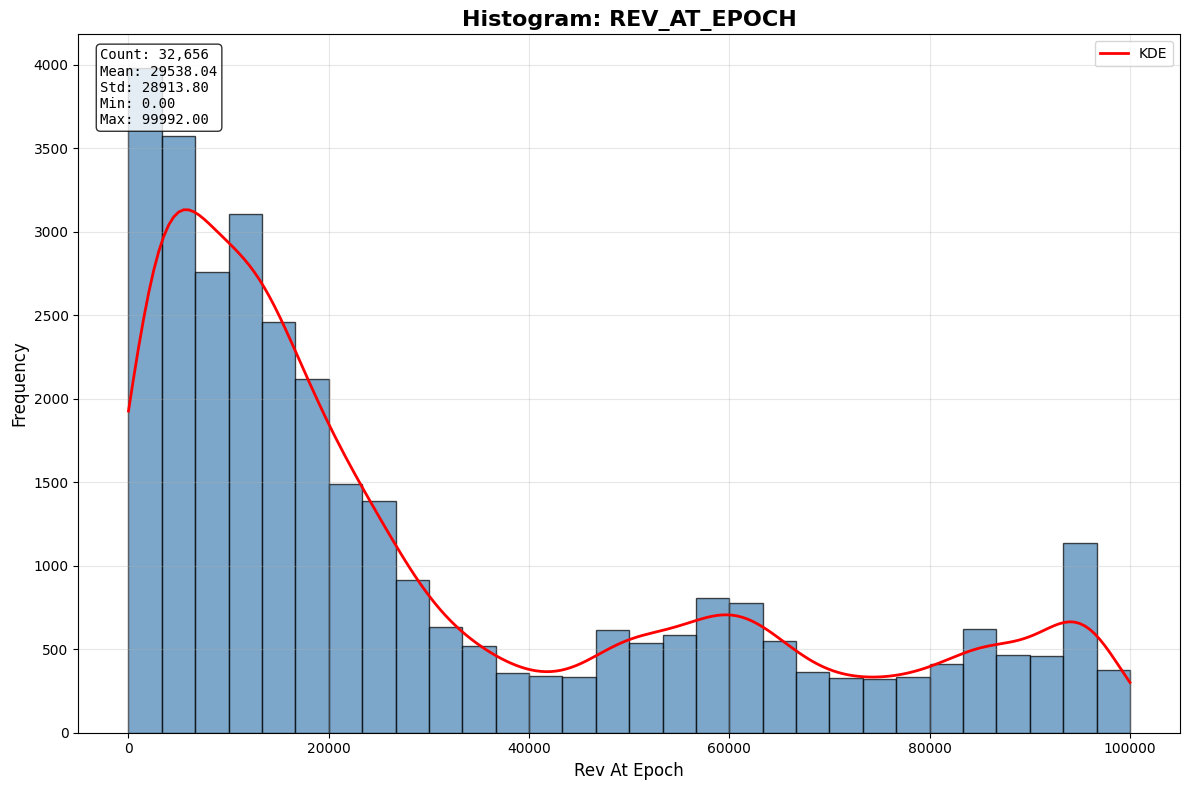

  Records: 32,656
  Mean: 29538.04
  Std: 28913.80
  Min: 0.00
  Max: 99992.00
  Missing values: 32,432

Processing column 9/15: BSTAR


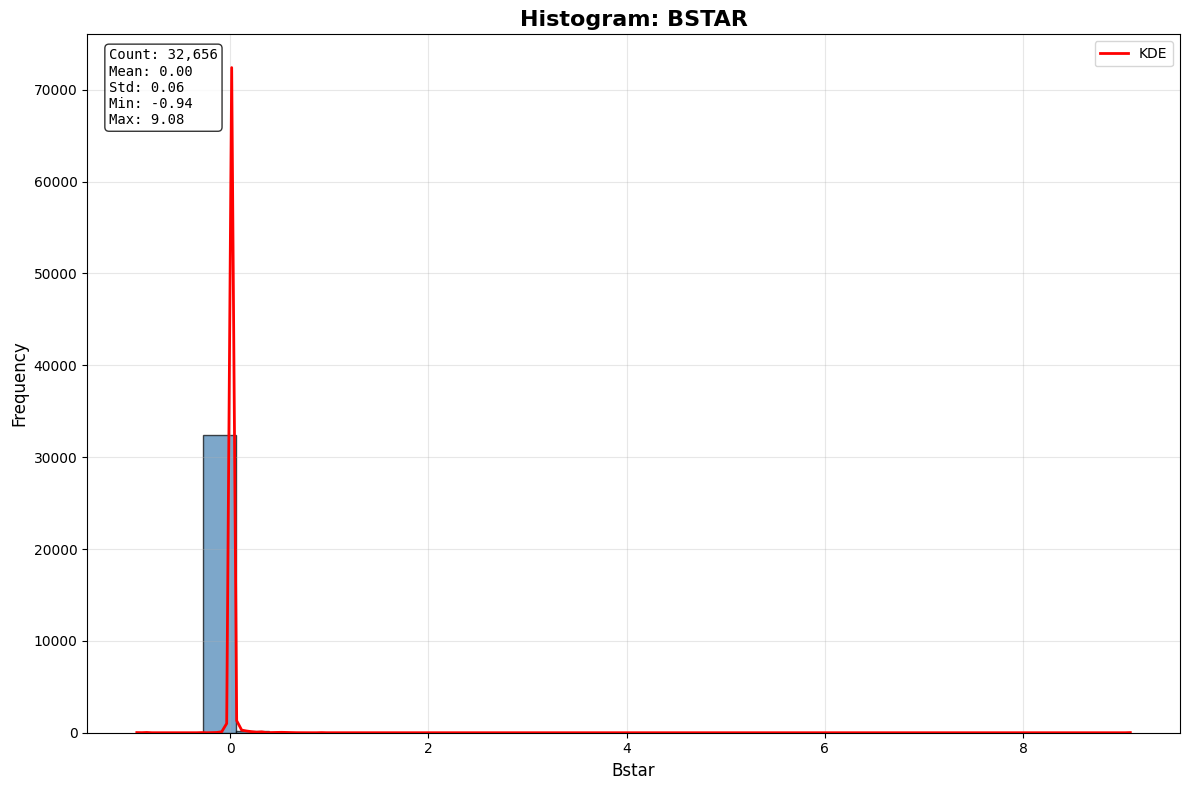

  Records: 32,656
  Mean: 0.00
  Std: 0.06
  Min: -0.94
  Max: 9.08
  Missing values: 32,432

Processing column 10/15: MEAN_MOTION_DOT


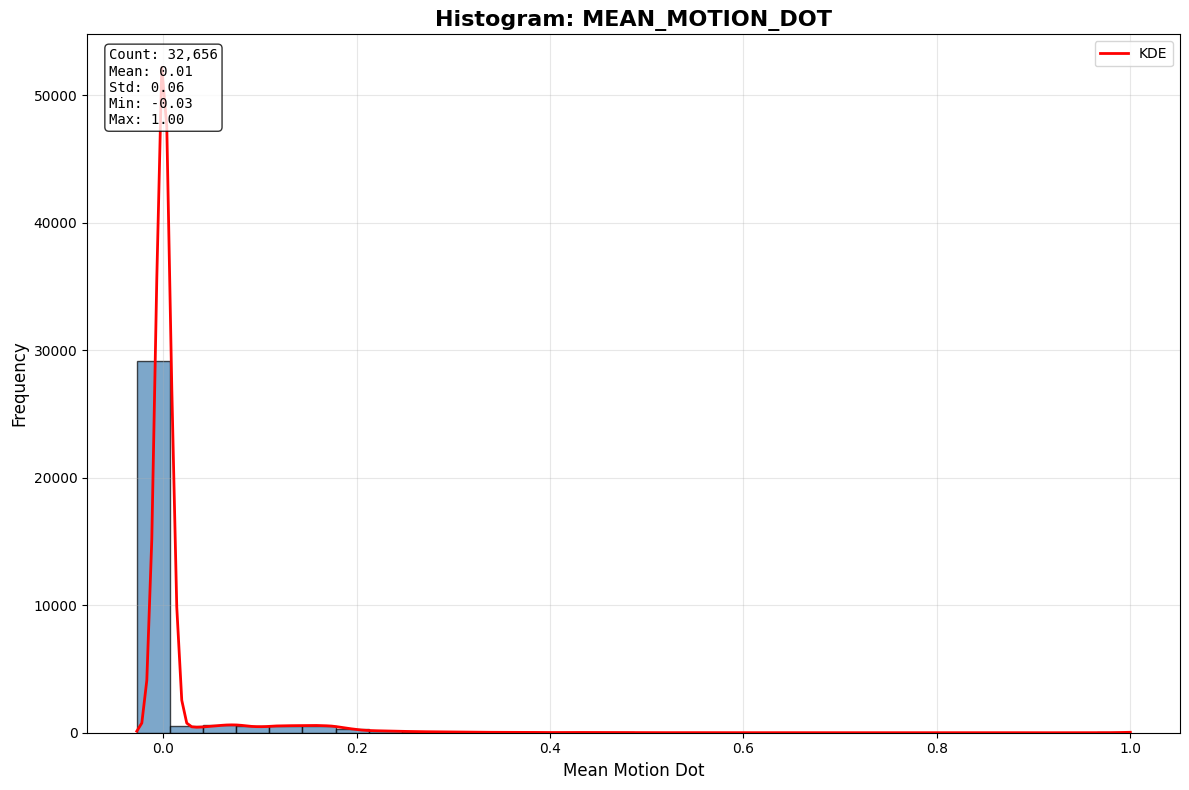

  Records: 32,656
  Mean: 0.01
  Std: 0.06
  Min: -0.03
  Max: 1.00
  Missing values: 32,432

Processing column 11/15: MEAN_MOTION_DDOT


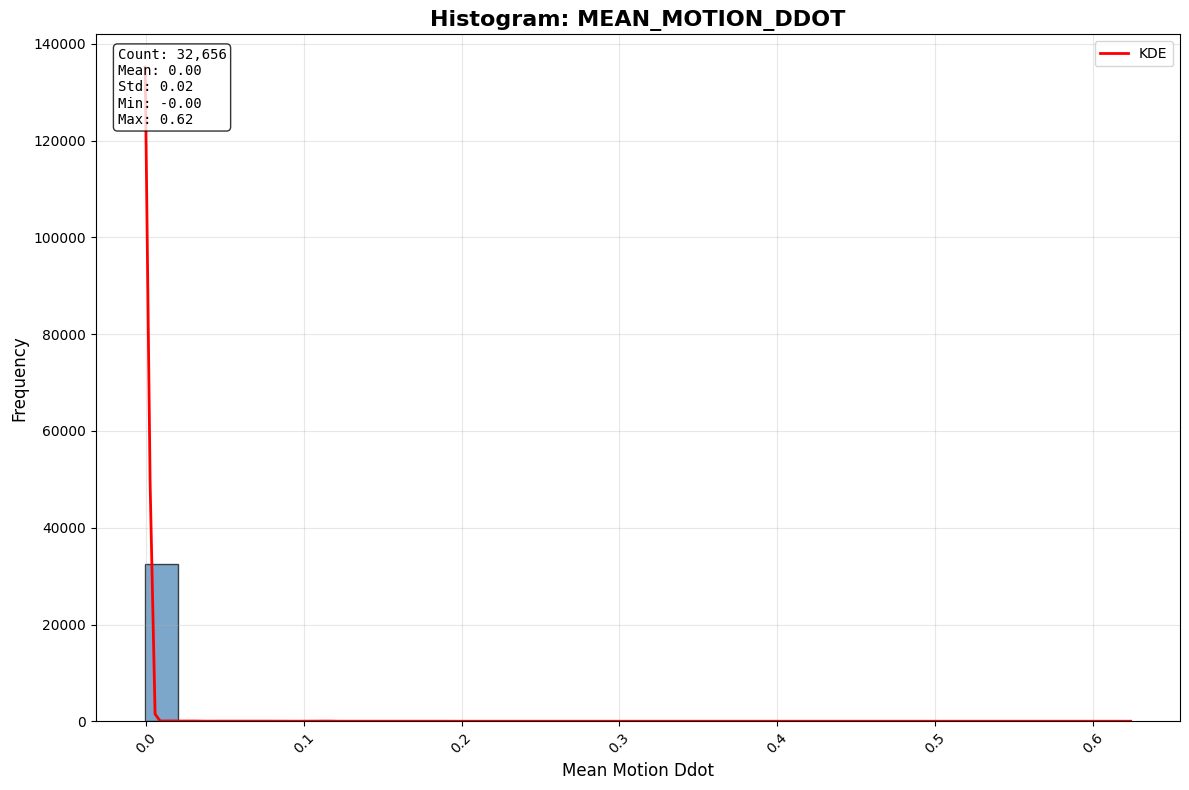

  Records: 32,656
  Mean: 0.00
  Std: 0.02
  Min: -0.00
  Max: 0.62
  Missing values: 32,432

Processing column 12/15: SEMIMAJOR_AXIS


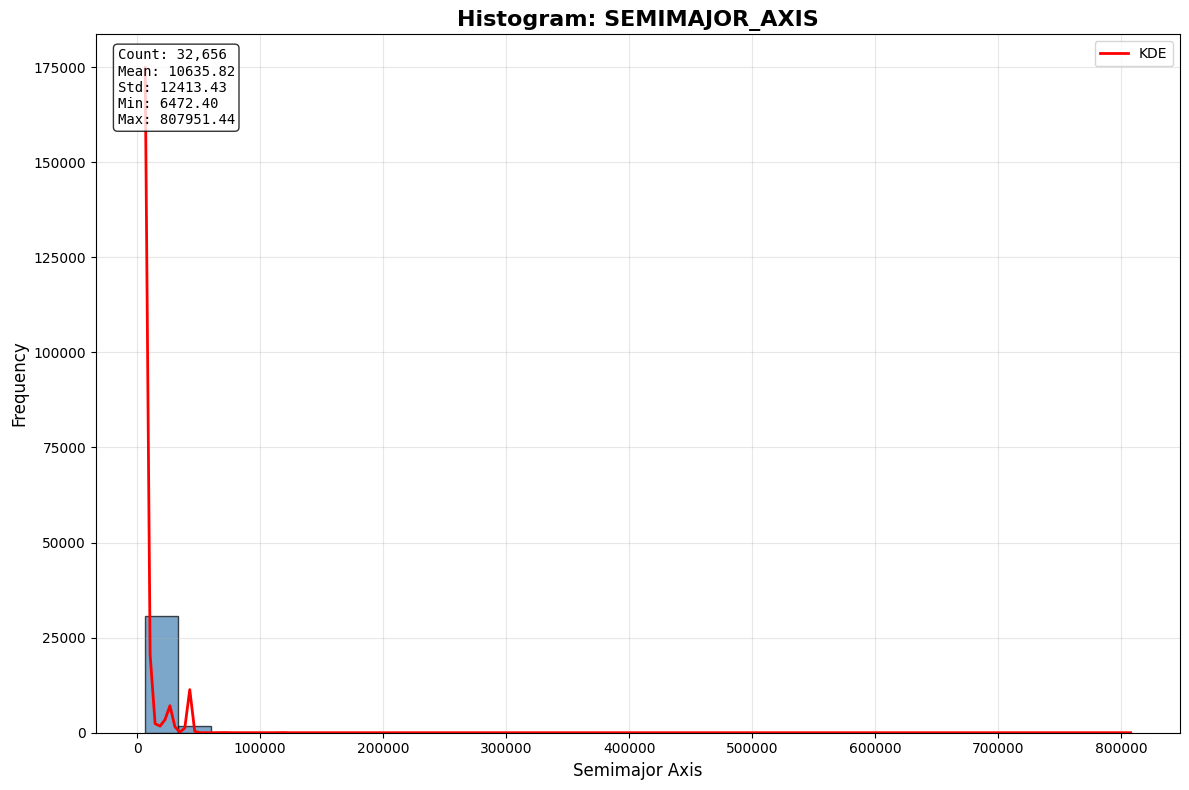

  Records: 32,656
  Mean: 10635.82
  Std: 12413.43
  Min: 6472.40
  Max: 807951.44
  Missing values: 32,432

Processing column 13/15: period


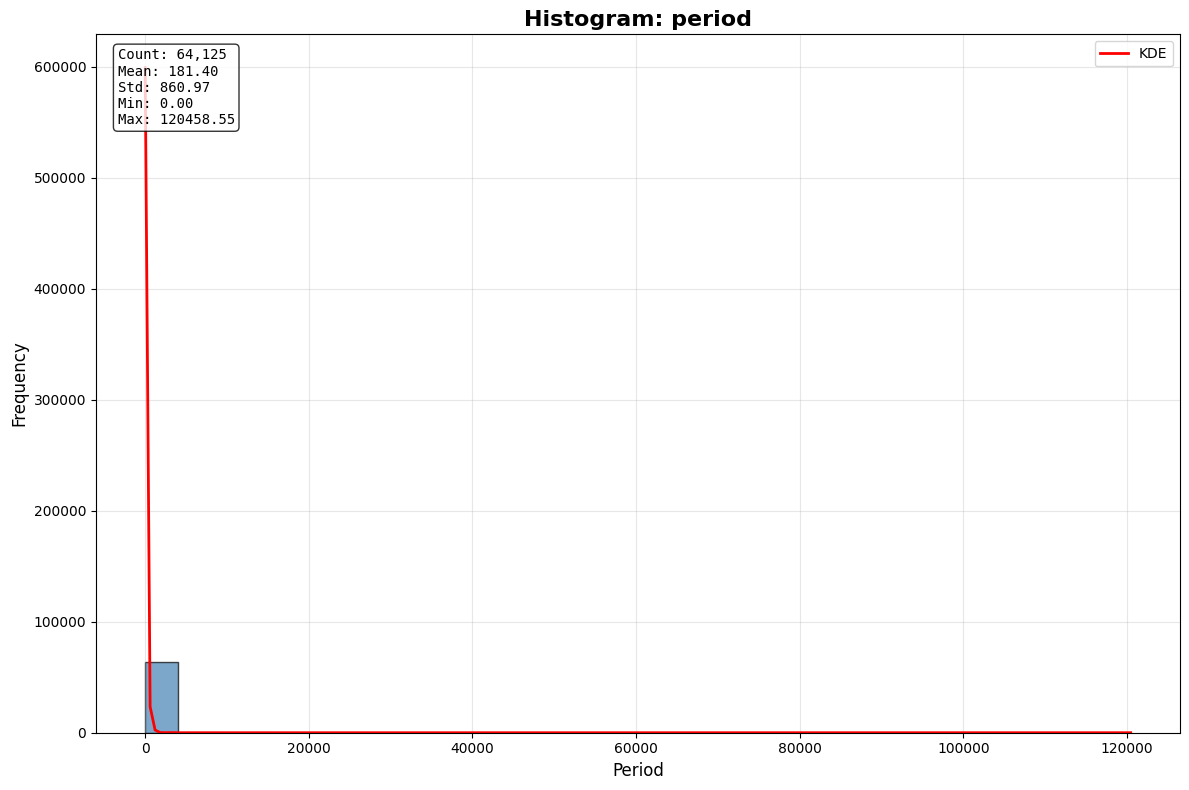

  Records: 64,125
  Mean: 181.40
  Std: 860.97
  Min: 0.00
  Max: 120458.55
  Missing values: 963

Processing column 14/15: inclination


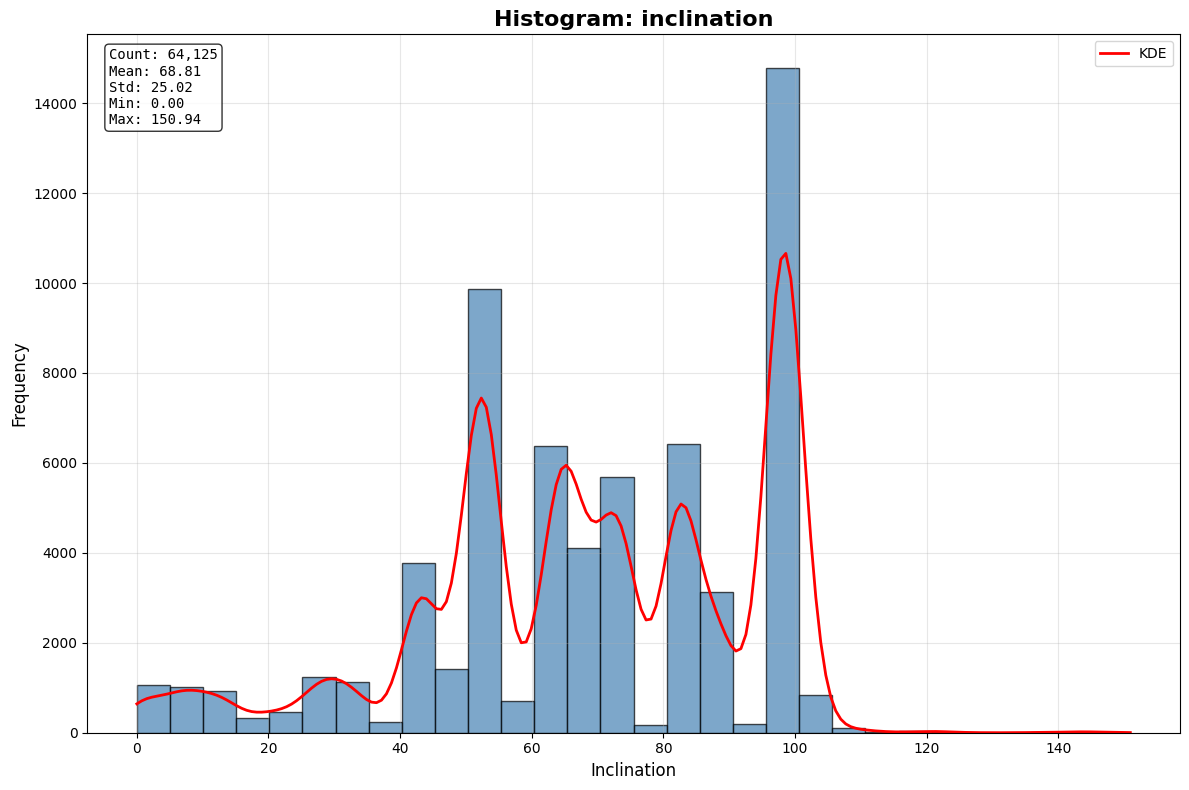

  Records: 64,125
  Mean: 68.81
  Std: 25.02
  Min: 0.00
  Max: 150.94
  Missing values: 963

Processing column 15/15: periapsis


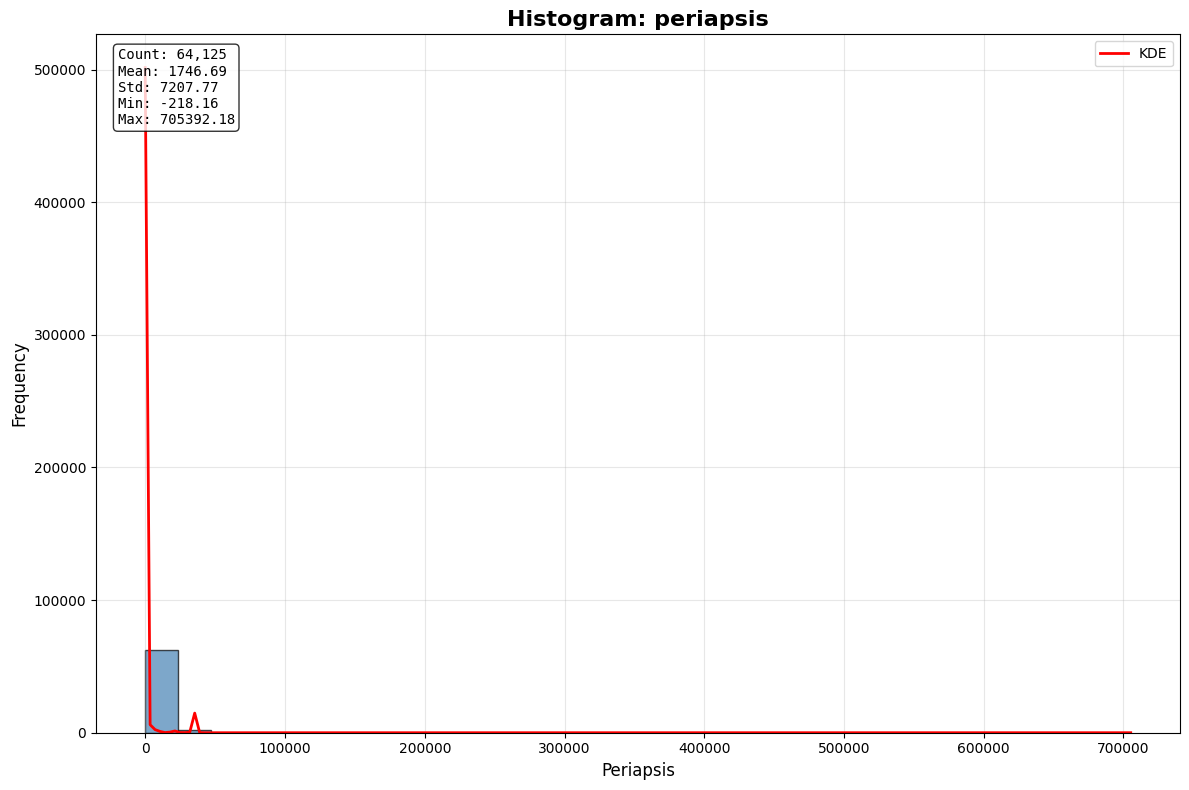

  Records: 64,125
  Mean: 1746.69
  Std: 7207.77
  Min: -218.16
  Max: 705392.18
  Missing values: 963

Completed! Created 15 histogram plots.
Each plot can be saved individually using the save button in your notebook.


In [30]:
# Inputs: satnav_tidy, list of columns | Process: create separate histograms | Outputs: individual histogram plots
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Editable settings ---
# columns_to_plot: List of columns to create histograms for
columns_to_plot = ['LAUNCH_YEAR', 'LAUNCH_NUM', 'MEAN_MOTION', 'ECCENTRICITY', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS', 'period', 'inclination', 'apapsis', 'periapsis']

# bins: Number of histogram bins
bins = 30

# figsize: Figure size for each histogram
figsize = (12, 8)

# color: Color for histogram bars
color = 'steelblue'

# edge_color: Color for bar edges
edge_color = 'black'

# alpha: Transparency of bars
alpha = 0.7

# log_scale: Whether to apply log scale to y-axis for skewed distributions
log_scale = False

# kde: Whether to overlay kernel density estimation curve
kde = True
# -------------------------

# Validate columns exist in DataFrame
valid_columns = [col for col in columns_to_plot if col in satnav_tidy.columns]
invalid_columns = [col for col in columns_to_plot if col not in satnav_tidy.columns]

if invalid_columns:
    print(f"Warning: The following columns were not found and will be skipped: {invalid_columns}")
    print(f"Available columns: {list(satnav_tidy.columns)}")

if not valid_columns:
    print("No valid columns found. Please check your column list.")
else:
    print(f"Creating histograms for {len(valid_columns)} columns: {valid_columns}")
    print("=" * 60)

# Create individual histograms for each column
for i, column in enumerate(valid_columns):
    print(f"\nProcessing column {i+1}/{len(valid_columns)}: {column}")
    
    # Get data for current column
    data = satnav_tidy[column].dropna()
    
    if len(data) == 0:
        print(f"  No data available for column '{column}'")
        continue
    
    # Convert to numeric if needed
    if data.dtype == 'object':
        data = pd.to_numeric(data, errors='coerce').dropna()
        if len(data) == 0:
            print(f"  Could not convert column '{column}' to numeric")
            continue
    
    # Create figure for this histogram
    plt.figure(figsize=figsize)
    
    # Create histogram
    plt.hist(data, bins=bins, color=color, edgecolor=edge_color, alpha=alpha, density=False)
    
    # Add KDE curve if requested
    if kde and len(data) > 1:
        from scipy.stats import gaussian_kde
        try:
            kde_curve = gaussian_kde(data.dropna())
            x_range = np.linspace(data.min(), data.max(), 200)
            kde_values = kde_curve(x_range) * len(data) * (data.max() - data.min()) / bins
            plt.plot(x_range, kde_values, 'r-', linewidth=2, label='KDE')
            plt.legend()
        except:
            print(f"  Could not compute KDE for column '{column}'")
    
    # Customize plot
    plt.title(f'Histogram: {column}', fontsize=16, fontweight='bold')
    plt.xlabel(column.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Apply log scale if requested
    if log_scale and data.max() > 0:
        plt.yscale('log')
        plt.ylabel('Frequency (Log Scale)', fontsize=12)
    
    # Add statistics text box
    stats_text = f'Count: {len(data):,}\nMean: {data.mean():.2f}\nStd: {data.std():.2f}\nMin: {data.min():.2f}\nMax: {data.max():.2f}'
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             fontsize=10, fontfamily='monospace')
    
    # Rotate x-axis labels if they're long
    if len(column) > 15:
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"  Records: {len(data):,}")
    print(f"  Mean: {data.mean():.2f}")
    print(f"  Std: {data.std():.2f}")
    print(f"  Min: {data.min():.2f}")
    print(f"  Max: {data.max():.2f}")
    print(f"  Missing values: {satnav_tidy[column].isna().sum():,}")

print(f"\n{'='*60}")
print(f"Completed! Created {len(valid_columns)} histogram plots.")
print("Each plot can be saved individually using the save button in your notebook.")


Processing column 1/15: LAUNCH_YEAR


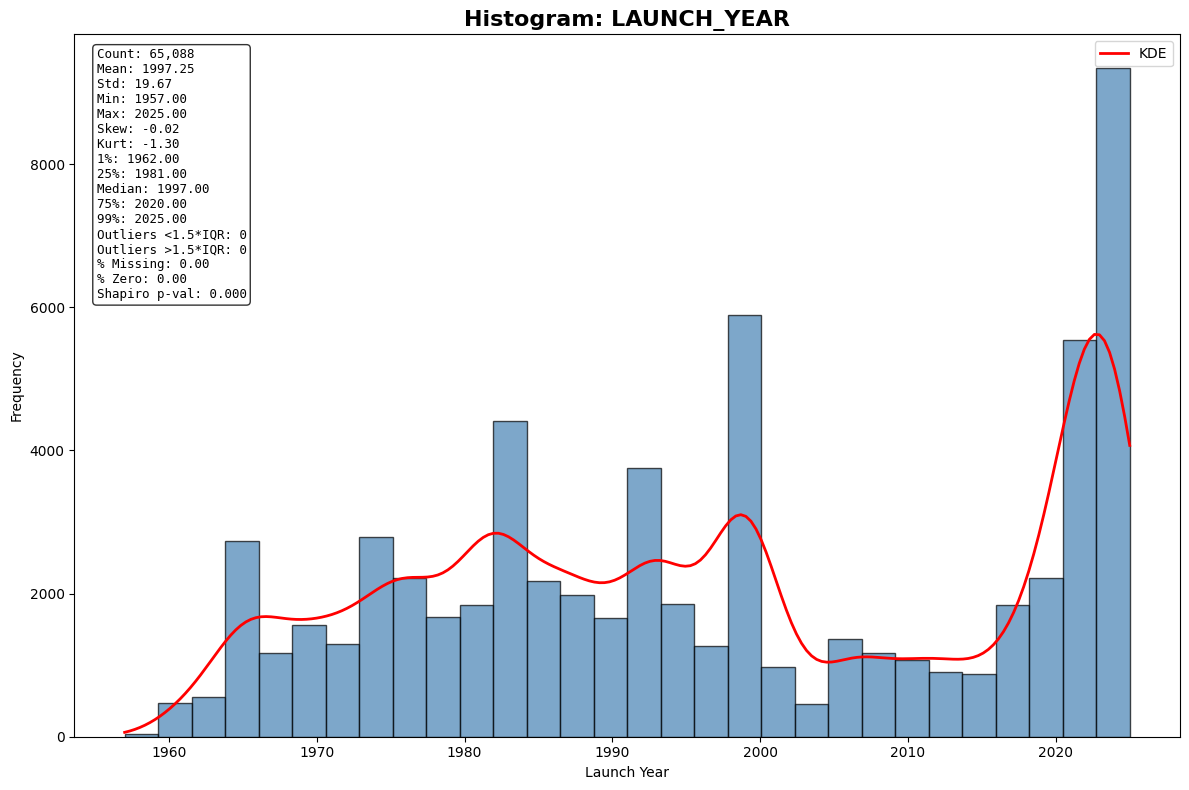

  Mean=1997.25, Std=19.67, Min=1957.00, Max=2025.00
  Skew=-0.02, Kurtosis=-1.30
  Percentiles: 1%=1962.00, 25%=1981.00, Median=1997.00, 75%=2020.00, 99%=2025.00
  Outliers (low=0, high=0) based on 1.5*IQR
  % Missing=0.00, % Zeros=0.00
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)

Processing column 2/15: LAUNCH_NUM


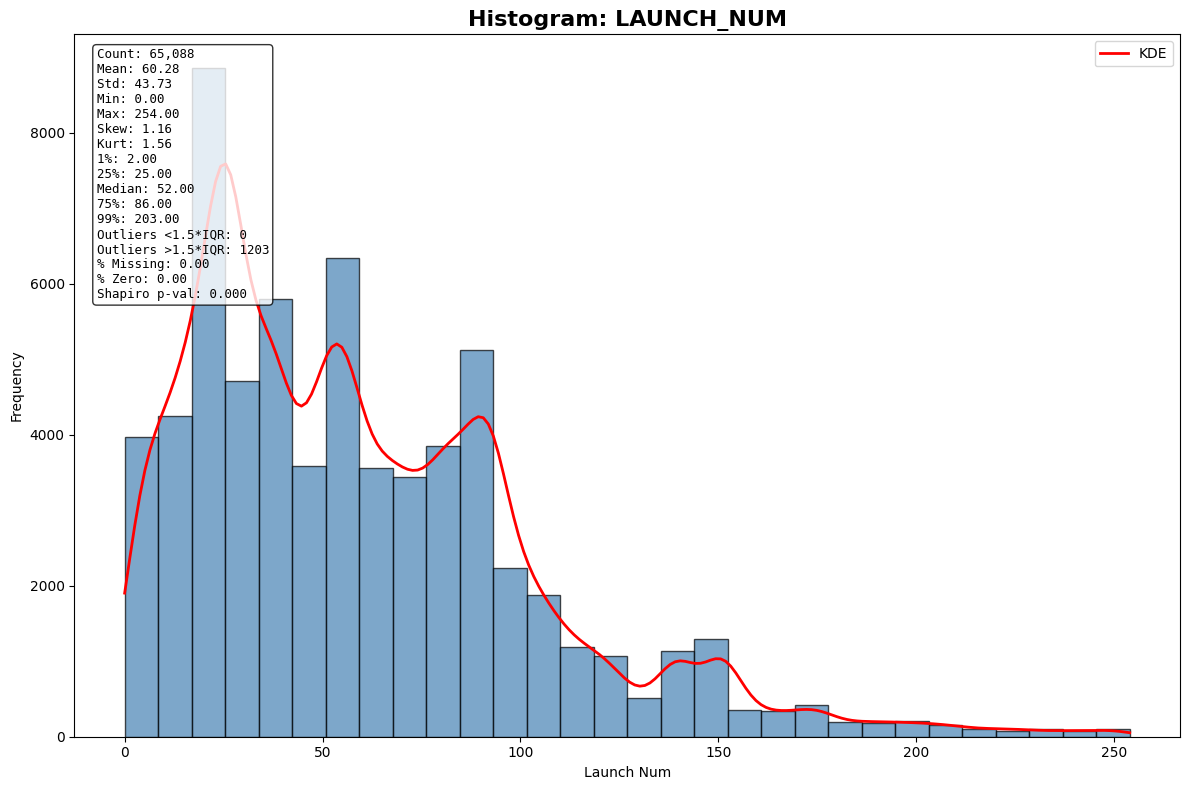

  Mean=60.28, Std=43.73, Min=0.00, Max=254.00
  Skew=1.16, Kurtosis=1.56
  Percentiles: 1%=2.00, 25%=25.00, Median=52.00, 75%=86.00, 99%=203.00
  Outliers (low=0, high=1203) based on 1.5*IQR
  % Missing=0.00, % Zeros=0.00
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)

Processing column 3/15: MEAN_MOTION


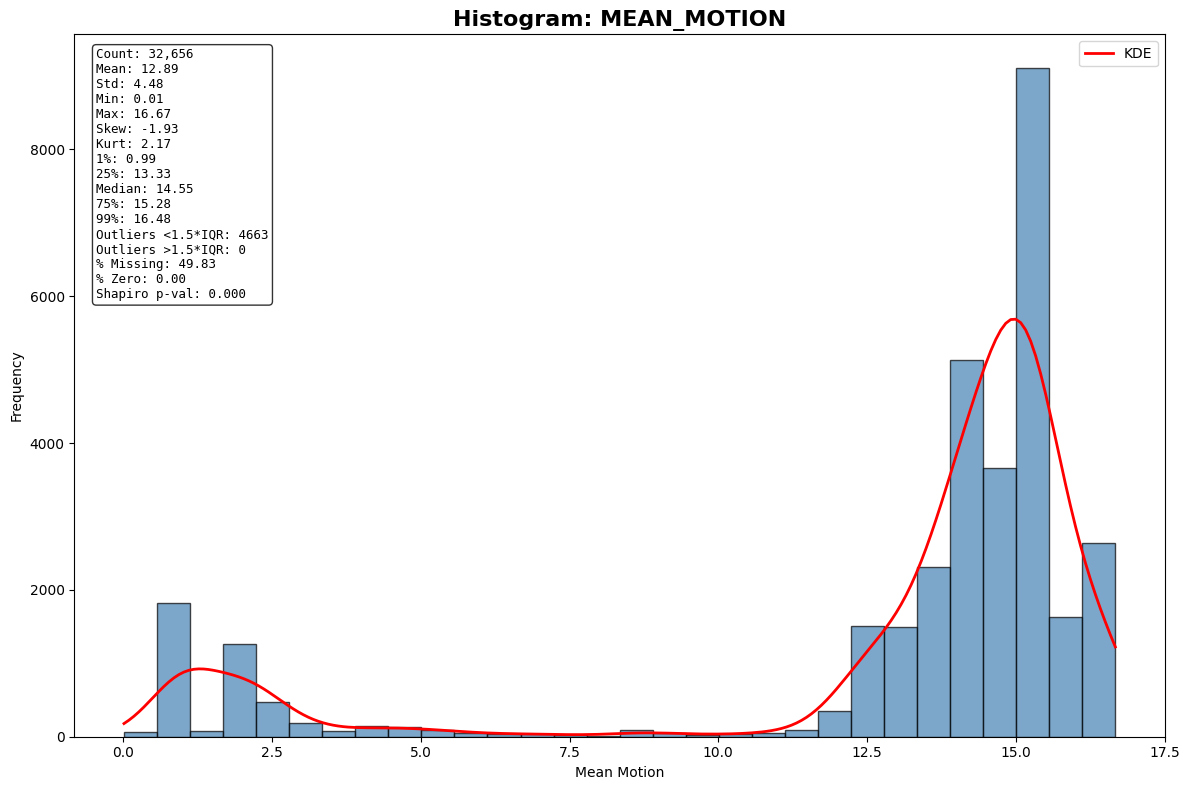

  Mean=12.89, Std=4.48, Min=0.01, Max=16.67
  Skew=-1.93, Kurtosis=2.17
  Percentiles: 1%=0.99, 25%=13.33, Median=14.55, 75%=15.28, 99%=16.48
  Outliers (low=4663, high=0) based on 1.5*IQR
  % Missing=49.83, % Zeros=0.00
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: derive altitude bands (LEO/MEO/GEO).

Processing column 4/15: ECCENTRICITY


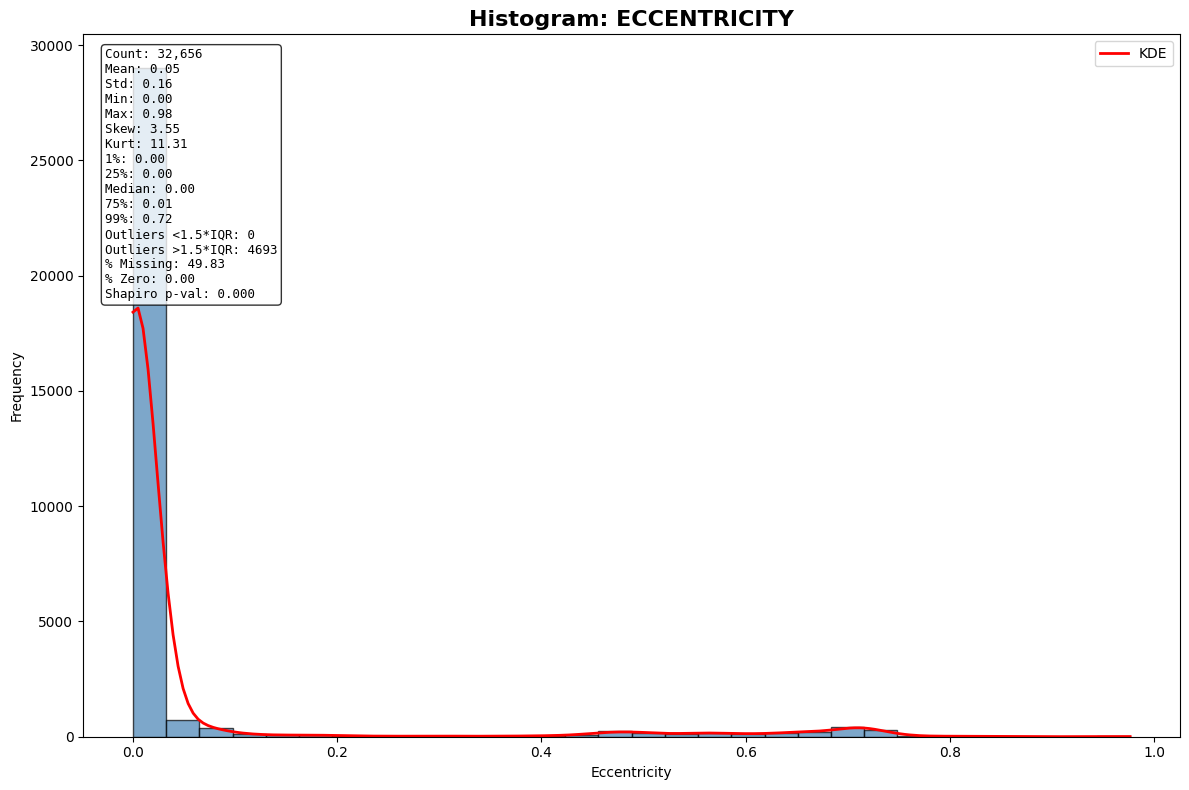

  Mean=0.05, Std=0.16, Min=0.00, Max=0.98
  Skew=3.55, Kurtosis=11.31
  Percentiles: 1%=0.00, 25%=0.00, Median=0.00, 75%=0.01, 99%=0.72
  Outliers (low=0, high=4693) based on 1.5*IQR
  % Missing=49.83, % Zeros=0.00
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: circular vs elliptical orbit buckets.

Processing column 5/15: RA_OF_ASC_NODE


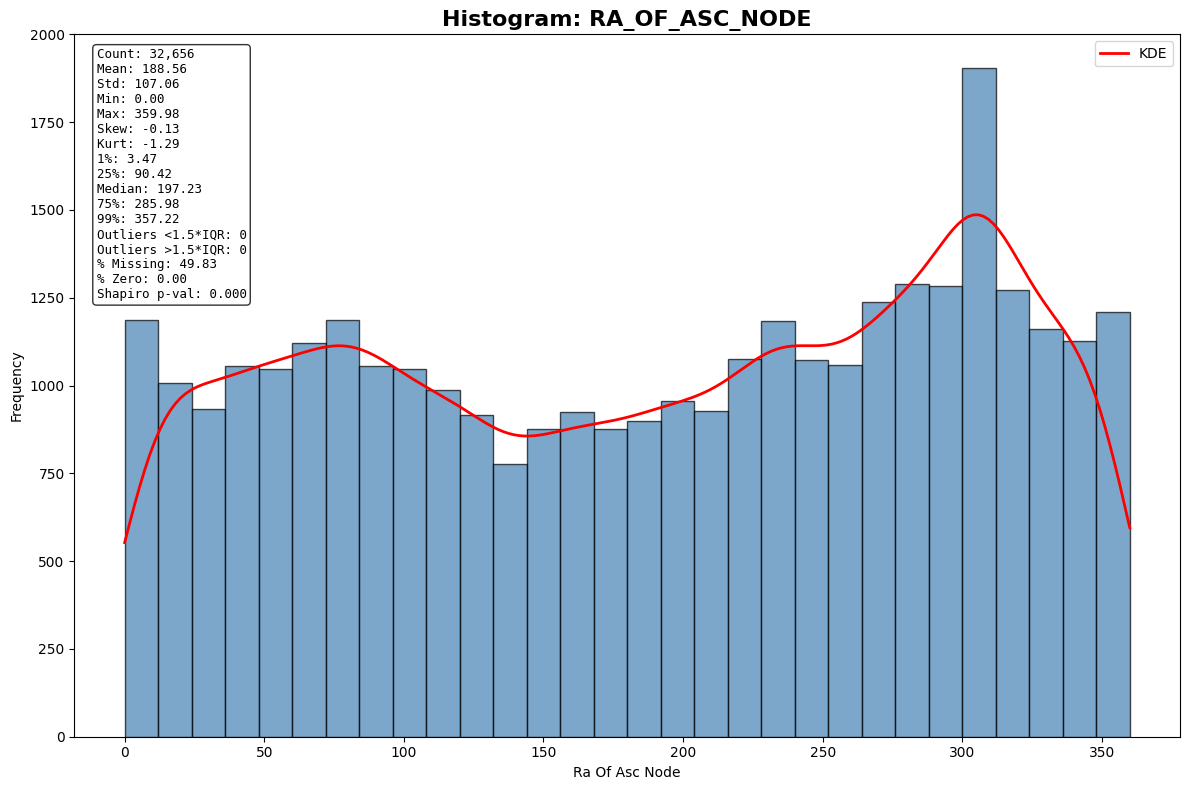

  Mean=188.56, Std=107.06, Min=0.00, Max=359.98
  Skew=-0.13, Kurtosis=-1.29
  Percentiles: 1%=3.47, 25%=90.42, Median=197.23, 75%=285.98, 99%=357.22
  Outliers (low=0, high=0) based on 1.5*IQR
  % Missing=49.83, % Zeros=0.00
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)

Processing column 6/15: ARG_OF_PERICENTER


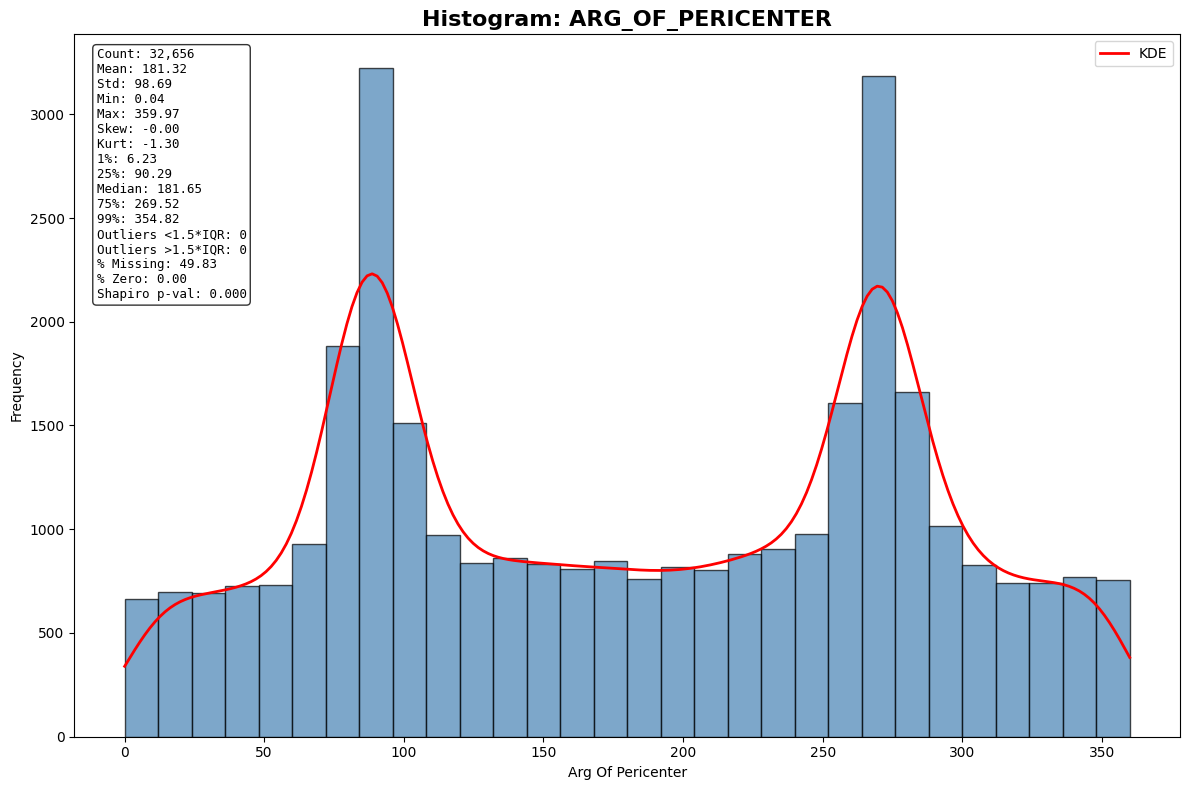

  Mean=181.32, Std=98.69, Min=0.04, Max=359.97
  Skew=-0.00, Kurtosis=-1.30
  Percentiles: 1%=6.23, 25%=90.29, Median=181.65, 75%=269.52, 99%=354.82
  Outliers (low=0, high=0) based on 1.5*IQR
  % Missing=49.83, % Zeros=0.00
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: sin/cos transform to handle cyclic nature.

Processing column 7/15: MEAN_ANOMALY


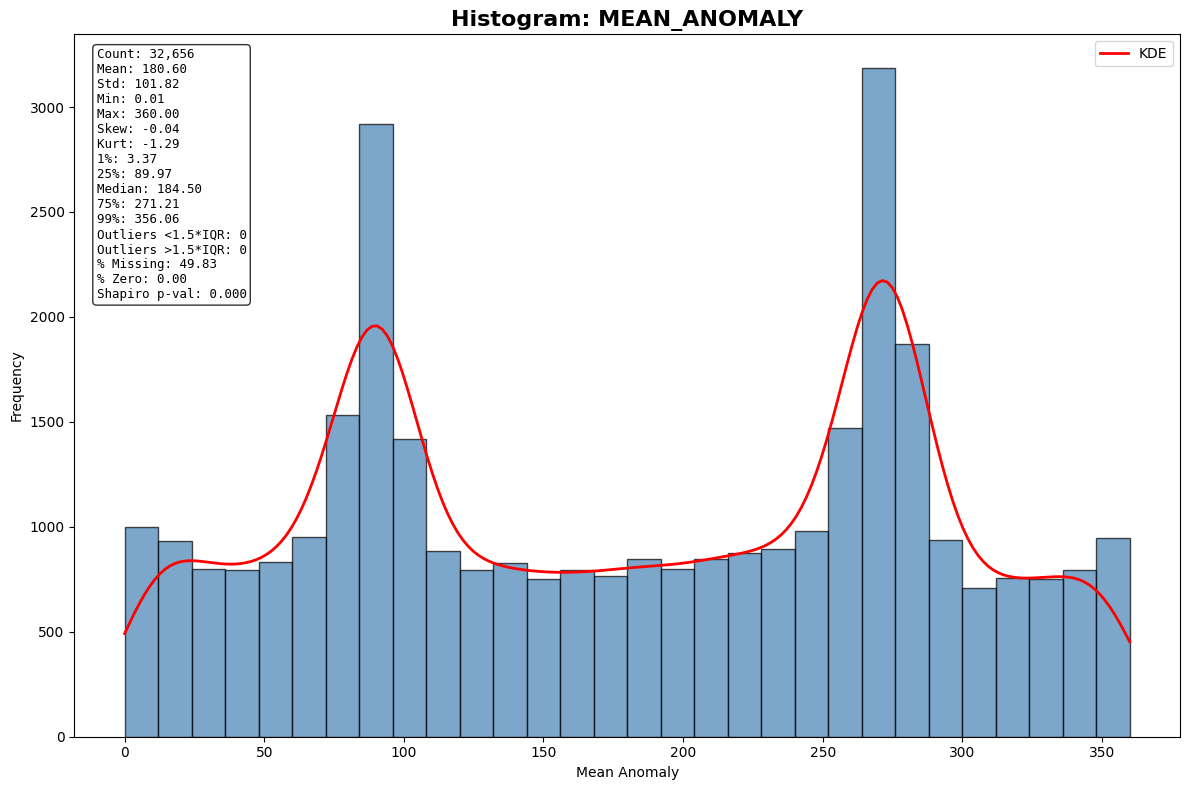

  Mean=180.60, Std=101.82, Min=0.01, Max=360.00
  Skew=-0.04, Kurtosis=-1.29
  Percentiles: 1%=3.37, 25%=89.97, Median=184.50, 75%=271.21, 99%=356.06
  Outliers (low=0, high=0) based on 1.5*IQR
  % Missing=49.83, % Zeros=0.00
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: sin/cos transform to handle cyclic nature.

Processing column 8/15: REV_AT_EPOCH


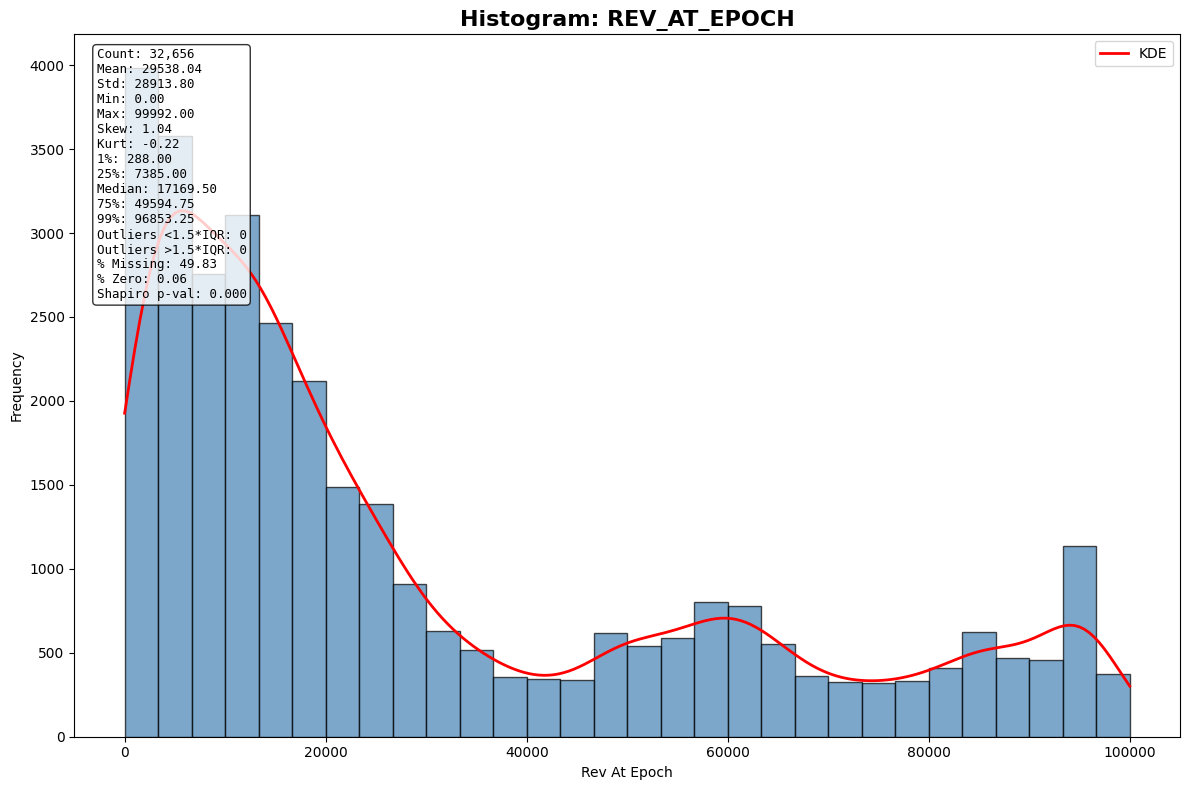

  Mean=29538.04, Std=28913.80, Min=0.00, Max=99992.00
  Skew=1.04, Kurtosis=-0.22
  Percentiles: 1%=288.00, 25%=7385.00, Median=17169.50, 75%=49594.75, 99%=96853.25
  Outliers (low=0, high=0) based on 1.5*IQR
  % Missing=49.83, % Zeros=0.06
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: approximate mission age (revs / mean_motion).

Processing column 9/15: BSTAR


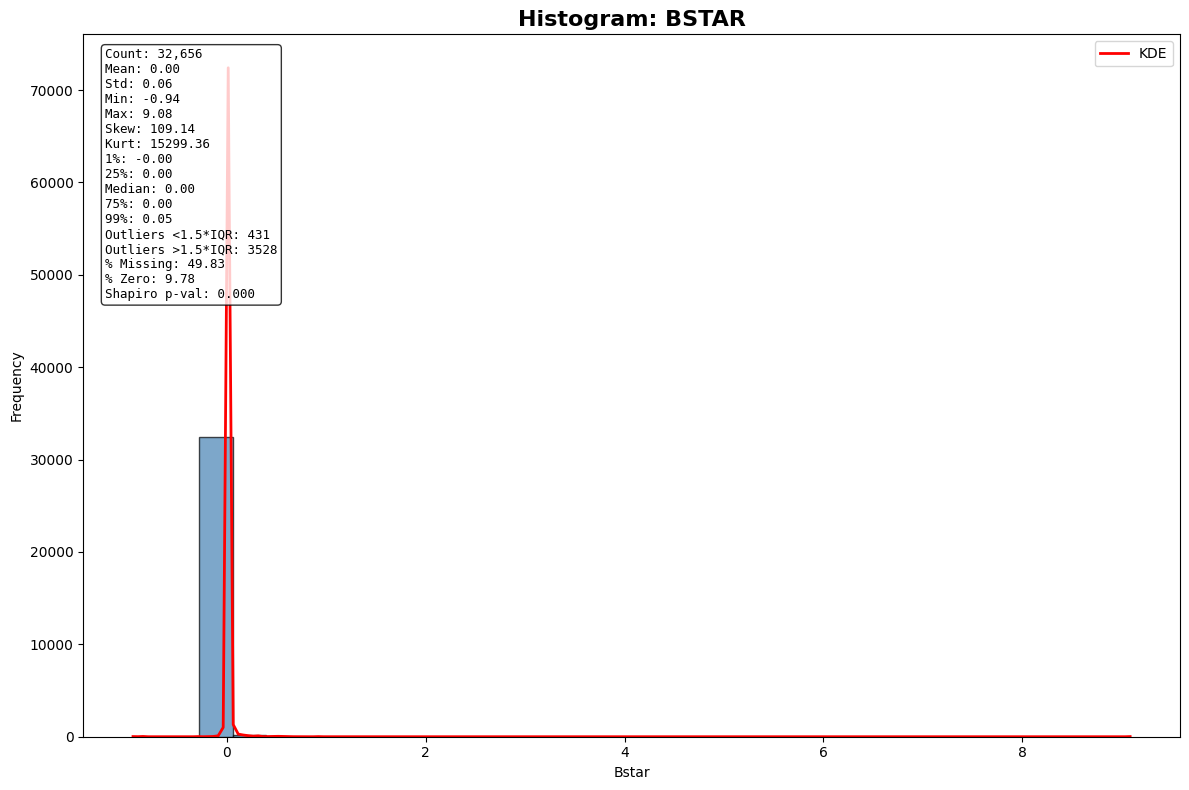

  Mean=0.00, Std=0.06, Min=-0.94, Max=9.08
  Skew=109.14, Kurtosis=15299.36
  Percentiles: 1%=-0.00, 25%=0.00, Median=0.00, 75%=0.00, 99%=0.05
  Outliers (low=431, high=3528) based on 1.5*IQR
  % Missing=49.83, % Zeros=9.78
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: drag/lifetime proxy.

Processing column 10/15: MEAN_MOTION_DOT


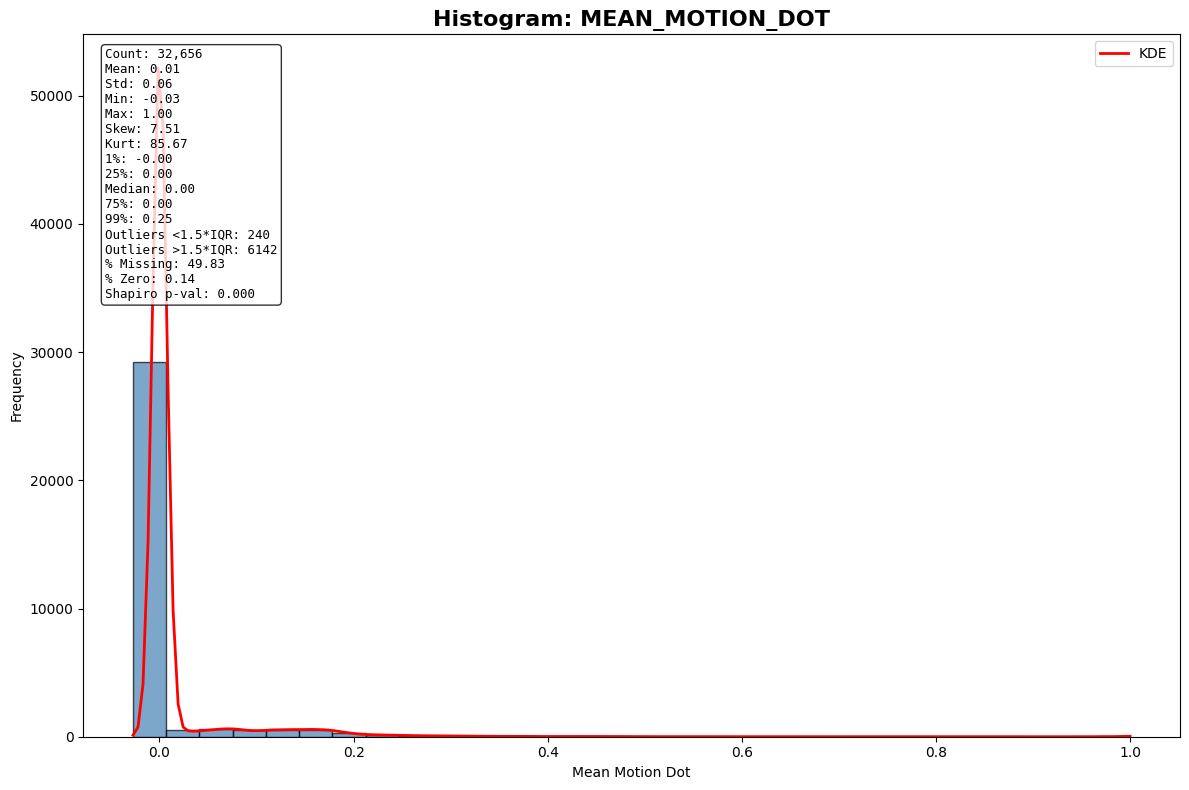

  Mean=0.01, Std=0.06, Min=-0.03, Max=1.00
  Skew=7.51, Kurtosis=85.67
  Percentiles: 1%=-0.00, 25%=0.00, Median=0.00, 75%=0.00, 99%=0.25
  Outliers (low=240, high=6142) based on 1.5*IQR
  % Missing=49.83, % Zeros=0.14
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: derive altitude bands (LEO/MEO/GEO).

Processing column 11/15: MEAN_MOTION_DDOT


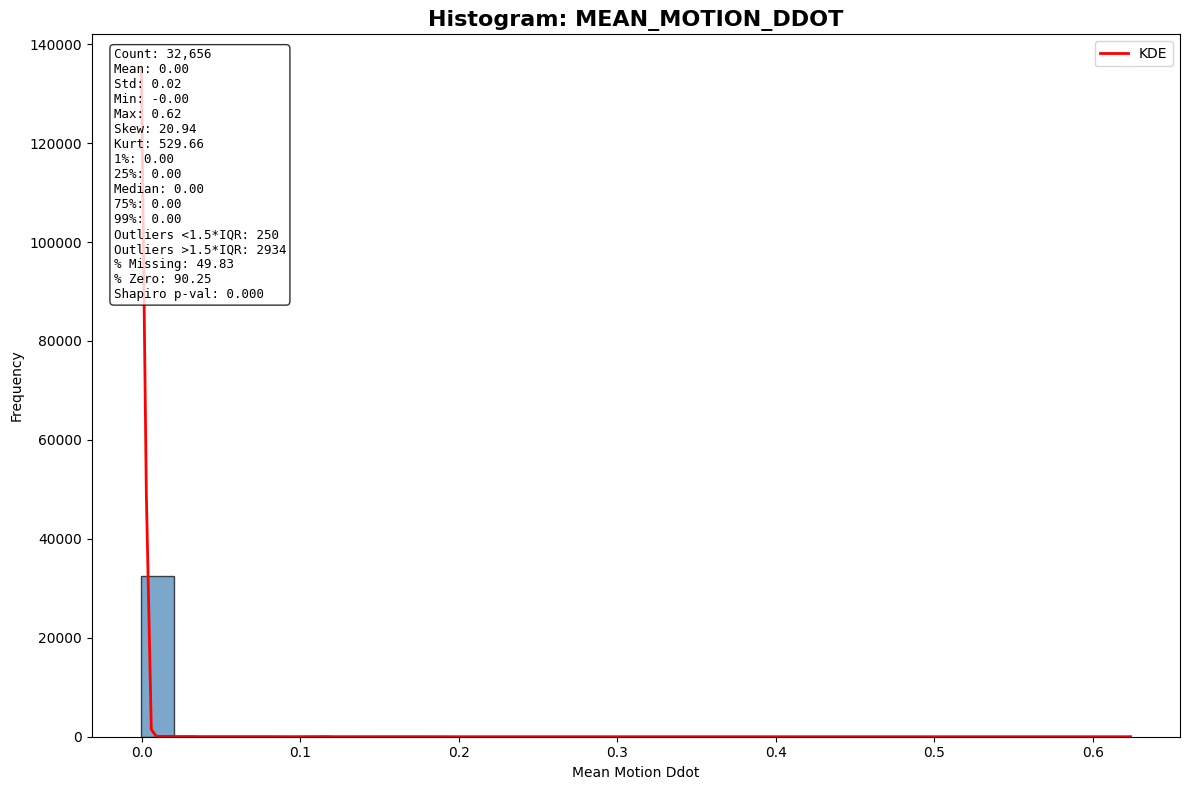

  Mean=0.00, Std=0.02, Min=-0.00, Max=0.62
  Skew=20.94, Kurtosis=529.66
  Percentiles: 1%=0.00, 25%=0.00, Median=0.00, 75%=0.00, 99%=0.00
  Outliers (low=250, high=2934) based on 1.5*IQR
  % Missing=49.83, % Zeros=90.25
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: derive altitude bands (LEO/MEO/GEO).

Processing column 12/15: SEMIMAJOR_AXIS


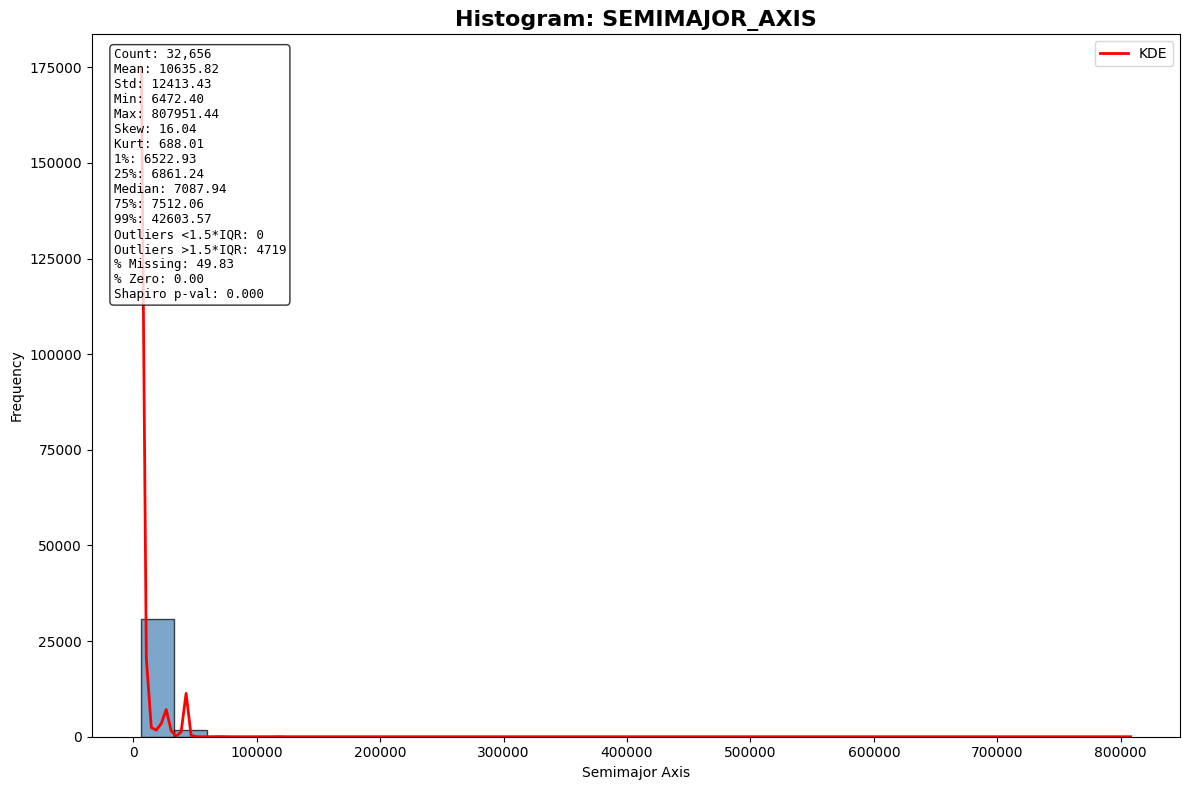

  Mean=10635.82, Std=12413.43, Min=6472.40, Max=807951.44
  Skew=16.04, Kurtosis=688.01
  Percentiles: 1%=6522.93, 25%=6861.24, Median=7087.94, 75%=7512.06, 99%=42603.57
  Outliers (low=0, high=4719) based on 1.5*IQR
  % Missing=49.83, % Zeros=0.00
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)

Processing column 13/15: period


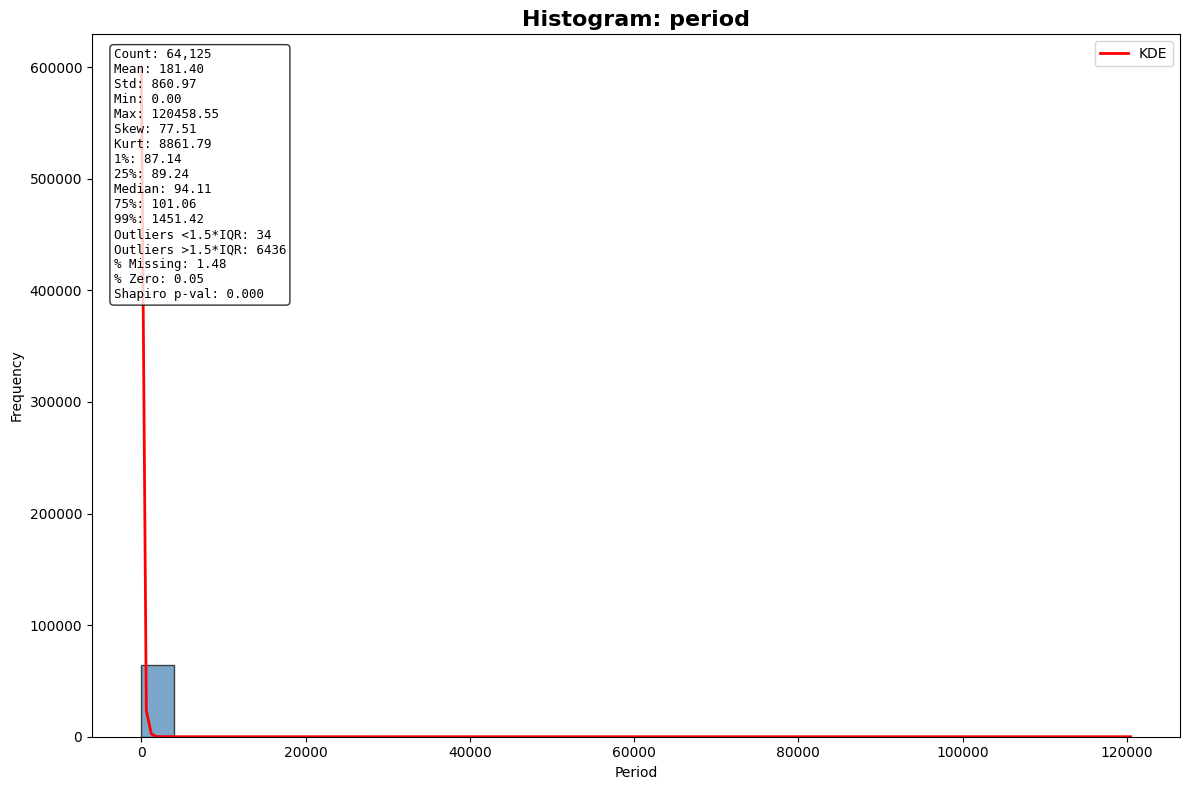

  Mean=181.40, Std=860.97, Min=0.00, Max=120458.55
  Skew=77.51, Kurtosis=8861.79
  Percentiles: 1%=87.14, 25%=89.24, Median=94.11, 75%=101.06, 99%=1451.42
  Outliers (low=34, high=6436) based on 1.5*IQR
  % Missing=1.48, % Zeros=0.05
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: derive altitude bands (LEO/MEO/GEO).

Processing column 14/15: inclination


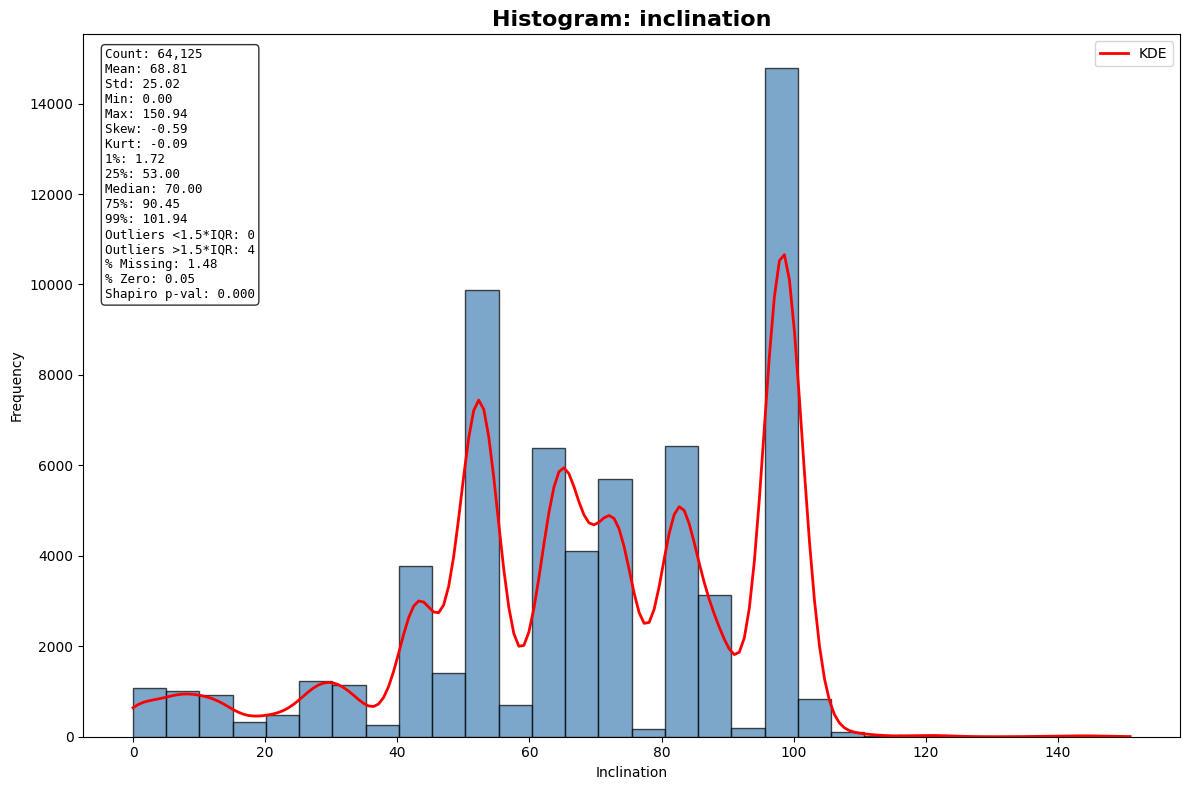

  Mean=68.81, Std=25.02, Min=0.00, Max=150.94
  Skew=-0.59, Kurtosis=-0.09
  Percentiles: 1%=1.72, 25%=53.00, Median=70.00, 75%=90.45, 99%=101.94
  Outliers (low=0, high=4) based on 1.5*IQR
  % Missing=1.48, % Zeros=0.05
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)
  ➡ Domain feature: classify orbit regime (Equatorial, SSO, Molniya, ISS).

Processing column 15/15: periapsis


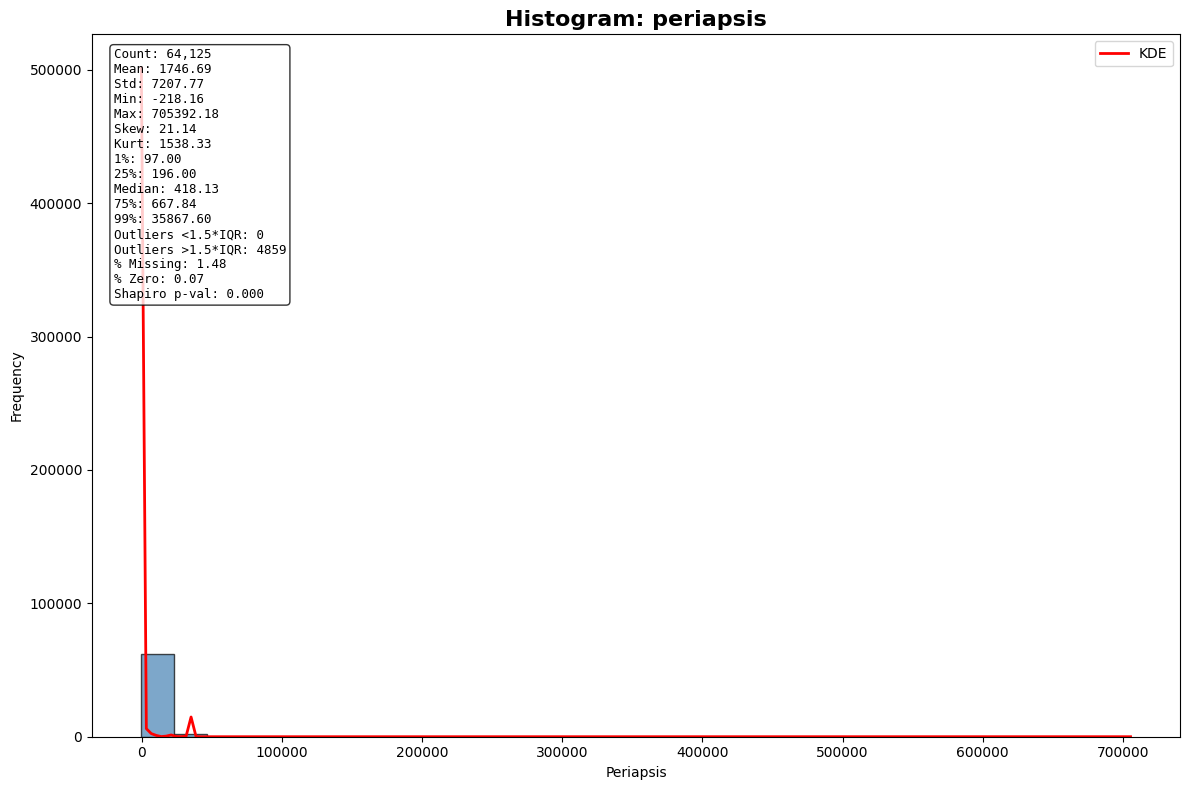

  Mean=1746.69, Std=7207.77, Min=-218.16, Max=705392.18
  Skew=21.14, Kurtosis=1538.33
  Percentiles: 1%=97.00, 25%=196.00, Median=418.13, 75%=667.84, 99%=35867.60
  Outliers (low=0, high=4859) based on 1.5*IQR
  % Missing=1.48, % Zeros=0.07
  Shapiro-Wilk p=0.000 (p>0.05 ~ normal)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, shapiro, gaussian_kde

# --- Editable settings ---
columns_to_plot = [
    'LAUNCH_YEAR','LAUNCH_NUM','MEAN_MOTION','ECCENTRICITY','RA_OF_ASC_NODE',
    'ARG_OF_PERICENTER','MEAN_ANOMALY','REV_AT_EPOCH','BSTAR','MEAN_MOTION_DOT',
    'MEAN_MOTION_DDOT','SEMIMAJOR_AXIS','period','inclination','apapsis','periapsis'
]
bins = 30
figsize = (12, 8)
color = 'steelblue'
edge_color = 'black'
alpha = 0.7
kde = True
log_scale = False
# -------------------------

valid_columns = [col for col in columns_to_plot if col in satnav_tidy.columns]
invalid_columns = [col for col in columns_to_plot if col not in satnav_tidy.columns]

if invalid_columns:
    print(f"Warning: Skipping {invalid_columns}")

for i, column in enumerate(valid_columns):
    print(f"\nProcessing column {i+1}/{len(valid_columns)}: {column}")
    data = satnav_tidy[column].dropna()

    if len(data) == 0:
        print(f"  No data in {column}")
        continue

    # force numeric
    if data.dtype == 'object':
        data = pd.to_numeric(data, errors='coerce').dropna()

    # --- Basic statistics ---
    count = len(data)
    mean_val = data.mean()
    std_val = data.std()
    min_val = data.min()
    max_val = data.max()

    # --- Distribution shape ---
    skewness = skew(data)
    kurt = kurtosis(data)  # Fisher definition, 0 = normal
    percentiles = np.percentile(data, [1, 25, 50, 75, 99])

    # --- Outliers via IQR ---
    Q1, Q3 = percentiles[1], percentiles[3]
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_low = (data < lower_bound).sum()
    outliers_high = (data > upper_bound).sum()

    # --- Missingness / zeros ---
    missing_pct = satnav_tidy[column].isna().mean() * 100
    zero_pct = (data == 0).mean() * 100

    # --- Normality test ---
    shapiro_stat, shapiro_p = shapiro(data.sample(min(5000, count)))  # Shapiro limited to 5k samples
    normality_result = shapiro_p  # one number: p-value (higher = more normal-like)

    # --- Plot ---
    plt.figure(figsize=figsize)
    plt.hist(data, bins=bins, color=color, edgecolor=edge_color, alpha=alpha)
    if kde and len(data) > 1:
        try:
            kde_curve = gaussian_kde(data)
            x_range = np.linspace(min_val, max_val, 200)
            kde_vals = kde_curve(x_range) * count * (max_val - min_val) / bins
            plt.plot(x_range, kde_vals, 'r-', linewidth=2, label='KDE')
            plt.legend()
        except Exception as e:
            print(f"  KDE failed for {column}: {e}")

    plt.title(f'Histogram: {column}', fontsize=16, fontweight='bold')
    plt.xlabel(column.replace('_',' ').title())
    plt.ylabel('Frequency')
    if log_scale and max_val > 0:
        plt.yscale('log')
        plt.ylabel('Frequency (Log Scale)')

    # Extended stats box
    stats_text = (
        f'Count: {count:,}\nMean: {mean_val:.2f}\nStd: {std_val:.2f}\n'
        f'Min: {min_val:.2f}\nMax: {max_val:.2f}\n'
        f'Skew: {skewness:.2f}\nKurt: {kurt:.2f}\n'
        f'1%: {percentiles[0]:.2f}\n25%: {Q1:.2f}\nMedian: {percentiles[2]:.2f}\n'
        f'75%: {Q3:.2f}\n99%: {percentiles[4]:.2f}\n'
        f'Outliers <1.5*IQR: {outliers_low}\nOutliers >1.5*IQR: {outliers_high}\n'
        f'% Missing: {missing_pct:.2f}\n% Zero: {zero_pct:.2f}\n'
        f'Shapiro p-val: {normality_result:.3f}'
    )
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontfamily='monospace')

    plt.tight_layout()
    plt.show()

    # --- Print to console ---
    print(f"  Mean={mean_val:.2f}, Std={std_val:.2f}, Min={min_val:.2f}, Max={max_val:.2f}")
    print(f"  Skew={skewness:.2f}, Kurtosis={kurt:.2f}")
    print(f"  Percentiles: 1%={percentiles[0]:.2f}, 25%={Q1:.2f}, Median={percentiles[2]:.2f}, 75%={Q3:.2f}, 99%={percentiles[4]:.2f}")
    print(f"  Outliers (low={outliers_low}, high={outliers_high}) based on 1.5*IQR")
    print(f"  % Missing={missing_pct:.2f}, % Zeros={zero_pct:.2f}")
    print(f"  Shapiro-Wilk p={normality_result:.3f} (p>0.05 ~ normal)")

    # --- Domain-specific ideas ---
    if "inclination" in column.lower():
        print("  ➡ Domain feature: classify orbit regime (Equatorial, SSO, Molniya, ISS).")
    if "eccentricity" in column.lower():
        print("  ➡ Domain feature: circular vs elliptical orbit buckets.")
    if "period" in column.lower() or "mean_motion" in column.lower():
        print("  ➡ Domain feature: derive altitude bands (LEO/MEO/GEO).")
    if "rev_at_epoch" in column.lower():
        print("  ➡ Domain feature: approximate mission age (revs / mean_motion).")
    if "bstar" in column.lower():
        print("  ➡ Domain feature: drag/lifetime proxy.")
    if "arg_of_pericenter" in column.lower() or "mean_anomaly" in column.lower():
        print("  ➡ Domain feature: sin/cos transform to handle cyclic nature.")


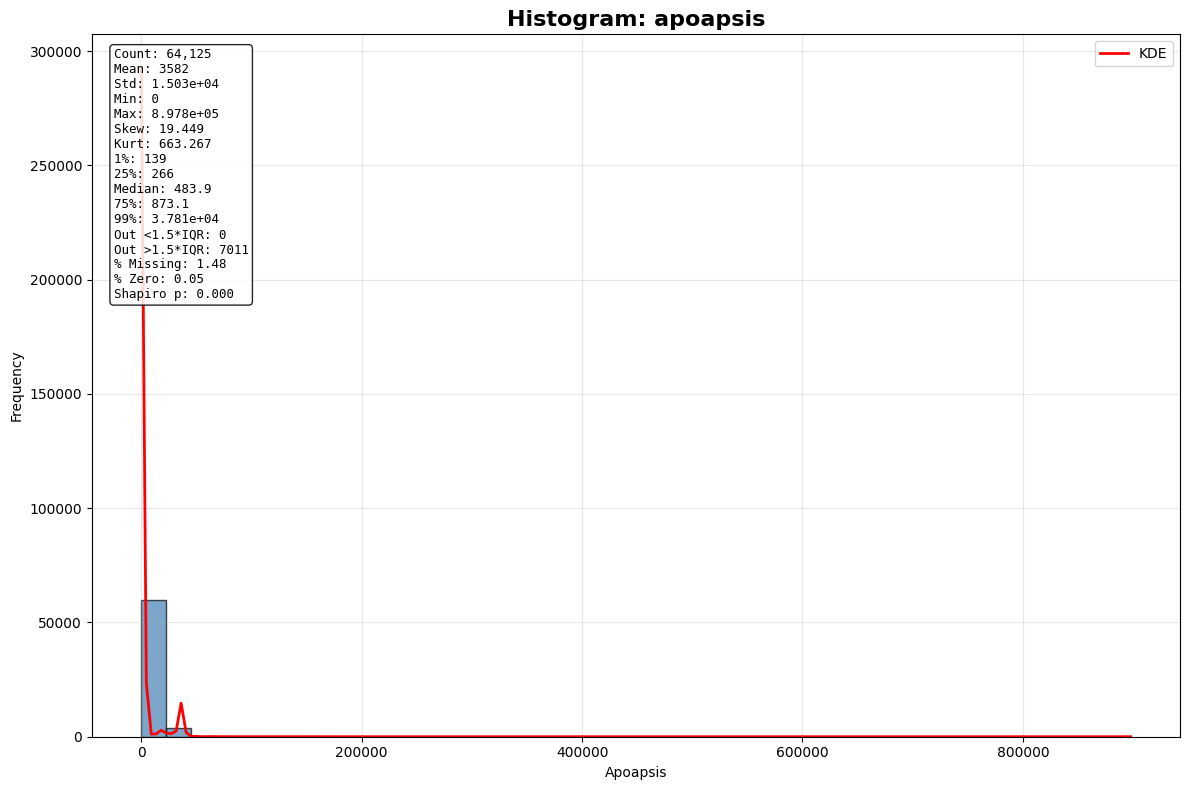

{'column': 'apoapsis',
 'non_missing': 64125,
 'mean': 3581.767076740741,
 'std': 15028.436546740102,
 'min': 0.0,
 'p01': 139.0,
 'p25': 266.0,
 'p50': 483.934,
 'p75': 873.052,
 'p99': 37808.92400000002,
 'max': 897754.424,
 'iqr': 607.052,
 'outliers_low_1p5_IQR': 0,
 'outliers_high_1p5_IQR': 7011,
 'missing_pct': 1.4795353982300885,
 'zero_pct': 0.05458089668615984,
 'skew': 19.44904876642232,
 'kurtosis': 663.2671889480716,
 'shapiro_p': 2.3026199114095123e-91,
 'domain_hints': []}

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, shapiro, gaussian_kde

# ---------- helpers ----------
_DOMAIN_HINTS = [
    ("inclination", "Classify orbit regime: Equatorial / Mid-incl. LEO / ISS (~51.6°) / Molniya (~63.4°) / SSO (~97–99°); add retrograde flag (i>90°)."),
    ("eccentricity", "Bucket circular/near-circular/elliptical; derive periapsis/apoapsis consistency checks."),
    ("mean_motion", "Convert to orbital period; altitude bands LEO/MEO/GEO; period drift with ṅ."),
    ("period", "Map to altitude band; check consistency with semi-major axis via Kepler (T ∝ a^{3/2})."),
    ("semimajor_axis", "Specific orbital energy, altitude band, GEO proximity (|a-a_GEO|)."),
    ("rev_at_epoch", "Approx. mission age ≈ REV_AT_EPOCH / mean_motion (days); note 99,999 cap (censoring)."),
    ("bstar", "Drag / decay proxy; combine with altitude to estimate lifetime risk."),
    ("arg_of_pericenter", "Cyclic: use sin/cos; detect clustering for HEO (argument near 270° typical Molniya)."),
    ("ra_of_asc_node", "Cyclic: use sin/cos; SSO RAAN drift grouping."),
    ("mean_anomaly", "Cyclic: use sin/cos; note catalog phasing biases.")
]

def _domain_suggestions(col_name: str) -> list[str]:
    name = col_name.lower()
    return [hint for key, hint in _DOMAIN_HINTS if key in name]

# ---------- main API ----------
def profile_numeric(df: pd.DataFrame,
                    col: str,
                    bins: int = 30,
                    plot: bool = True,
                    kde: bool = True,
                    log_y: bool = False,
                    sample_for_shapiro: int = 5000) -> dict:
    """
    Compute extended univariate stats for a numeric column and optionally plot a histogram+KDE.
    Returns a dict of metrics (also printed in the figure if plot=True).
    """
    s = df[col]
    missing_pct = s.isna().mean() * 100
    s = pd.to_numeric(s, errors="coerce").dropna()
    n = len(s)
    if n == 0:
        return {"column": col, "non_missing": 0, "message": "no numeric data"}

    # core stats
    mean_val = s.mean()
    std_val = s.std()
    min_val, max_val = s.min(), s.max()
    p1, q1, med, q3, p99 = np.percentile(s, [1, 25, 50, 75, 99])
    iqr = q3 - q1
    lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_low = int((s < lb).sum())
    out_high = int((s > ub).sum())
    zero_pct = float((s == 0).mean() * 100)
    sk = float(skew(s))
    kt = float(kurtosis(s))  # Fisher (0 ~= normal)

    # Shapiro-Wilk (cap to keep it fast and within test limits)
    sample = s.sample(min(sample_for_shapiro, n), random_state=7)
    try:
        sh_stat, sh_p = shapiro(sample)
        shapiro_p = float(sh_p)  # one-number result as requested
    except Exception:
        shapiro_p = np.nan

    # plotting
    if plot:
        fig, ax = plt.subplots(figsize=(12, 8))
        counts, edges, _ = ax.hist(s, bins=bins, color="steelblue", edgecolor="black", alpha=0.7)
        if kde and n > 1:
            try:
                kde_curve = gaussian_kde(s)
                x = np.linspace(min_val, max_val, 200)
                # scale KDE to histogram counts
                bin_width = (max_val - min_val) / bins if max_val > min_val else 1
                y = kde_curve(x) * n * bin_width
                ax.plot(x, y, "r-", lw=2, label="KDE")
                ax.legend()
            except Exception:
                pass
        ax.set_title(f"Histogram: {col}", fontsize=16, fontweight="bold")
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel("Frequency")
        ax.grid(True, alpha=0.3)
        if log_y and counts.max() > 0:
            ax.set_yscale("log")
            ax.set_ylabel("Frequency (Log Scale)")

        # stats box (monospace)
        txt = (
            f"Count: {n:,}\nMean: {mean_val:.4g}\nStd: {std_val:.4g}\n"
            f"Min: {min_val:.4g}\nMax: {max_val:.4g}\n"
            f"Skew: {sk:.3f}\nKurt: {kt:.3f}\n"
            f"1%: {p1:.4g}\n25%: {q1:.4g}\nMedian: {med:.4g}\n"
            f"75%: {q3:.4g}\n99%: {p99:.4g}\n"
            f"Out <1.5*IQR: {out_low}\nOut >1.5*IQR: {out_high}\n"
            f"% Missing: {missing_pct:.2f}\n% Zero: {zero_pct:.2f}\n"
            f"Shapiro p: {shapiro_p:.3f}"
        )
        ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
                fontsize=9, fontfamily="monospace")
        plt.tight_layout()
        plt.show()

    return {
        "column": col,
        "non_missing": n,
        "mean": float(mean_val),
        "std": float(std_val),
        "min": float(min_val),
        "p01": float(p1),
        "p25": float(q1),
        "p50": float(med),
        "p75": float(q3),
        "p99": float(p99),
        "max": float(max_val),
        "iqr": float(iqr),
        "outliers_low_1p5_IQR": out_low,
        "outliers_high_1p5_IQR": out_high,
        "missing_pct": float(missing_pct),
        "zero_pct": float(zero_pct),
        "skew": sk,
        "kurtosis": kt,
        "shapiro_p": shapiro_p,
        "domain_hints": _domain_suggestions(col)
    }

def batch_profile(df: pd.DataFrame,
                  cols: list[str],
                  plot_each: bool = False,
                  **kwargs) -> pd.DataFrame:
    """
    Run profile_numeric on many columns and return a tidy DataFrame of results.
    Set plot_each=True if you want the plots per column.
    kwargs are forwarded to profile_numeric (bins, kde, log_y, sample_for_shapiro).
    """
    results = []
    for c in cols:
        if c not in df.columns:
            continue
        res = profile_numeric(df, c, plot=plot_each, **kwargs)
        results.append(res)
    out = pd.DataFrame(results)
    # put domain_hints as a single string column for easy viewing
    if "domain_hints" in out.columns:
        out["domain_hints"] = out["domain_hints"].apply(lambda x: "; ".join(x) if isinstance(x, list) else "")
    # nice ordering
    cols_order = [
        "column","non_missing","missing_pct","zero_pct",
        "mean","std","min","p01","p25","p50","p75","p99","max",
        "iqr","outliers_low_1p5_IQR","outliers_high_1p5_IQR",
        "skew","kurtosis","shapiro_p","domain_hints"
    ]
    return out.reindex(columns=[c for c in cols_order if c in out.columns])


# One column + plot
''' 
columns_to_plot = [
    'LAUNCH_YEAR','LAUNCH_NUM','MEAN_MOTION','ECCENTRICITY','RA_OF_ASC_NODE',
    'ARG_OF_PERICENTER','MEAN_ANOMALY','REV_AT_EPOCH','BSTAR','MEAN_MOTION_DOT',
    'MEAN_MOTION_DDOT','SEMIMAJOR_AXIS','period','inclination','apoapsis','periapsis'
] '''


profile_numeric(satnav_tidy, "apoapsis", bins=40, plot=True, kde=True)


In [ ]:
for a in ["RA_OF_ASC_NODE","ARG_OF_PERICENTER","MEAN_ANOMALY"]:
    if a in satnav_tidy.columns:
        r = np.deg2rad(pd.to_numeric(satnav_tidy[a], errors="coerce"))
        satnav_tidy[a+"_sin"] = np.sin(r)
        satnav_tidy[a+"_cos"] = np.cos(r)


# Outlier Detection

In [12]:
import numpy as np
import pandas as pd

# ---- constants (km, s) ----
MU_EARTH = 398600.4418          # km^3 / s^2
EARTH_RADIUS_KM = 6378.137      # Earth's equatorial radius

# ---- configuration for physical thresholds (tune if needed) ----
CFG = {
    "mean_motion_min": 0.2,     # rev/day  (very long period < ~7 days -> suspicious for Earth TLEs)
    "mean_motion_max": 18.0,    # rev/day  (theoretical upper ~16-17; 18 is safety margin)
    "bstar_abs_warn": 1e-2,     # |BSTAR| > 1e-2 => extreme
    "ndot_abs_warn": 1e-2,      # |ṅ| rev/day^2 (typical << 1e-3)
    "nddot_abs_warn": 1e-4,     # |n̈| rev/day^3 (typical << 1e-5)
    "apo_max_warn_km": 1e5,     # apoapsis altitude > 100,000 km => suspicious for Earth-orbit TLE
    "per_min_warn_km": 0.0,     # perigee altitude < 0 => intersects Earth
    "consistency_tol_frac_a": 0.10,  # 10% tolerance for a-consistency checks
    "consistency_tol_frac_T": 0.05,  # 5% tolerance for T vs 1440/n
}

def _find_col(df, names):
    """Return first column in df that matches any name (case-insensitive)."""
    low = {c.lower(): c for c in df.columns}
    for name in names:
        if name.lower() in low:
            return low[name.lower()]
    return None

def _iqr_outlier_flags(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    q1, q3 = np.nanpercentile(s, [25, 75])
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (s < lb) | (s > ub)

def build_outlier_matrix(df: pd.DataFrame,
                         numeric_cols: list[str],
                         include_rule_columns: bool = True) -> pd.DataFrame:
    """
    Returns a boolean DataFrame of outliers:
      - stat_out_<col>: IQR outliers
      - phys_out_<col>: physics/consistency outliers
      - (optional) rule-by-rule columns like phys_rule_<name>
      - summary columns: stat_outlier_count, phys_outlier_count, total_outliers, any_outlier
    """
    out = pd.DataFrame(index=df.index)

    # --- STATISTICAL (IQR) ---
    for col in numeric_cols:
        if col in df.columns:
            out[f"stat_out_{col}"] = _iqr_outlier_flags(df[col])
        else:
            out[f"stat_out_{col}"] = False

    # --- PHYSICAL / CONSISTENCY RULES ---
    # Flex column resolution (supports your actual names & typos)
    col_e = _find_col(df, ["ECCENTRICITY","e"])
    col_i = _find_col(df, ["inclination","INCLINATION"])
    col_n = _find_col(df, ["MEAN_MOTION","mean_motion"])
    col_T = _find_col(df, ["period","PERIOD"])
    col_a = _find_col(df, ["SEMIMAJOR_AXIS","a","SEMIMAJORAXIS"])
    col_raan = _find_col(df, ["RA_OF_ASC_NODE","RAAN"])
    col_argp = _find_col(df, ["ARG_OF_PERICENTER","ARG_PERICENTER","ARG_OF_PERIAPSIS"])
    col_M = _find_col(df, ["MEAN_ANOMALY","M"])
    col_rev = _find_col(df, ["REV_AT_EPOCH","REVAT_EPOCH"])
    col_bstar = _find_col(df, ["BSTAR","B_STAR"])
    col_ndot = _find_col(df, ["MEAN_MOTION_DOT","N_DOT","N_DOT_1"])
    col_nddot = _find_col(df, ["MEAN_MOTION_DDOT","N_DDOT","N_DOT_2"])
    col_apo = _find_col(df, ["apoapsis","APOAPSIS","apapsis"])
    col_per = _find_col(df, ["periapsis","PERIAPSIS"])

    # Initialize physical flags per column (combined)
    phys_flags = {col: pd.Series(False, index=df.index) for col in numeric_cols if col in df.columns}

    # Rule-by-rule storage (optional)
    rule_cols = {}

    # --- Bounds / range checks ---
    if col_e:
        rule_cols["phys_rule_e_bounds"] = (df[col_e] < 0) | (df[col_e] >= 1.0)
        phys_flags[col_e] = phys_flags.get(col_e, False) | rule_cols["phys_rule_e_bounds"]

    if col_i:
        rule_cols["phys_rule_i_bounds"] = (df[col_i] < 0) | (df[col_i] > 180)
        phys_flags[col_i] = phys_flags.get(col_i, False) | rule_cols["phys_rule_i_bounds"]

    for ang_col, rule_name in [(col_raan, "phys_rule_raan_bounds"),
                               (col_argp, "phys_rule_argp_bounds"),
                               (col_M, "phys_rule_M_bounds")]:
        if ang_col:
            rule_cols[rule_name] = (df[ang_col] < 0) | (df[ang_col] >= 360)
            phys_flags[ang_col] = phys_flags.get(ang_col, False) | rule_cols[rule_name]

    if col_n:
        nn = pd.to_numeric(df[col_n], errors="coerce")
        rule_cols["phys_rule_n_bounds"] = (nn <= 0) | (nn < CFG["mean_motion_min"]) | (nn > CFG["mean_motion_max"])
        phys_flags[col_n] = phys_flags.get(col_n, False) | rule_cols["phys_rule_n_bounds"]

    if col_rev:
        rr = pd.to_numeric(df[col_rev], errors="coerce")
        rule_cols["phys_rule_rev_bounds"] = (rr < 0) | (rr > 99999)
        phys_flags[col_rev] = phys_flags.get(col_rev, False) | rule_cols["phys_rule_rev_bounds"]

    if col_bstar:
        bb = pd.to_numeric(df[col_bstar], errors="coerce").abs()
        rule_cols["phys_rule_bstar_extreme"] = bb > CFG["bstar_abs_warn"]
        phys_flags[col_bstar] = phys_flags.get(col_bstar, False) | rule_cols["phys_rule_bstar_extreme"]

    if col_ndot:
        nd = pd.to_numeric(df[col_ndot], errors="coerce").abs()
        rule_cols["phys_rule_ndot_extreme"] = nd > CFG["ndot_abs_warn"]
        phys_flags[col_ndot] = phys_flags.get(col_ndot, False) | rule_cols["phys_rule_ndot_extreme"]

    if col_nddot:
        ndd = pd.to_numeric(df[col_nddot], errors="coerce").abs()
        rule_cols["phys_rule_nddot_extreme"] = ndd > CFG["nddot_abs_warn"]
        phys_flags[col_nddot] = phys_flags.get(col_nddot, False) | rule_cols["phys_rule_nddot_extreme"]

    if col_per:
        pp = pd.to_numeric(df[col_per], errors="coerce")
        rule_cols["phys_rule_per_negative"] = pp < CFG["per_min_warn_km"]
        phys_flags[col_per] = phys_flags.get(col_per, False) | rule_cols["phys_rule_per_negative"]

    if col_apo:
        aa = pd.to_numeric(df[col_apo], errors="coerce")
        rule_cols["phys_rule_apo_extreme"] = aa > CFG["apo_max_warn_km"]
        phys_flags[col_apo] = phys_flags.get(col_apo, False) | rule_cols["phys_rule_apo_extreme"]

    # --- Consistency: period vs mean motion ---
    if col_T and col_n:
        T = pd.to_numeric(df[col_T], errors="coerce")              # minutes
        n = pd.to_numeric(df[col_n], errors="coerce")              # rev/day
        T_pred = 1440.0 / n                                        # minutes
        rel_err_T = np.abs(T - T_pred) / T_pred
        rule_cols["phys_rule_T_vs_n"] = rel_err_T > CFG["consistency_tol_frac_T"]
        # attach to BOTH columns
        for c in [col_T, col_n]:
            phys_flags[c] = phys_flags.get(c, False) | rule_cols["phys_rule_T_vs_n"]

    # --- Consistency: a from (apo, peri) vs a column ---
    if col_a and col_apo and col_per:
        apo = pd.to_numeric(df[col_apo], errors="coerce")
        per = pd.to_numeric(df[col_per], errors="coerce")
        ra = EARTH_RADIUS_KM + apo
        rp = EARTH_RADIUS_KM + per
        a_from_apsis = (ra + rp) / 2.0
        a_col = pd.to_numeric(df[col_a], errors="coerce")
        rel_err_a = np.abs(a_col - a_from_apsis) / a_from_apsis
        rule_cols["phys_rule_a_vs_apsis"] = rel_err_a > CFG["consistency_tol_frac_a"]
        for c in [col_a, col_apo, col_per]:
            phys_flags[c] = phys_flags.get(c, False) | rule_cols["phys_rule_a_vs_apsis"]

    # --- Consistency: a from mean motion ---
    if col_a and col_n:
        n = pd.to_numeric(df[col_n], errors="coerce")                     # rev/day
        n_rad_s = n * 2*np.pi / 86400.0
        a_from_n = (MU_EARTH / (n_rad_s**2))**(1/3)                      # km
        a_col = pd.to_numeric(df[col_a], errors="coerce")
        rel_err_an = np.abs(a_col - a_from_n) / a_from_n
        rule_cols["phys_rule_a_vs_n"] = rel_err_an > CFG["consistency_tol_frac_a"]
        for c in [col_a, col_n]:
            phys_flags[c] = phys_flags.get(c, False) | rule_cols["phys_rule_a_vs_n"]

    # roll up the combined physical flags per numeric column
    for col in numeric_cols:
        if col in df.columns:
            # if we never touched that column, default False
            combined = phys_flags.get(col, pd.Series(False, index=df.index))
            out[f"phys_out_{col}"] = combined
        else:
            out[f"phys_out_{col}"] = False

    # optional: append rule-by-rule columns for auditing
    if include_rule_columns:
        for name, series in rule_cols.items():
            out[name] = series.fillna(False)

    # --- summaries ---
    stat_cols = [c for c in out.columns if c.startswith("stat_out_")]
    phys_cols = [c for c in out.columns if c.startswith("phys_out_")]
    out["stat_outlier_count"] = out[stat_cols].sum(axis=1)
    out["phys_outlier_count"] = out[phys_cols].sum(axis=1)
    out["total_outliers"] = out["stat_outlier_count"] + out["phys_outlier_count"]
    out["any_outlier"] = out["total_outliers"] > 0

    return out


Use 

In [13]:
numeric_cols = [
    "MEAN_MOTION","ECCENTRICITY","inclination","SEMIMAJOR_AXIS","period",
    "apoapsis","periapsis","REV_AT_EPOCH","BSTAR","MEAN_MOTION_DOT","MEAN_MOTION_DDOT"
]

flags = build_outlier_matrix(satnav_tidy, numeric_cols, include_rule_columns=True)
flags.head()

# join back
satnav_with_flags = satnav_tidy.join(flags)

# examples
satnav_with_flags["any_outlier"].mean() * 100          # % records with any outlier
suspects = satnav_with_flags.sort_values("total_outliers", ascending=False).head(25)


In [14]:
show_freeze_header(satnav_with_flags.head(500))

INTLDES,NORAD_CAT_ID,SATNAME,COUNTRY,LAUNCH,DECAY,COMMENT,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,OBJECT_NUMBER,EPOCH,MEAN_MOTION,ECCENTRICITY,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,COUNTRY_CODE,TLE_LINE1,TLE_LINE2,object_type,site,period,inclination,apoapsis,periapsis,rcs_size,object_name,object_id,country_map,iso3,stat_out_MEAN_MOTION,stat_out_ECCENTRICITY,stat_out_inclination,stat_out_SEMIMAJOR_AXIS,stat_out_period,stat_out_apoapsis,stat_out_periapsis,stat_out_REV_AT_EPOCH,stat_out_BSTAR,stat_out_MEAN_MOTION_DOT,stat_out_MEAN_MOTION_DDOT,phys_out_MEAN_MOTION,phys_out_ECCENTRICITY,phys_out_inclination,phys_out_SEMIMAJOR_AXIS,phys_out_period,phys_out_apoapsis,phys_out_periapsis,phys_out_REV_AT_EPOCH,phys_out_BSTAR,phys_out_MEAN_MOTION_DOT,phys_out_MEAN_MOTION_DDOT,phys_rule_e_bounds,phys_rule_i_bounds,phys_rule_raan_bounds,phys_rule_argp_bounds,phys_rule_M_bounds,phys_rule_n_bounds,phys_rule_rev_bounds,phys_rule_bstar_extreme,phys_rule_ndot_extreme,phys_rule_nddot_extreme,phys_rule_per_negative,phys_rule_apo_extreme,phys_rule_T_vs_n,phys_rule_a_vs_apsis,phys_rule_a_vs_n,stat_outlier_count,phys_outlier_count,total_outliers,any_outlier
1957-001A,1,SL-1 R/B,CIS,1957-10-04,1957-12-01,NaN,1957,1,A,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ROCKET BODY,TTMTR,96.190,65.1000,938.000,214.000,LARGE,SL-1 R/B,1957-001A,COMMONWEALTH OF INDEPENDENT STATES,MULTI,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,0,0,False
1957-001B,2,SPUTNIK 1,CIS,1957-10-04,1958-01-03,NaN,1957,1,B,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,TTMTR,96.100,65.0000,1080.000,64.000,NaN,SPUTNIK 1,1957-001B,COMMONWEALTH OF INDEPENDENT STATES,MULTI,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,0,0,False
1957-002A,3,SPUTNIK 2,CIS,1957-11-03,1958-04-14,NaN,1957,2,A,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,TTMTR,103.740,65.3300,1659.000,211.000,SMALL,SPUTNIK 2,1957-002A,COMMONWEALTH OF INDEPENDENT STATES,MULTI,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,0,0,False
1958-001A,4,EXPLORER 1,US,1958-02-01,1970-03-31,NaN,1958,1,A,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,AFETR,88.480,33.1500,215.000,183.000,NaN,EXPLORER 1,1958-001A,UNITED STATES OF AMERICA,USA,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,0,0,False
1958-002B,5,VANGUARD 1,US,1958-03-17,NaN,NaN,1958,2,B,5,2025-08-14T12:44:22.624224,10.859249,0.184160,180.7845,195.8980,157.5258,40994.0,-0.000013,3.000000e-08,0.000000,8613.943,US,1 00005U 58002B 25226.53081741 .00000003 00000-0 -12931-4 0 9990,2 00005 34.2468 180.7845 1841601 195.8980 157.5258 10.85924852409941,PAYLOAD,AFETR,132.606,34.2468,3822.153,649.463,SMALL,VANGUARD 1,1958-002B,UNITED STATES OF AMERICA,USA,False,True,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4,0,4,True
1958-003A,6,EXPLORER 3,US,1958-03-26,1958-06-28,NaN,1958,3,A,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAYLOAD,AFETR,151.740,19.2400,5985.000,107.000,SMALL,EXPLORER 3,1958-003A,UNITED STATES OF AMERICA,USA,False,False,False,False,True,True,False,False,False,False,F

In [ ]:
only_outliers= satnav_with_flags[satnav_with_flags["any_outlier"]]
only_outliers.head(50)



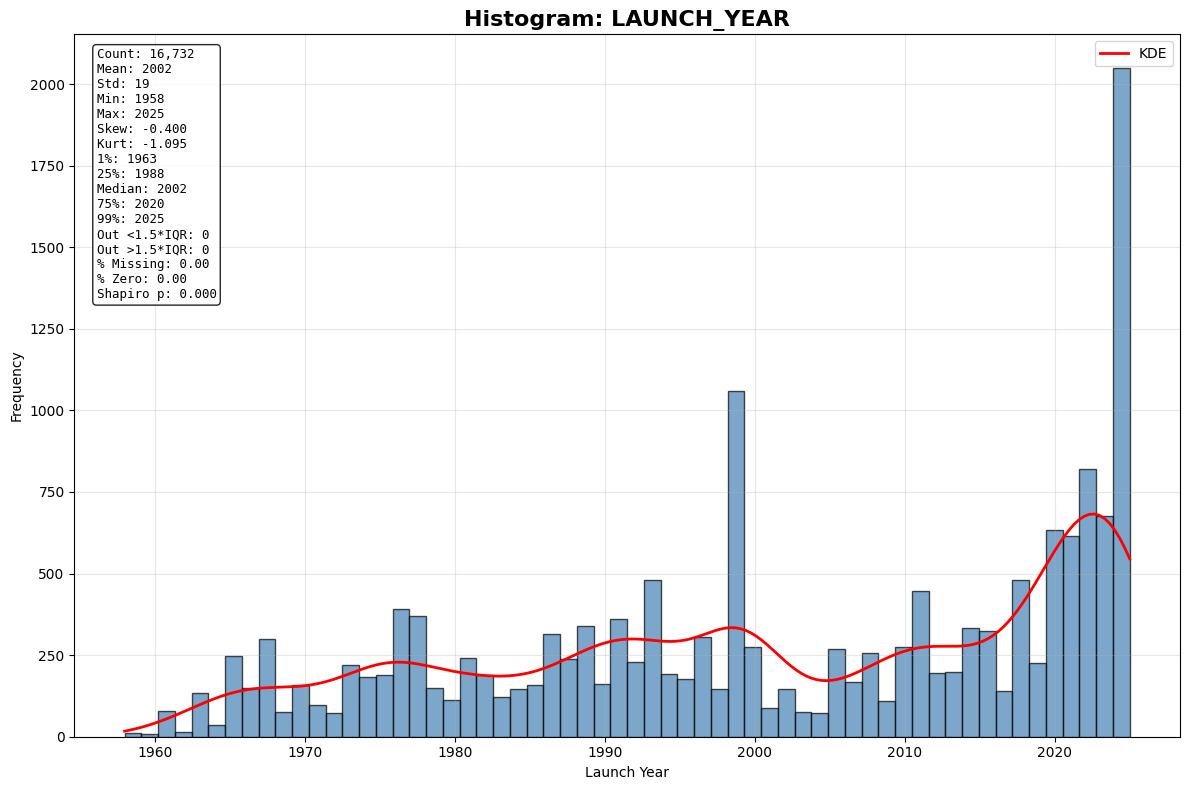

{'column': 'LAUNCH_YEAR',
 'non_missing': 16732,
 'mean': 2001.7569328233326,
 'std': 18.995301939528694,
 'min': 1958.0,
 'p01': 1963.0,
 'p25': 1988.0,
 'p50': 2002.0,
 'p75': 2020.0,
 'p99': 2025.0,
 'max': 2025.0,
 'iqr': 32.0,
 'outliers_low_1p5_IQR': 0,
 'outliers_high_1p5_IQR': 0,
 'missing_pct': 0.0,
 'zero_pct': 0.0,
 'skew': -0.4004634225739498,
 'kurtosis': -1.0953413989037142,
 'shapiro_p': 2.661125113538588e-46,
 'domain_hints': []}

In [30]:
profile_numeric(only_outliers, "LAUNCH_YEAR", bins=60, plot=True, kde=True)


In [29]:
show_freeze_header(only_outliers.sort_values("total_outliers", ascending=False).head(50))

INTLDES,NORAD_CAT_ID,SATNAME,COUNTRY,LAUNCH,DECAY,COMMENT,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,OBJECT_NUMBER,EPOCH,MEAN_MOTION,ECCENTRICITY,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,COUNTRY_CODE,TLE_LINE1,TLE_LINE2,object_type,site,period,inclination,apoapsis,periapsis,rcs_size,object_name,object_id,country_map,iso3,stat_out_MEAN_MOTION,stat_out_ECCENTRICITY,stat_out_inclination,stat_out_SEMIMAJOR_AXIS,stat_out_period,stat_out_apoapsis,stat_out_periapsis,stat_out_REV_AT_EPOCH,stat_out_BSTAR,stat_out_MEAN_MOTION_DOT,stat_out_MEAN_MOTION_DDOT,phys_out_MEAN_MOTION,phys_out_ECCENTRICITY,phys_out_inclination,phys_out_SEMIMAJOR_AXIS,phys_out_period,phys_out_apoapsis,phys_out_periapsis,phys_out_REV_AT_EPOCH,phys_out_BSTAR,phys_out_MEAN_MOTION_DOT,phys_out_MEAN_MOTION_DDOT,phys_rule_e_bounds,phys_rule_i_bounds,phys_rule_raan_bounds,phys_rule_argp_bounds,phys_rule_M_bounds,phys_rule_n_bounds,phys_rule_rev_bounds,phys_rule_bstar_extreme,phys_rule_ndot_extreme,phys_rule_nddot_extreme,phys_rule_per_negative,phys_rule_apo_extreme,phys_rule_T_vs_n,phys_rule_a_vs_apsis,phys_rule_a_vs_n,stat_outlier_count,phys_outlier_count,total_outliers,any_outlier
2000-041B,26411,CLUSTER II-FM6,ESA,2000-07-16,2024-09-08,NaN,2000,41,B,26411,2024-09-08T20:23:34.066176,0.444198,0.913779,39.2512,255.7698,0.1508,2848.0,0.000000,5.545400e-04,-3.245300e-04,72557.805,ESA,1 26411U 00041B 24252.84969984 .00055454 -32453-3 00000+0 0 9994,2 26411 150.0714 39.2512 9137785 255.7698 0.1508 0.44419796 28488,PAYLOAD,TTMTR,3241.798,150.0714,132481.432,-122.092,LARGE,CLUSTER II-FM6,2000-041B,EUROPEAN SPACE AGENCY,ORG,True,True,True,True,True,True,False,False,False,True,True,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,True,False,False,False,8,3,11,True
2024-083C,59629,ICECUBE-Q,PAKI,2024-05-03,NaN,HELIOCENTRIC ORBIT (SUN),2024,83,C,59629,2024-05-03T16:19:12.000000,0.063506,0.976299,348.5400,239.7870,5.9940,0.0,0.000000,-1.949990e-03,1.582300e-03,265372.845,NaN,1 59629U 24082C 24124.68000000 -.00194999 15823-2 00000+0 0 9996,2 59629 23.0390 348.5400 9762994 239.7870 5.9940 0.06350648 05,PAYLOAD,WSC,22674.851,23.0390,518078.059,-88.639,NaN,ICECUBE-Q,2024-082C,PAKISTAN,PAK,True,True,False,True,True,True,False,False,False,True,True,True,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True,True,False,False,False,7,4,11,True
1989-039EG,36884,SL-12 DEB,CIS,1989-05-31,NaN,NaN,1989,39,EG,36884,2024-10-02T03:22:23.200320,9.066389,0.327418,251.5326,59.2586,329.0305,655.0,0.017679,1.024463e-01,8.010800e-07,9715.063,CIS,1 36884U 89039EG 24276.14054630 .10244631 80108-6 17679-1 0 9997,2 36884 61.7336 251.5326 3274182 59.2586 329.0305 9.06638897 6557,DEBRIS,TTMTR,158.828,61.7336,6517.816,156.039,SMALL,SL-12 DEB,1989-039EG,COMMONWEALTH OF INDEPENDENT STATES,MULTI,True,True,False,True,True,True,False,False,True,True,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,8,2,10,True
1989-039S,29311,SL-12 DEB,CIS,1989-05-31,NaN,NaN,1989,39,S,29311,2024-02-05T21:32:35.746080,6.706089,0.446977,243.3425,71.9913,1.4190,37132.0,0.019614,1.808401e-02,1.911200e-07,11878.337,CIS,1 29311U 89039S 24036.89763595 .01808401 19112-6 19614-1 0 9996,2 29311 61.5992 243.3425 4469773 71.9913 1.4190 6.70608891371329,DEBRIS,TTMTR,214.730,61.5992,10809.549,190.855,SMALL,SL-12 DEB,1989-039S,COMMONWEALTH OF INDEPENDENT STATES,MULTI,True,True,False,True,True,True,False,False,True,True,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,8,2,10,True
2015-010C,40426,FALCON 9 R/B,US,2015-03-02,2023-12-19,NaN,2015,10,C,40426,2023-12-18T03:11:52.996992,10.039821,0.282870,188.9187,73.6689,62.6957,3793.0,0.